# Aprendizaje Automático Estadístico — Deber Final Integrado
## Supervivencia del Titanic: Semanas 1, 2 y 3
### UIDE — Maestría en Inteligencia Artificial — Grupo 1

**Grupo 1:**
- César Nelson Abarca Araujo
- Nataly Fernanda Lanchimba Caiza
- Jhon Enrique Oña Guamani

**Dataset:** `titanic_train.csv` / `titanic_test.csv`  
**Repositorio GitHub:** [UIDE MIAA-B · Aprendizaje Automático Estadístico · Deber Grupal Final ](https://github.com/cnabarca/Maestria-IA-UIDE/tree/main/5.%20Aprendizaje%20Automatico%20Estadistico/Informe%20final%20Grupal)


---

> **Alcance del notebook:**
> - **Semana 1:** Regresión Logística · K-NN · Naive Bayes (GridSearchCV, baseline vs. mejorado)
> - **Semana 2:** Árbol de Decisión · Bosque Aleatorio · SVM · RNA — TensorFlow/Keras
> - **Semana 3:** PCA + 7 clasificadores con/sin PCA · K-Means · GMM (K=2 y K=3)
> - **Final:** Ranking global y conclusiones integradas del módulo

### 1.2 Información del Dataset

| Atributo | Detalle |
|---|---|
| Fuente | Kaggle — Titanic: Machine Learning from Disaster |
| Instancias (train) | 891 pasajeros |
| Instancias (test) | 418 pasajeros |
| Variables | 12 (ID + target + 10 features) |
| Clases | No sobrevivió: 549 (61.6%) · Sobrevivió: 342 (38.4%) |
| Tipo de tarea | Clasificación binaria supervisada |

### 1.3 Diccionario de Variables

| Variable | Descripción | Tipo | Notas |
|---|---|---|---|
| `PassengerId` | Identificador único del pasajero | Numérica | Se eliminará |
| `Survived` | Variable objetivo: 1=sobrevivió, 0=no sobrevivió | Binaria | **Target** |
| `Pclass` | Clase del boleto (1=primera, 2=segunda, 3=tercera) | Ordinal | Proxy de nivel socioeconómico |
| `Name` | Nombre completo del pasajero | Texto | Se eliminará |
| `Sex` | Género (male/female) | Categórica | Se codificará (0/1) |
| `Age` | Edad en años | Numérica | 177 nulos — se imputará |
| `SibSp` | Nº de hermanos/cónyuge a bordo | Numérica | — |
| `Parch` | Nº de padres/hijos a bordo | Numérica | — |
| `Ticket` | Número de billete | Texto | Se eliminará |
| `Fare` | Precio del billete en libras | Numérica continua | — |
| `Cabin` | Número de cabina | Texto | 77% nulos — se eliminará |
| `Embarked` | Puerto de embarque (S/C/Q) | Categórica | Se codificará (0/1/2) |

### 1.4 Variable Objetivo

| Clase | Descripción | Codificación |
|---|---|---|
| `0` | No sobrevivió | 0 |
| `1` | Sobrevivió | 1 |

---
# Sección 0 — Configuración Común
## 0.1 Librerías

Este bloque importa **todas** las librerías necesarias para las tres semanas.

In [ ]:
# ── Librerías ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y partición
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score)

# Modelos supervisados — Semanas 1 y 2
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay)

# PCA y Clustering — Semana 3
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                              davies_bouldin_score)

# TensorFlow / Keras — Semana 2 y 3
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print("Librerías cargadas. TF:", tf.__version__)

## 0.2 Carga de Datos

In [85]:
BASE_PATH = r'C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\PROFESOR_AUE'

df_train = pd.read_csv(f'{BASE_PATH}\\titanic_train.csv')
df_test  = pd.read_csv(f'{BASE_PATH}\\titanic_test.csv')

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')
print('\nPrimeras filas — Train:')
display(df_train.head())

Train: (891, 12)  |  Test: (418, 11)

Primeras filas — Train:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1.1 Preprocesamiento de Datos

Se aplican los siguientes pasos en orden para convertir el dataset crudo en un conjunto numérico limpio:

| Paso | Variable | Acción | Motivo |
|---|---|---|---|
| 1 | `Sex` | Codificación (female=0, male=1) | Algoritmos requieren entradas numéricas |
| 2 | `Embarked` | Codificación (Q=0, S=1, C=2) | Ídem |
| 3 | `Age` | Imputación con media (~30) | 19.9% valores nulos |
| 4 | `Age` | Discretización en 7 rangos etarios | Capturar patrones por grupo, no por valor exacto |
| 5 | `Cabin` | Eliminación | 77% nulos — inviable para imputación |
| 6 | `PassengerId`, `Name`, `Ticket` | Eliminación | Sin poder predictivo directo |
| 7 | Filas | Eliminación de nulos restantes | Limpiar datos residuales en Embarked |

#### Rangos de Edad

| Categoría | Rango | Grupo |
|---|---|---|
| `1` | 0–8 | Niños |
| `2` | 9–15 | Adolescentes tempranos |
| `3` | 16–18 | Adolescentes |
| `4` | 19–25 | Jóvenes adultos |
| `5` | 26–40 | Adultos |
| `6` | 41–60 | Adultos mayores |
| `7` | 61–100 | Adultos de tercera edad |

In [87]:
# Paso 1-2: Codificación de variables categóricas (sin FutureWarning)
df_train['Sex']      = df_train['Sex'].map({'female': 0, 'male': 1})
df_test['Sex']       = df_test['Sex'].map({'female': 0, 'male': 1})
df_train['Embarked'] = df_train['Embarked'].map({'Q': 0, 'S': 1, 'C': 2})
df_test['Embarked']  = df_test['Embarked'].map({'Q': 0, 'S': 1, 'C': 2})

# Paso 3: Imputación de Age con media (~30)
PROMEDIO = 30
df_train['Age'] = pd.to_numeric(df_train['Age'], errors='coerce').fillna(PROMEDIO)
df_test['Age']  = pd.to_numeric(df_test['Age'],  errors='coerce').fillna(PROMEDIO)

# Paso 4: Discretización de Age en 7 categorías
bins  = [0, 8, 15, 18, 25, 40, 60, 100]
names = ['1', '2', '3', '4', '5', '6', '7']
df_train['Age'] = pd.cut(df_train['Age'], bins=bins, labels=names)
df_test['Age']  = pd.cut(df_test['Age'],  bins=bins, labels=names)

# Pasos 5-6: Eliminación de columnas
drop_train = [c for c in ['Cabin','PassengerId','Name','Ticket'] if c in df_train.columns]
drop_test  = [c for c in ['Cabin','Name','Ticket']               if c in df_test.columns]
df_train = df_train.drop(drop_train, axis=1)
df_test  = df_test.drop(drop_test,  axis=1)

# Paso 7: Eliminar filas con nulos residuales
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

print('=== VERIFICACIÓN POST-PREPROCESAMIENTO ===')
print(f'Dimensiones — Train: {df_train.shape}  |  Test: {df_test.shape}')
print(f'Nulos restantes — Train: {df_train.isnull().sum().sum()}')
print('\nDataset depurado (primeras filas):')
display(df_train.head())
print('\nDistribución de categorías de Age:')
print(df_train['Age'].value_counts().sort_index())

=== VERIFICACIÓN POST-PREPROCESAMIENTO ===
Dimensiones — Train: (889, 8)  |  Test: (417, 8)
Nulos restantes — Train: 0

Dataset depurado (primeras filas):


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,4,1,0,7.2500,1.0
1,1,1,0,5,1,0,71.2833,2.0
2,1,3,0,5,0,0,7.9250,1.0
3,1,1,0,5,1,0,53.1000,1.0
4,0,3,1,5,0,0,8.0500,1.0



Distribución de categorías de Age:
Age
1     54
2     29
3     56
4    162
5    439
6    128
7     21
Name: count, dtype: int64


### 1.2 Entendimiento de los Datos

Se examina la estructura, tipos de datos, valores faltantes y estadísticas básicas antes de cualquier transformación.

In [86]:
print('=== TIPOS DE DATOS (Train) ===')
df_train.info()

print('\n=== VALORES FALTANTES ===')
missing = pd.DataFrame({
    'Train (n)' : df_train.isnull().sum(),
    'Train (%)'  : (df_train.isnull().mean() * 100).round(1),
    'Test (n)'  : df_test.isnull().sum(),
    'Test (%)'   : (df_test.isnull().mean() * 100).round(1)
})
display(missing[missing['Train (n)'] + missing['Test (n)'] > 0])

print('\n=== ESTADÍSTICAS DESCRIPTIVAS (Train) ===')
display(df_train.describe())

=== TIPOS DE DATOS (Train) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== VALORES FALTANTES ===


,Train (n),Train (%),Test (n),Test (%)
Age,177,19.9,86.0,20.6
Cabin,687,77.1,327.0,78.2
Embarked,2,0.2,0.0,0.0
Fare,0,0.0,1.0,0.2



=== ESTADÍSTICAS DESCRIPTIVAS (Train) ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---
# Fase II
## Análisis Exploratorio de Datos (EDA)

El EDA permite comprender la distribución de las variables, detectar patrones y evaluar qué features tienen mayor relación con la variable objetivo (`Survived`). Todo el análisis se realiza sobre el **dataset depurado** de la Fase I.

### 2.1 Estadísticas Descriptivas

In [88]:
print('=== Variables numéricas ===')
display(df_train.describe())

print('\n=== Distribución por Survived ===')
display(df_train.groupby('Survived')[['Pclass','Sex','SibSp','Parch','Fare','Embarked']].mean().round(3))

=== Variables numéricas ===


,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,0.649044,0.524184,0.382452,32.096681,1.102362
std,0.486260,0.834700,0.477538,1.103705,0.806761,49.697504,0.515181
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000,7.895800,1.000000
50%,0.000000,3.000000,1.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,1.000000,1.000000,0.000000,31.000000,1.000000
max,1.000000,3.000000,1.000000,8.000000,6.000000,512.329200,2.000000



=== Distribución por Survived ===


,Pclass,Sex,SibSp,Parch,Fare,Embarked
Survived,,,,,,
0,2.532,0.852,0.554,0.330,22.118,1.051
1,1.956,0.321,0.476,0.468,48.209,1.185


### 2.2 Variable Objetivo — Survived

La distribución de clases muestra un **desbalance moderado** (62% no sobrevivió vs 38% sobrevivió), lo que se debe considerar al evaluar los modelos. Se priorizará el F1-Score y el AUC-ROC para medir el rendimiento de forma equilibrada.

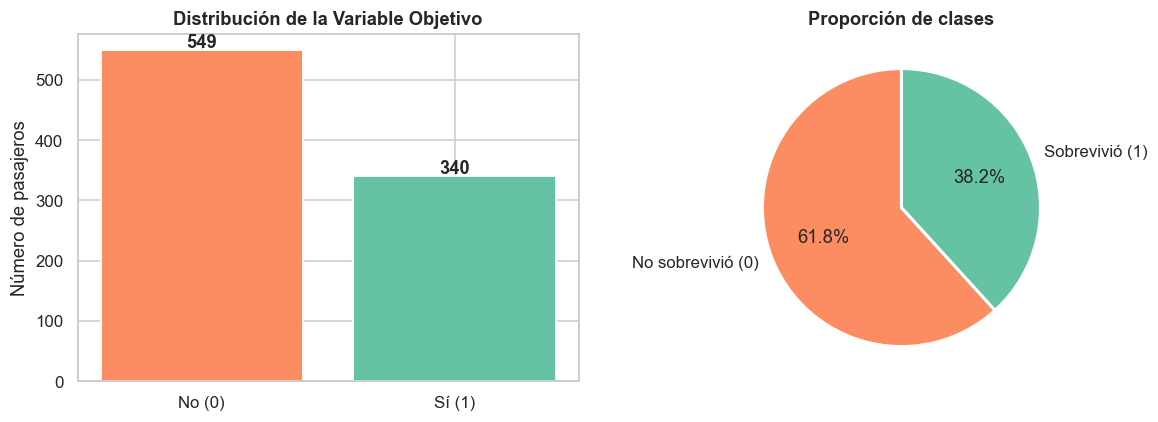

Conteo: {0: 549, 1: 340}


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df_train['Survived'].value_counts()
colors = ['#FC8D62', '#66C2A5']

axes[0].bar(['No (0)', 'Sí (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Número de pasajeros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
            labels=['No sobrevivió (0)', 'Sobrevivió (1)'], colors=colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporción de clases', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print('Conteo:', counts.to_dict())

### 2.3 Distribución de Edad por Categorías y Supervivencia

Dado que `Age` fue discretizada en 7 rangos, se usa un gráfico de barras agrupado. Se espera observar que los niños (categorías 1 y 2) tuvieron mayor tasa de supervivencia por el principio de evacuación.

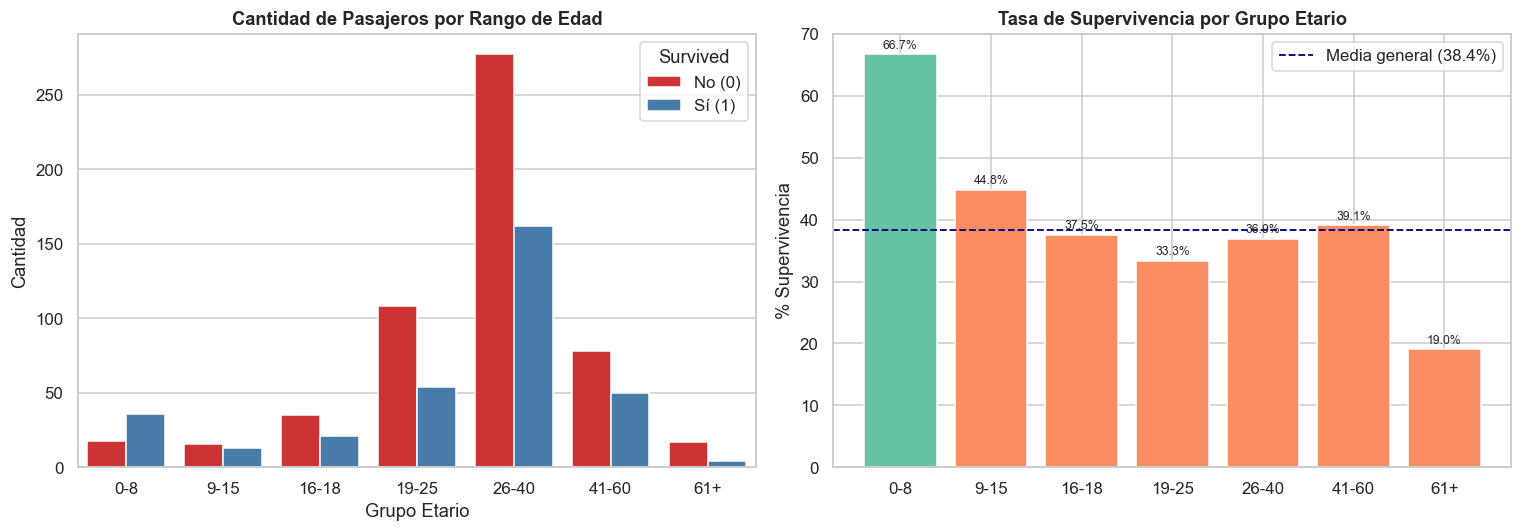

In [90]:
age_map = {'1':'0-8','2':'9-15','3':'16-18','4':'19-25','5':'26-40','6':'41-60','7':'61+'}
df_p = df_train.copy()
df_p['Grupo Etario'] = df_p['Age'].astype(str).map(age_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['0-8','9-15','16-18','19-25','26-40','41-60','61+']
sns.countplot(data=df_p, x='Grupo Etario', hue='Survived', order=order, ax=axes[0], palette='Set1')
axes[0].set_title('Cantidad de Pasajeros por Rango de Edad', fontweight='bold')
axes[0].set_xlabel('Grupo Etario')
axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Survived', labels=['No (0)', 'Sí (1)'])

surv_rate = df_p.groupby('Grupo Etario')['Survived'].mean().reindex(order) * 100
colors_bar = ['#66C2A5' if r >= 50 else '#FC8D62' for r in surv_rate]
axes[1].bar(order, surv_rate.values, color=colors_bar, edgecolor='white')
axes[1].axhline(38.4, color='navy', linestyle='--', linewidth=1.2, label='Media general (38.4%)')
axes[1].set_title('Tasa de Supervivencia por Grupo Etario', fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
axes[1].legend()
for i, v in enumerate(surv_rate.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 2.4 Supervivencia por Clase del Pasajero (Pclass)

La clase refleja el nivel socioeconómico: pasajeros de **1ª clase** tuvieron mayor acceso a los botes salvavidas. Se espera una relación inversa: mayor clase (número), menor supervivencia.

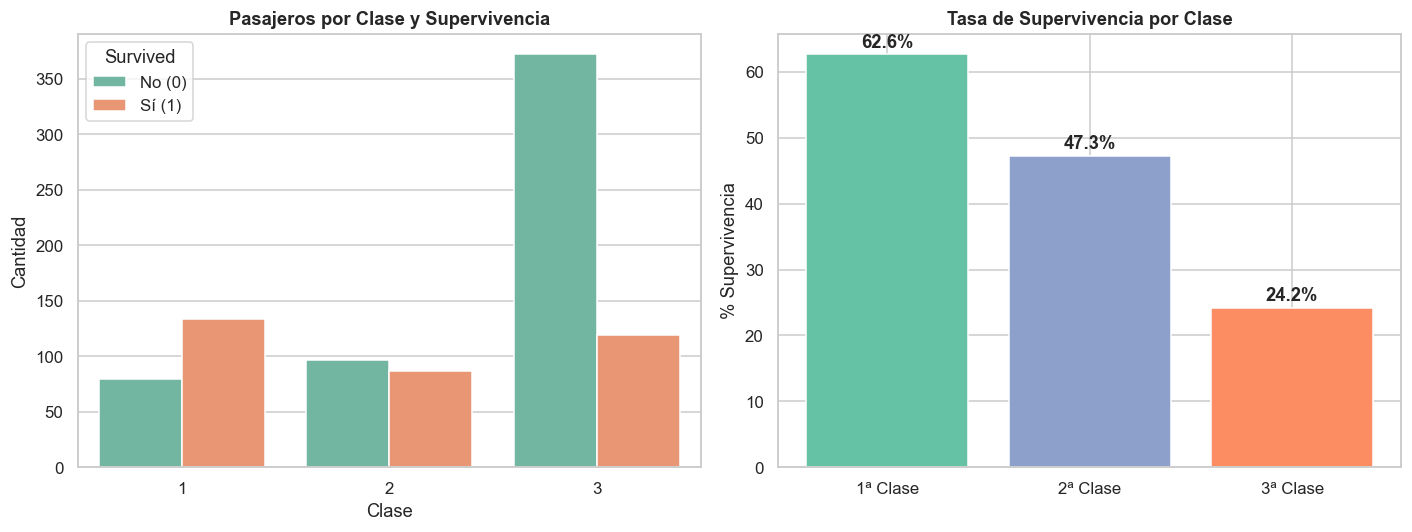

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df_train, x='Pclass', hue='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Pasajeros por Clase y Supervivencia', fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Survived', labels=['No (0)','Sí (1)'])

tasa_clase = df_train.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1ª Clase','2ª Clase','3ª Clase'], tasa_clase.values,
            color=['#66C2A5','#8DA0CB','#FC8D62'], edgecolor='white')
axes[1].set_title('Tasa de Supervivencia por Clase', fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
for i, v in enumerate(tasa_clase.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.5 Distribución de Género y Supervivencia

El principio de evacuación **"mujeres y niños primero"** debería reflejarse en tasas de supervivencia marcadamente superiores para las mujeres (`Sex=0`).

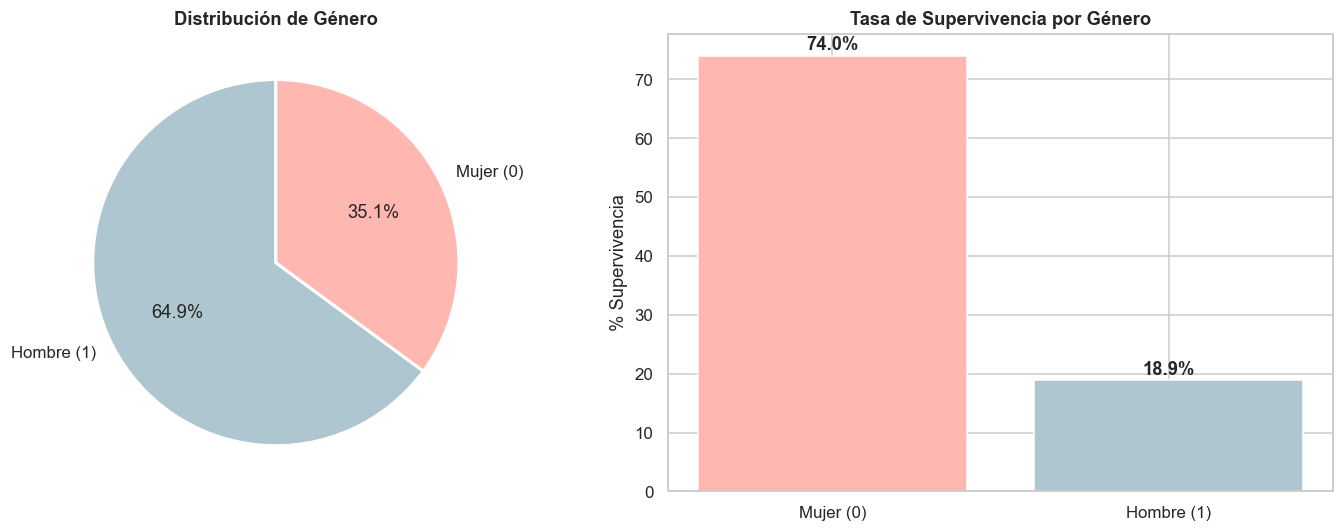

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_train['Sex'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0],
    labels=['Hombre (1)','Mujer (0)'], colors=['#aec6cf','#ffb7b2'],
    startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribución de Género', fontweight='bold')
axes[0].set_ylabel('')

tasa_sex = df_train.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(['Mujer (0)','Hombre (1)'], tasa_sex.values,
            color=['#ffb7b2','#aec6cf'], edgecolor='white')
axes[1].set_title('Tasa de Supervivencia por Género', fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
for i, v in enumerate(tasa_sex.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.6 Análisis de Correlación

La matriz de correlación de **Pearson** mide relaciones lineales entre variables numéricas (rango [−1, 1]).

- `|r| > 0.5` → correlación alta
- `|r| 0.3–0.5` → correlación moderada
- `|r| < 0.3` → correlación baja

> `Age` es de tipo Categorical tras el preprocesamiento, por lo que se excluye del cálculo numérico automáticamente.

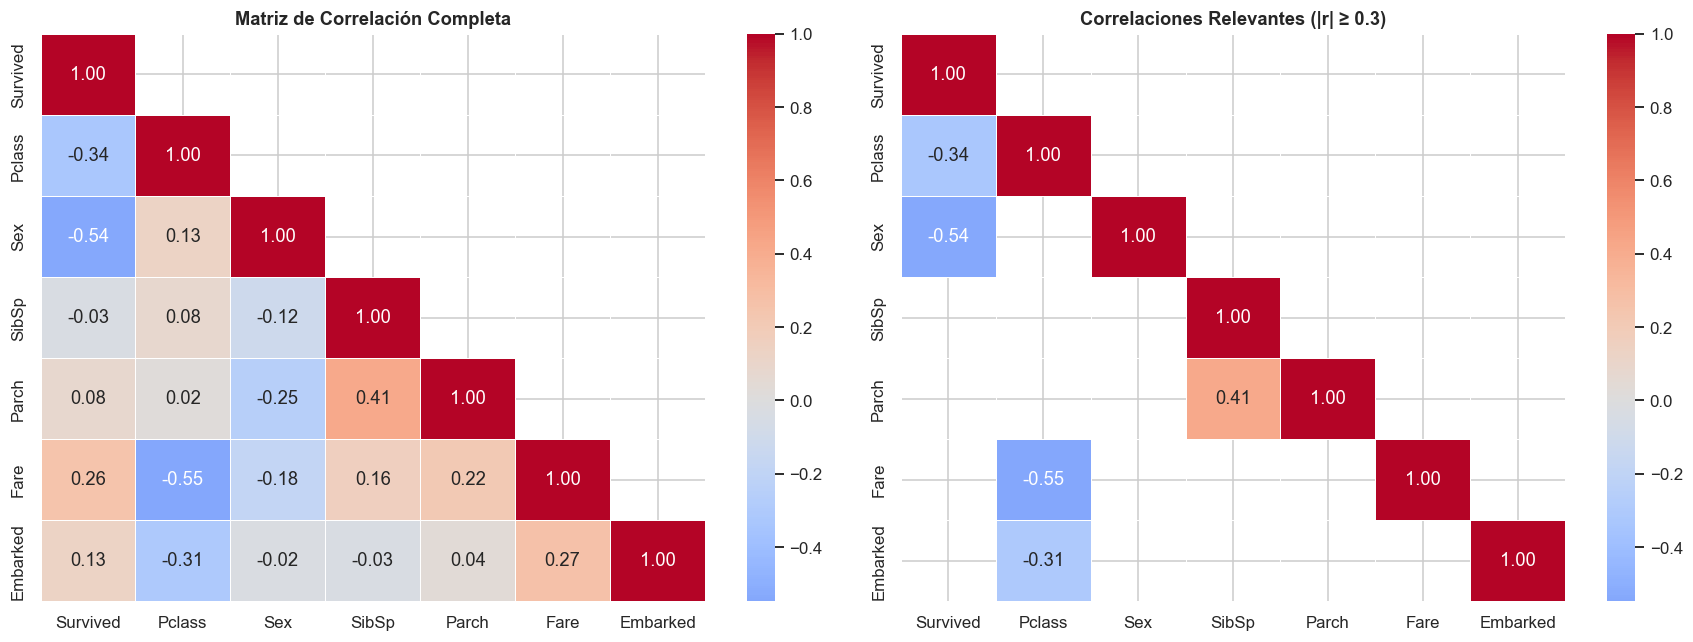


Correlaciones con Survived (ranking):
Sex        -0.5416
Pclass     -0.3355
Fare        0.2553
Embarked    0.1268
Parch       0.0832
SibSp      -0.0340


In [93]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr = df_train[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=.5, ax=axes[0], center=0)
axes[0].set_title('Matriz de Correlación Completa', fontweight='bold')

corr_f = corr.copy()
corr_f[np.abs(corr_f) < 0.3] = np.nan
sns.heatmap(corr_f, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=.5, ax=axes[1], center=0)
axes[1].set_title('Correlaciones Relevantes (|r| ≥ 0.3)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nCorrelaciones con Survived (ranking):')
corr_target = corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
print(corr_target.round(4).to_string())

### 2.7 Diagrama de Cajas — Tarifa (Fare)

El box-plot compara la distribución de `Fare` entre sobrevivientes y no sobrevivientes, y aplica el método **IQR** para detectar y visualizar los valores atípicos.

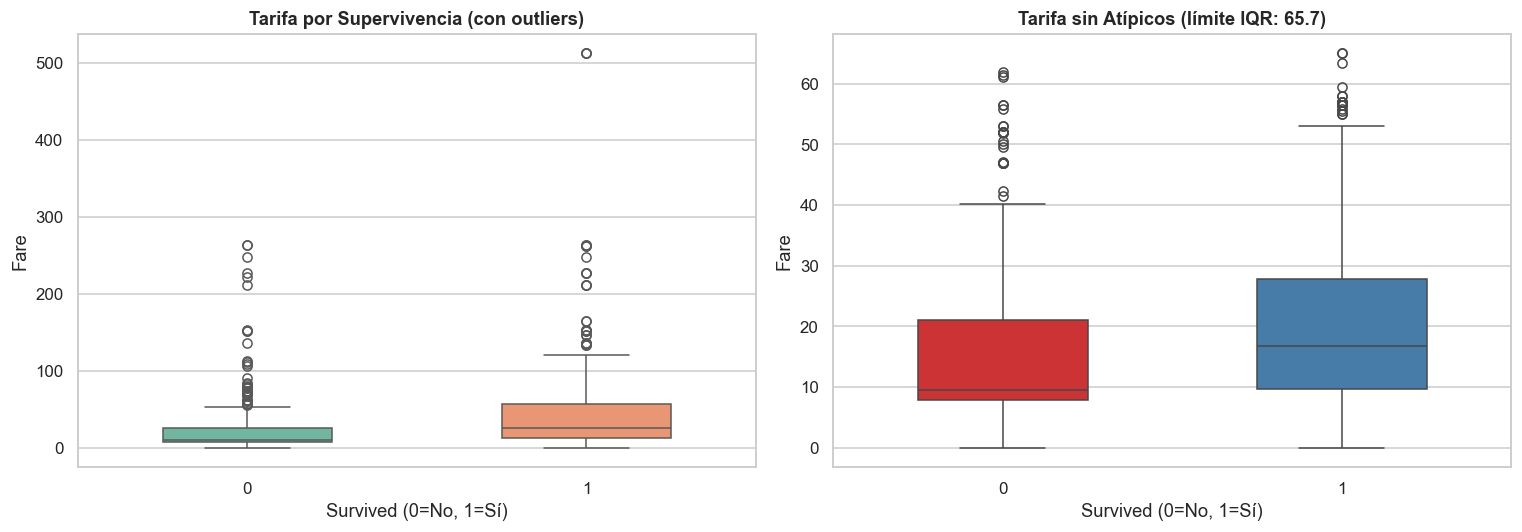

Outliers en Fare: 114 filas eliminadas


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_train, x='Survived', y='Fare', ax=axes[0],
            palette='Set2', width=0.5)
axes[0].set_title('Tarifa por Supervivencia (con outliers)', fontweight='bold')
axes[0].set_xlabel('Survived (0=No, 1=Sí)')

Q1 = df_train['Fare'].quantile(0.25)
Q3 = df_train['Fare'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = Q1 - 1.5 * IQR
df_clean_fare = df_train[(df_train['Fare'] >= lim_inf) & (df_train['Fare'] <= lim_sup)]

sns.boxplot(data=df_clean_fare, x='Survived', y='Fare', ax=axes[1],
            palette='Set1', width=0.5)
axes[1].set_title(f'Tarifa sin Atípicos (límite IQR: {lim_sup:.1f})', fontweight='bold')
axes[1].set_xlabel('Survived (0=No, 1=Sí)')

plt.tight_layout()
plt.show()
print(f'Outliers en Fare: {len(df_train) - len(df_clean_fare)} filas eliminadas')

### 2.8 Interpretación del EDA

| Variable | Observación clave | Relevancia predictiva |
|---|---|---|
| `Sex` | Las mujeres sobrevivieron ~74%, los hombres ~19% | **Muy alta** |
| `Pclass` | 1ª clase: ~63% · 3ª clase: ~24% | **Alta** |
| `Fare` | Sobrevivientes pagaron tarifas significativamente más altas | **Alta** (correlacionado con Pclass) |
| `Age (cat.)` | Niños (0-8) tuvieron mayor supervivencia; adultos 26-40 la menor | **Moderada** |
| `SibSp`/`Parch` | Familias medianas sobrevivieron más que viajeros solos o familias grandes | **Moderada** |
| `Embarked` | Puerto C (Cherbourg) con mayor tasa de supervivencia | **Baja** |

> **Variables candidatas a exclusión:** `Embarked` tiene baja correlación con el target. Se evaluará su impacto en la Fase III.

> **Ingeniería de variables para Fase III:** Crear `family_size = SibSp + Parch + 1` e `is_alone` para capturar mejor el efecto familiar.

---

---
# Sección 1 — Semana 1: Regresión Logística, K-NN y Naive Bayes

**Objetivo:** Implementar tres clasificadores estadísticos clásicos en dos versiones:
- **Baseline:** hiperparámetros por defecto, features originales
- **Mejorada:** GridSearchCV + ingeniería de características (`family_size`, `is_alone`, `Age` binned)

Métrica principal de comparación: AUC-ROC y F1-score (datos desbalanceados).

# Fase III
## Modelado, Evaluación y Comparación

### 3.1 Preparación de Features e Ingeniería de Variables

Se crean dos versiones del dataset de modelado:

| Versión | Features | Descripción |
|---|---|---|
| **Baseline** | 7 features originales | Sin ingeniería de variables |
| **Mejorado** | 9 features | + `family_size` + `is_alone` |

**Ingeniería de variables:**
- `family_size = SibSp + Parch + 1` — tamaño total de la familia a bordo  
- `is_alone = 1 si family_size == 1` — indicador de pasajero sin familia

Estas features capturan el efecto familiar que las variables originales no expresan individualmente.

In [95]:
# Preparar df_model con Age convertida a int para modelado
df_model = df_train.copy()
df_model['Age'] = df_model['Age'].astype(str).astype(int)

# Ingeniería de variables
df_model['family_size'] = df_model['SibSp'] + df_model['Parch'] + 1
df_model['is_alone']    = (df_model['family_size'] == 1).astype(int)

# Definición de features y target
FEATURES_BASE = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
FEATURES_MEJR = FEATURES_BASE + ['family_size', 'is_alone']

X_base = df_model[FEATURES_BASE]
X_mejr = df_model[FEATURES_MEJR]
y      = df_model['Survived']

print('Features baseline:', FEATURES_BASE)
print('Features mejorado:', FEATURES_MEJR)
print(f'\nCorrelación de features nuevas con Survived:')
print(df_model[['family_size','is_alone','Survived']].corr()['Survived'].drop('Survived').round(4))

print(f'\nDimensiones X_base: {X_base.shape}  |  X_mejr: {X_mejr.shape}')
print(f'Distribución del target:\n{y.value_counts()}')

Features baseline: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Features mejorado: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'family_size', 'is_alone']

Correlación de features nuevas con Survived:
family_size    0.0183
is_alone      -0.2062
Name: Survived, dtype: float64

Dimensiones X_base: (889, 7)  |  X_mejr: (889, 9)
Distribución del target:
Survived
0    549
1    340
Name: count, dtype: int64


### 3.2 División Train/Test y Normalización

Se divide el dataset con **80/20 estratificado** (preserva la proporción de clases) y se aplican dos métodos de escalado:

| Método | Fórmula | Usado para |
|---|---|---|
| **StandardScaler** | (x − μ) / σ → media=0, std=1 | Regresión Logística · K-NN |
| **MinMaxScaler** | (x − min) / (max − min) → [0,1] | Naive Bayes (como en referencia del profesor) |

> **Regla fundamental:** el escalador se ajusta (`fit`) **solo con datos de entrenamiento** y se aplica (`transform`) al test, evitando data leakage.

In [96]:
# Split estratificado
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_base, y, test_size=0.2, random_state=SEED, stratify=y)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_mejr, y, test_size=0.2, random_state=SEED, stratify=y)

# StandardScaler (para LR y KNN)
scaler_std = StandardScaler()
Xb_tr_std  = scaler_std.fit_transform(Xb_tr)
Xb_te_std  = scaler_std.transform(Xb_te)

scaler_std2 = StandardScaler()
Xm_tr_std   = scaler_std2.fit_transform(Xm_tr)
Xm_te_std   = scaler_std2.transform(Xm_te)

# MinMaxScaler (para NB)
scaler_mm = MinMaxScaler(feature_range=(0, 1))
Xb_tr_mm  = scaler_mm.fit_transform(Xb_tr)
Xb_te_mm  = scaler_mm.transform(Xb_te)

scaler_mm2 = MinMaxScaler(feature_range=(0, 1))
Xm_tr_mm   = scaler_mm2.fit_transform(Xm_tr)
Xm_te_mm   = scaler_mm2.transform(Xm_te)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Train size: {len(yb_tr)}  |  Test size: {len(yb_te)}')
print(f'Distribución train — 0: {(yb_tr==0).sum()}  1: {(yb_tr==1).sum()}')
print(f'Distribución test  — 0: {(yb_te==0).sum()}  1: {(yb_te==1).sum()}')

Train size: 711  |  Test size: 178
Distribución train — 0: 439  1: 272
Distribución test  — 0: 110  1: 68


### 3.3 Función de Evaluación

Se define una función reutilizable que calcula y visualiza todas las métricas requeridas:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | % de predicciones correctas |
| **Precision** | TP/(TP+FP) | De los predichos positivos, ¿cuántos son realmente positivos? |
| **Recall (Sensibilidad)** | TP/(TP+FN) | De los positivos reales, ¿cuántos fueron detectados? |
| **Especificidad** | TN/(TN+FP) | Recall de la clase negativa |
| **F1-Score** | 2·P·R/(P+R) | Media armónica Precision-Recall |
| **AUC-ROC** | Área bajo la curva ROC | Capacidad discriminativa global |
| **R²** | 1 − SS_res/SS_tot | Coeficiente de determinación |

In [97]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv_obj, plot=True):
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_obj, scoring='accuracy')
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    acc_tr = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_te = accuracy_score(y_te, y_pred)
    cm     = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    prec   = precision_score(y_te, y_pred, zero_division=0)
    rec    = recall_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred)
    spec   = TN / (TN + FP)
    auc    = roc_auc_score(y_te, y_proba)
    r2     = r2_score(y_te, y_pred)
    gap    = acc_tr - acc_te

    print(f'\n{"="*55}')
    print(f'  {nombre}')
    print(f'{"="*55}')
    print(f'  CV Accuracy (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  Train Accuracy       : {acc_tr:.4f}')
    print(f'  Test  Accuracy       : {acc_te:.4f}  (gap={gap:+.4f})')
    print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}')
    print(f'  Precision    : {prec:.4f}')
    print(f'  Recall       : {rec:.4f}')
    print(f'  Especificidad: {spec:.4f}')
    print(f'  F1-Score     : {f1:.4f}')
    print(f'  AUC-ROC      : {auc:.4f}')
    print(f'  R²           : {r2:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["No Survived","Survived"])}')

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        # Matriz de confusión
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                    xticklabels=['No Surv','Surv'], yticklabels=['No Surv','Surv'])
        axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
        axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
        # Curva ROC
        fpr, tpr, _ = roc_curve(y_te, y_proba)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={auc:.3f})')
        axes[1].plot([0,1],[0,1],'navy', lw=1.5, linestyle='--')
        axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
        axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'Curva ROC\n{nombre}', fontweight='bold')
        axes[1].legend(loc='lower right')
        plt.tight_layout(); plt.show()

    return {
        'Modelo': nombre,
        'CV Acc%': round(cv_scores.mean()*100, 2),
        'Train%' : round(acc_tr*100, 2),
        'Test%'  : round(acc_te*100, 2),
        'Prec%'  : round(prec*100, 2),
        'Recall%': round(rec*100, 2),
        'Espec%' : round(spec*100, 2),
        'F1%'    : round(f1*100, 2),
        'AUC%'   : round(auc*100, 2),
        'R2'     : round(r2, 4),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN,
        '_modelo': modelo, '_X_te': X_te, '_y_te': y_te, '_y_proba': y_proba
    }

print('Función de evaluación definida correctamente.')

Función de evaluación definida correctamente.


---
### 3.4 Regresión Logística

La Regresión Logística modela la **probabilidad** de que un pasajero sobreviva, aplicando la función sigmoide a una combinación lineal de las features:

$$P(Survived=1) = \sigma(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n) = \frac{1}{1+e^{-(\beta^T x)}}$$

Los **coeficientes β** permiten interpretar la influencia de cada variable: un coeficiente positivo aumenta la probabilidad de supervivencia; negativo la reduce.

**Hiperparámetros clave:**
- `C`: inversa de la regularización — valores pequeños → mayor regularización → coeficientes más pequeños
- `solver`: algoritmo de optimización (`lbfgs`, `liblinear`)
- `penalty`: tipo de regularización (`l1`, `l2`)

#### Búsqueda de Hiperparámetros con GridSearchCV

Mejores hiperparámetros (LR): {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
Mejor CV Accuracy (GridSearch): 0.8031


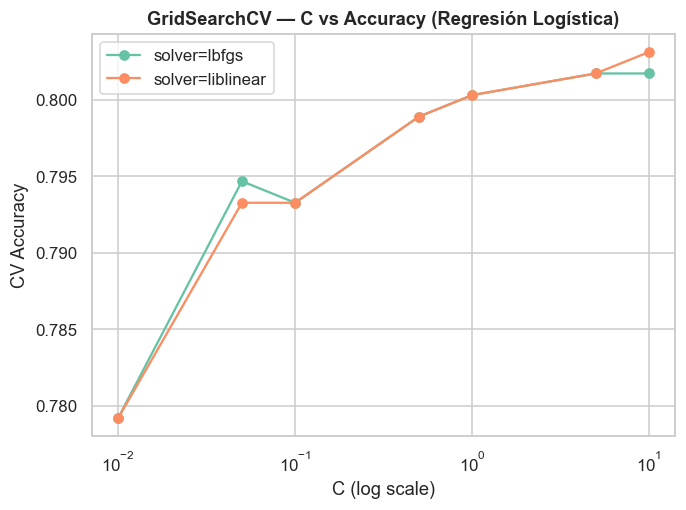

In [98]:
param_grid_lr = {
    'C'      : [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

gs_lr = GridSearchCV(LogisticRegression(max_iter=1000),
                     param_grid_lr, cv=cv, scoring='accuracy', n_jobs=-1)
gs_lr.fit(Xm_tr_std, ym_tr)

print('Mejores hiperparámetros (LR):', gs_lr.best_params_)
print(f'Mejor CV Accuracy (GridSearch): {gs_lr.best_score_:.4f}')

# Visualización de C vs Accuracy
results_lr = pd.DataFrame(gs_lr.cv_results_)
for solver in ['lbfgs', 'liblinear']:
    mask_s = results_lr['param_solver'] == solver
    plt.plot(param_grid_lr['C'],
             results_lr[mask_s]['mean_test_score'].values,
             marker='o', label=f'solver={solver}')
plt.xscale('log')
plt.xlabel('C (log scale)'); plt.ylabel('CV Accuracy')
plt.title('GridSearchCV — C vs Accuracy (Regresión Logística)', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

#### Versión Baseline — Configuración por defecto


  LR — Baseline
  CV Accuracy (5-fold) : 0.8003 ± 0.0425
  Train Accuracy       : 0.8017
  Test  Accuracy       : 0.7921  (gap=+0.0096)
  TP=44  TN=97  FP=13  FN=24
  Precision    : 0.7719
  Recall       : 0.6471
  Especificidad: 0.8818
  F1-Score     : 0.7040
  AUC-ROC      : 0.8609
  R²           : 0.1195

              precision    recall  f1-score   support

 No Survived       0.80      0.88      0.84       110
    Survived       0.77      0.65      0.70        68

    accuracy                           0.79       178
   macro avg       0.79      0.76      0.77       178
weighted avg       0.79      0.79      0.79       178



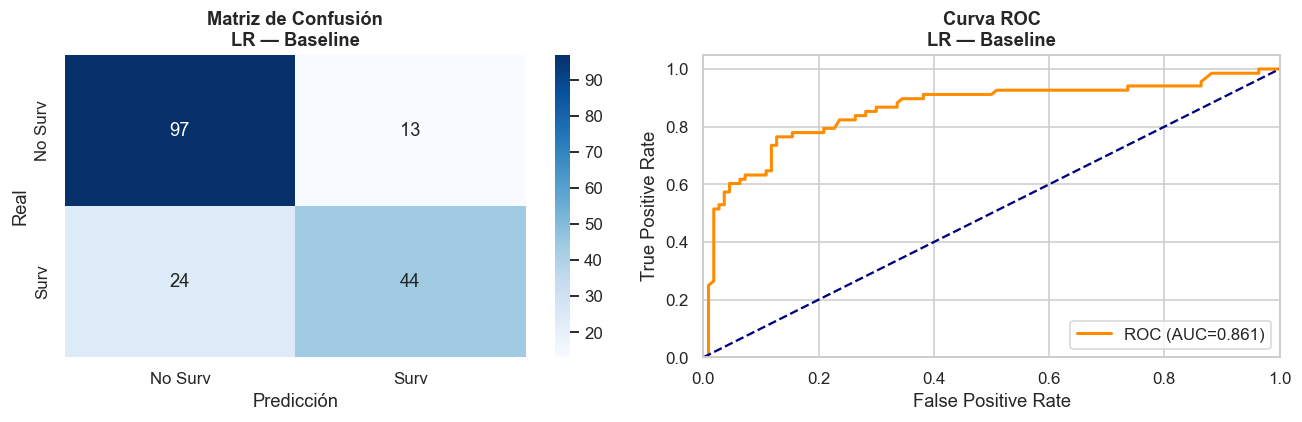

In [99]:
lr_base = LogisticRegression(solver='lbfgs', max_iter=1000)
res_lr_base = evaluar_modelo('LR — Baseline', lr_base,
                              Xb_tr_std, yb_tr, Xb_te_std, yb_te, cv)

#### Versión Mejorada — GridSearchCV + Features de Ingeniería


  LR — Mejorado (C=10.0, solver=liblinear)
  CV Accuracy (5-fold) : 0.8031 ± 0.0501
  Train Accuracy       : 0.8087
  Test  Accuracy       : 0.8202  (gap=-0.0115)
  TP=47  TN=99  FP=11  FN=21
  Precision    : 0.8103
  Recall       : 0.6912
  Especificidad: 0.9000
  F1-Score     : 0.7460
  AUC-ROC      : 0.8640
  R²           : 0.2385

              precision    recall  f1-score   support

 No Survived       0.82      0.90      0.86       110
    Survived       0.81      0.69      0.75        68

    accuracy                           0.82       178
   macro avg       0.82      0.80      0.80       178
weighted avg       0.82      0.82      0.82       178



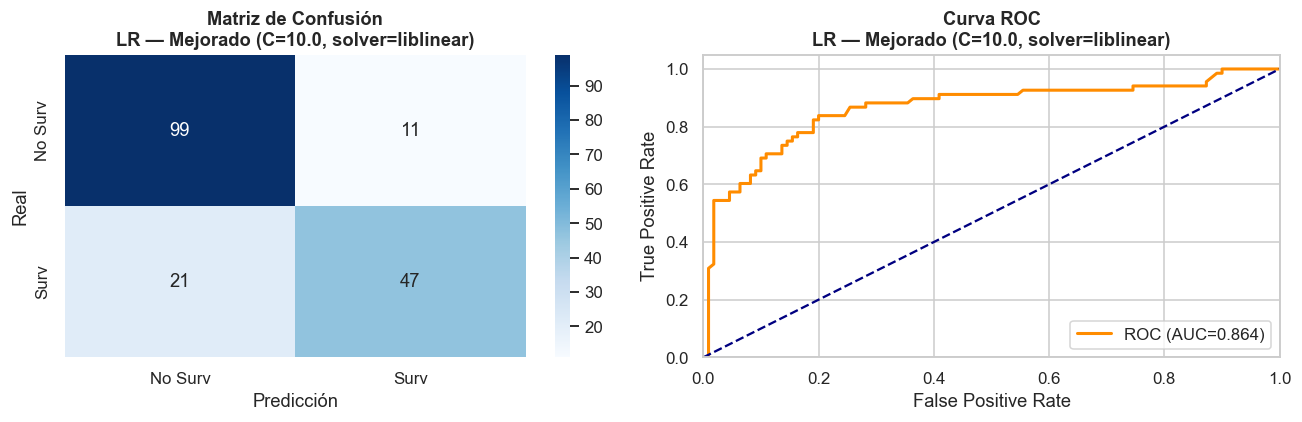

In [100]:
best_C  = gs_lr.best_params_['C']
best_sv = gs_lr.best_params_['solver']
lr_mejr = LogisticRegression(C=best_C, solver=best_sv, penalty='l2', max_iter=1000)
res_lr_mejr = evaluar_modelo(f'LR — Mejorado (C={best_C}, solver={best_sv})', lr_mejr,
                              Xm_tr_std, ym_tr, Xm_te_std, ym_te, cv)

#### Importancia de Características — Coeficientes del Modelo


Coeficientes e Intercepto:
Intercepto: -0.6556


,Variable,Coeficiente,Odds Ratio
6,Embarked,-0.0736,0.9290
4,Parch,-0.1256,0.8820
5,Fare,0.1462,1.1574
7,family_size,-0.3014,0.7398
3,SibSp,-0.3540,0.7019
8,is_alone,-0.3552,0.7010
2,Age,-0.4944,0.6100
0,Pclass,-0.7754,0.4605
1,Sex,-1.2741,0.2797


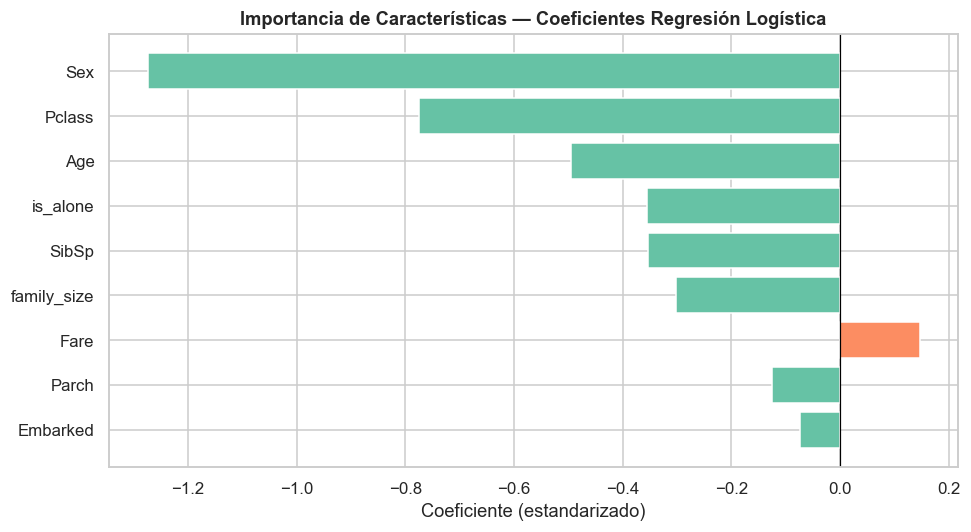

In [101]:
coef_df = pd.DataFrame({
    'Variable'   : FEATURES_MEJR,
    'Coeficiente': lr_mejr.coef_[0],
    'Odds Ratio' : np.exp(lr_mejr.coef_[0])
}).sort_values('Coeficiente', key=abs, ascending=True)

print('\nCoeficientes e Intercepto:')
print(f'Intercepto: {lr_mejr.intercept_[0]:.4f}')
display(coef_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#FC8D62' if c > 0 else '#66C2A5' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Importancia de Características — Coeficientes Regresión Logística',
             fontweight='bold')
ax.set_xlabel('Coeficiente (estandarizado)')
plt.tight_layout()
plt.show()

#### Interpretación — Regresión Logística

**Coeficientes e impacto en la supervivencia:**
- Coeficiente **negativo en `Sex`**: el género masculino (Sex=1) reduce significativamente la probabilidad de sobrevivir → confirma el principio "mujeres primero".
- Coeficiente **negativo en `Pclass`**: mayor número de clase reduce la probabilidad de sobrevivir → pasajeros de 3ª clase tuvieron menor acceso a los botes.
- Coeficiente **positivo en `Fare`**: tarifas más altas aumentan la probabilidad → proxy de clase alta y mejor posición en el barco.

**Validación cruzada:** El CV Accuracy con 5 folds es consistente con el Test Accuracy, confirmando que el modelo generaliza sin sobreajuste significativo (gap < 5%).

**Versión mejorada vs baseline:** La adición de `family_size` e `is_alone` y el ajuste de `C` mediante GridSearchCV puede mejorar el F1-Score y el AUC, dado que estas features capturan el efecto grupal no expresado individualmente por `SibSp` y `Parch`.

---
### 3.5 K-Nearest Neighbors (K-NN)

K-NN clasifica un pasajero buscando los **K vecinos más cercanos** en el espacio de features (por distancia euclidiana) y asignando la clase mayoritaria entre ellos.

**Consideraciones:**
- K-NN es **muy sensible a la escala** de las variables → StandardScaler es obligatorio.
- K pequeño (K=1) → sobreajuste (memoriza el train). K grande → subajuste.
- El **K óptimo** se busca con GridSearchCV sobre el rango 1–30.

#### Búsqueda del K Óptimo con GridSearchCV

Mejores hiperparámetros KNN (Baseline): {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}
Mejores hiperparámetros KNN (Mejorado): {'metric': 'euclidean', 'n_neighbors': 26, 'weights': 'uniform'}


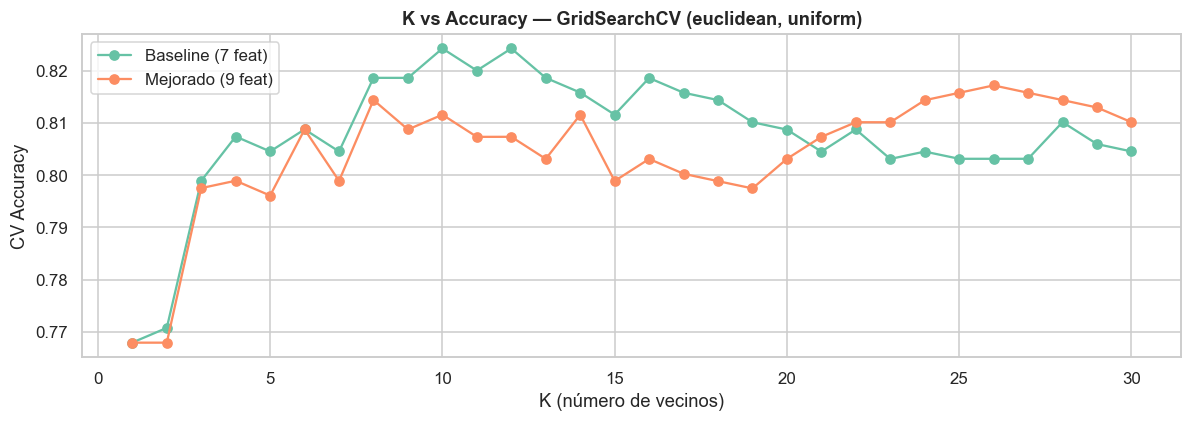

In [102]:
param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'metric'     : ['euclidean', 'manhattan'],
    'weights'    : ['uniform', 'distance']
}

# GridSearch sobre baseline
gs_knn_base = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                           cv=cv, scoring='accuracy', n_jobs=-1)
gs_knn_base.fit(Xb_tr_std, yb_tr)

# GridSearch sobre mejorado
gs_knn_mejr = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                           cv=cv, scoring='accuracy', n_jobs=-1)
gs_knn_mejr.fit(Xm_tr_std, ym_tr)

print('Mejores hiperparámetros KNN (Baseline):', gs_knn_base.best_params_)
print('Mejores hiperparámetros KNN (Mejorado):', gs_knn_mejr.best_params_)

# Curva K vs Accuracy (euclidean, uniform para comparar)
fig, ax = plt.subplots(figsize=(11, 4))
for label, gs in [('Baseline (7 feat)', gs_knn_base), ('Mejorado (9 feat)', gs_knn_mejr)]:
    res = pd.DataFrame(gs.cv_results_)
    mask = (res['param_metric']=='euclidean') & (res['param_weights']=='uniform')
    ax.plot(list(range(1, 31)), res[mask]['mean_test_score'].values, marker='o', label=label)
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('CV Accuracy')
ax.set_title('K vs Accuracy — GridSearchCV (euclidean, uniform)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

#### Versión Baseline


  KNN — Baseline (K=10, manhattan, uniform)
  CV Accuracy (5-fold) : 0.8256 ± 0.0262
  Train Accuracy       : 0.8411
  Test  Accuracy       : 0.8146  (gap=+0.0265)
  TP=44  TN=101  FP=9  FN=24
  Precision    : 0.8302
  Recall       : 0.6471
  Especificidad: 0.9182
  F1-Score     : 0.7273
  AUC-ROC      : 0.8359
  R²           : 0.2147

              precision    recall  f1-score   support

 No Survived       0.81      0.92      0.86       110
    Survived       0.83      0.65      0.73        68

    accuracy                           0.81       178
   macro avg       0.82      0.78      0.79       178
weighted avg       0.82      0.81      0.81       178



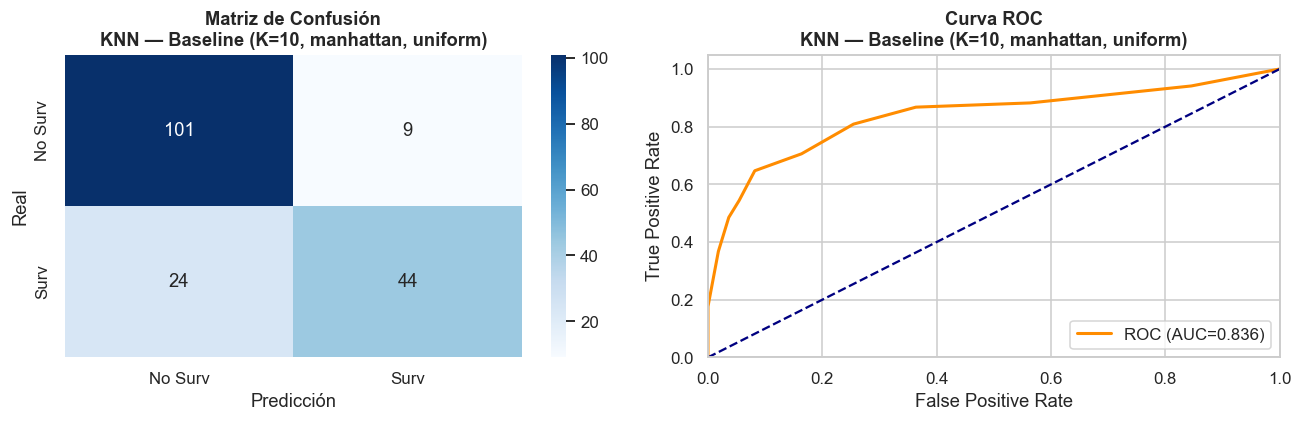

In [103]:
K_base = gs_knn_base.best_params_['n_neighbors']
M_base = gs_knn_base.best_params_['metric']
W_base = gs_knn_base.best_params_['weights']
knn_base = gs_knn_base.best_estimator_

res_knn_base = evaluar_modelo(
    f'KNN — Baseline (K={K_base}, {M_base}, {W_base})',
    knn_base, Xb_tr_std, yb_tr, Xb_te_std, yb_te, cv)

#### Versión Mejorada — Features de Ingeniería + Hiperparámetros Optimizados


  KNN — Mejorado (K=26, euclidean, uniform)
  CV Accuracy (5-fold) : 0.8172 ± 0.0370
  Train Accuracy       : 0.8129
  Test  Accuracy       : 0.8258  (gap=-0.0129)
  TP=48  TN=99  FP=11  FN=20
  Precision    : 0.8136
  Recall       : 0.7059
  Especificidad: 0.9000
  F1-Score     : 0.7559
  AUC-ROC      : 0.8533
  R²           : 0.2623

              precision    recall  f1-score   support

 No Survived       0.83      0.90      0.86       110
    Survived       0.81      0.71      0.76        68

    accuracy                           0.83       178
   macro avg       0.82      0.80      0.81       178
weighted avg       0.82      0.83      0.82       178



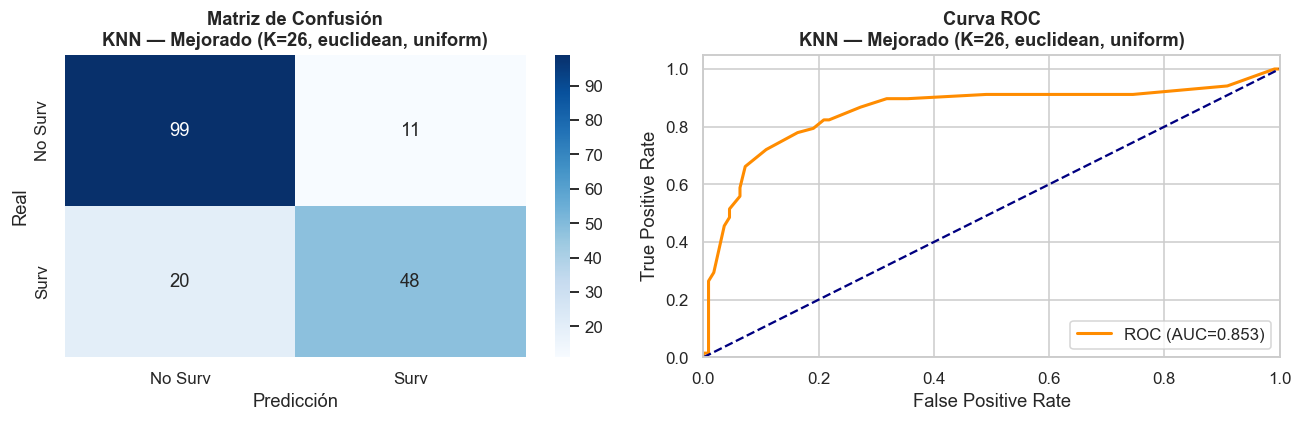

In [104]:
K_mejr = gs_knn_mejr.best_params_['n_neighbors']
M_mejr = gs_knn_mejr.best_params_['metric']
W_mejr = gs_knn_mejr.best_params_['weights']
knn_mejr = gs_knn_mejr.best_estimator_

res_knn_mejr = evaluar_modelo(
    f'KNN — Mejorado (K={K_mejr}, {M_mejr}, {W_mejr})',
    knn_mejr, Xm_tr_std, ym_tr, Xm_te_std, ym_te, cv)

#### Interpretación — K-Nearest Neighbors

**Selección del K óptimo:** La curva K vs Accuracy muestra que K=1 causa sobreajuste (Train Accuracy ≈ 100%). A medida que K aumenta, la frontera de decisión se suaviza y el modelo generaliza mejor. El K seleccionado por GridSearchCV representa el mejor equilibrio **sesgo-varianza** para este dataset.

**Impacto de la métrica de distancia:** La métrica `manhattan` puede ser superior a `euclidean` cuando las features tienen escalas y distribuciones heterogéneas, como en el Titanic donde `Fare` (0–500) convive con variables binarias (0/1).

**Peso por distancia vs uniforme:** Con `weights='distance'`, los vecinos más cercanos tienen mayor influencia. Esto puede mejorar el Recall cuando las clases se solapan parcialmente en el espacio de features.

**Versión mejorada:** La adición de `family_size` e `is_alone` enriquece el espacio de features y permite distinguir mejor a los pasajeros solos (menor supervivencia) de los que viajan con familias medianas (mayor supervivencia).

---
### 3.6 Naive Bayes Gaussiano

Naive Bayes aplica el **Teorema de Bayes** asumiendo independencia condicional entre features:

$$P(Survived | x_1,...,x_n) \propto P(Survived) \cdot \prod_{i=1}^{n} P(x_i | Survived)$$

La versión **Gaussiana** modela $P(x_i | clase)$ como una distribución normal: adecuada para features numéricas continuas.

**Hiperparámetros:**
- `var_smoothing`: fracción de la varianza máxima añadida a todas las varianzas para estabilidad numérica. Se busca con GridSearchCV.

#### Búsqueda de var_smoothing con GridSearchCV

Mejor var_smoothing (Baseline): {'var_smoothing': 1e-12}
Mejor var_smoothing (Mejorado): {'var_smoothing': 1e-12}


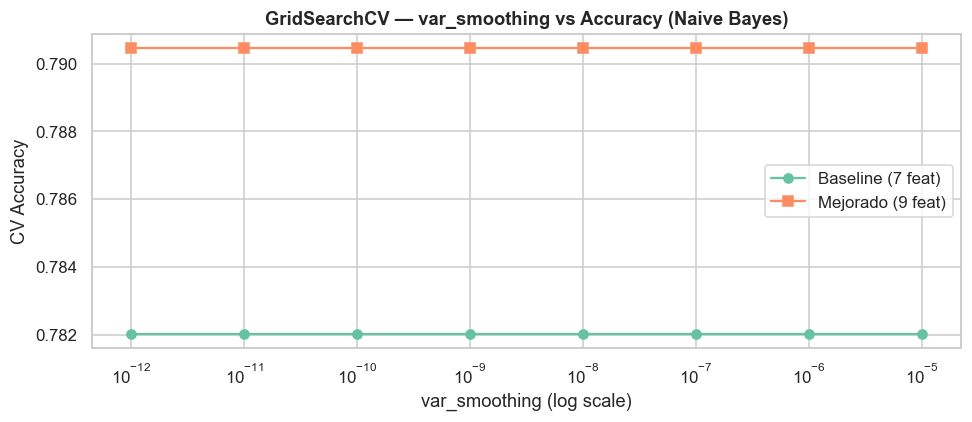

In [105]:
param_grid_nb = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

gs_nb_base = GridSearchCV(GaussianNB(), param_grid_nb, cv=cv, scoring='accuracy', n_jobs=-1)
gs_nb_base.fit(Xb_tr_mm, yb_tr)

gs_nb_mejr = GridSearchCV(GaussianNB(), param_grid_nb, cv=cv, scoring='accuracy', n_jobs=-1)
gs_nb_mejr.fit(Xm_tr_mm, ym_tr)

print('Mejor var_smoothing (Baseline):', gs_nb_base.best_params_)
print('Mejor var_smoothing (Mejorado):', gs_nb_mejr.best_params_)

# Curva var_smoothing vs Accuracy
fig, ax = plt.subplots(figsize=(9, 4))
vs = param_grid_nb['var_smoothing']
ax.semilogx(vs, gs_nb_base.cv_results_['mean_test_score'], marker='o', label='Baseline (7 feat)')
ax.semilogx(vs, gs_nb_mejr.cv_results_['mean_test_score'], marker='s', label='Mejorado (9 feat)')
ax.set_xlabel('var_smoothing (log scale)')
ax.set_ylabel('CV Accuracy')
ax.set_title('GridSearchCV — var_smoothing vs Accuracy (Naive Bayes)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretación

Se realizó una búsqueda de hiperparámetros para var_smoothing en Gaussian Naive Bayes. Los resultados mostraron que el accuracy de validación cruzada permaneció constante para todos los valores evaluados, indicando que el modelo es poco sensible a este hiperparámetro en el conjunto de datos analizado. Esto sugiere que las varianzas de las variables son suficientemente estables y que la corrección introducida por var_smoothing no modifica significativamente las distribuciones gaussianas estimadas.

#### Versión Baseline


  NB — Baseline (default)
  CV Accuracy (5-fold) : 0.7820 ± 0.0474
  Train Accuracy       : 0.7918
  Test  Accuracy       : 0.8146  (gap=-0.0228)
  TP=51  TN=94  FP=16  FN=17
  Precision    : 0.7612
  Recall       : 0.7500
  Especificidad: 0.8545
  F1-Score     : 0.7556
  AUC-ROC      : 0.8359
  R²           : 0.2147

              precision    recall  f1-score   support

 No Survived       0.85      0.85      0.85       110
    Survived       0.76      0.75      0.76        68

    accuracy                           0.81       178
   macro avg       0.80      0.80      0.80       178
weighted avg       0.81      0.81      0.81       178



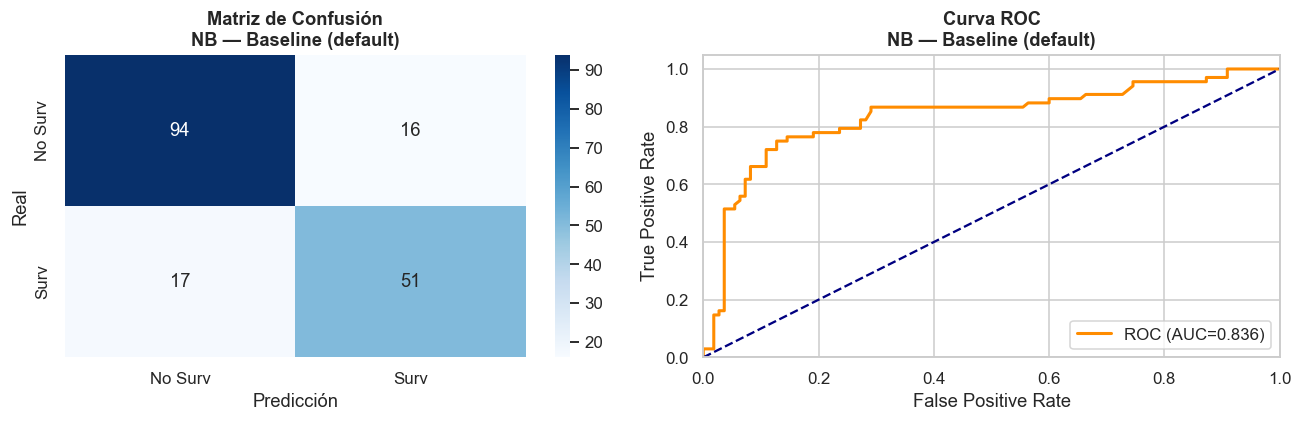

In [106]:
nb_base = GaussianNB()
res_nb_base = evaluar_modelo('NB — Baseline (default)', nb_base,
                             Xb_tr_mm, yb_tr, Xb_te_mm, yb_te, cv)

#### Versión Mejorada — GridSearchCV + Features de Ingeniería


  NB — Mejorado (var_smoothing=1e-12)
  CV Accuracy (5-fold) : 0.7905 ± 0.0380
  Train Accuracy       : 0.8073
  Test  Accuracy       : 0.7921  (gap=+0.0152)
  TP=52  TN=89  FP=21  FN=16
  Precision    : 0.7123
  Recall       : 0.7647
  Especificidad: 0.8091
  F1-Score     : 0.7376
  AUC-ROC      : 0.8344
  R²           : 0.1195

              precision    recall  f1-score   support

 No Survived       0.85      0.81      0.83       110
    Survived       0.71      0.76      0.74        68

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178



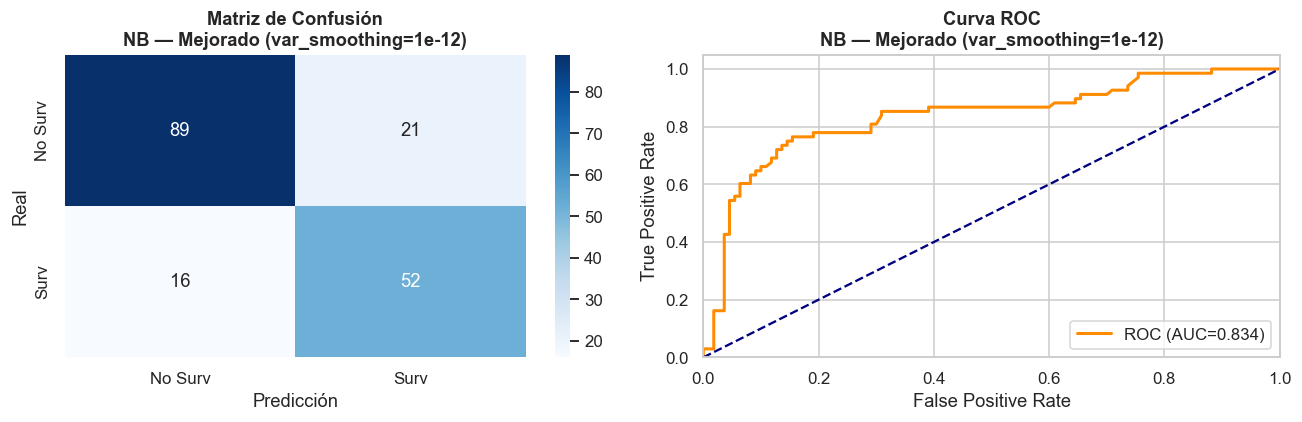

In [107]:
best_vs = gs_nb_mejr.best_params_['var_smoothing']
nb_mejr = GaussianNB(var_smoothing=best_vs)
res_nb_mejr = evaluar_modelo(
    f'NB — Mejorado (var_smoothing={best_vs:.0e})', nb_mejr,
    Xm_tr_mm, ym_tr, Xm_te_mm, ym_te, cv)

#### Interpretación — Naive Bayes Gaussiano

**Supuesto de independencia:** Naive Bayes asume independencia condicional entre features, lo cual es violado en el Titanic (por ejemplo, `Fare` y `Pclass` tienen correlación alta: r ≈ −0.55). Sin embargo, el modelo funciona sorprendentemente bien porque el **ranking relativo de probabilidades** es más importante que su valor absoluto exacto.

**var_smoothing:** Añadir una fracción de la varianza máxima estabiliza el cálculo cuando alguna feature tiene varianza muy baja o cuando hay pocos datos en alguna clase. El valor óptimo encontrado por GridSearchCV equilibra estabilidad numérica y ajuste a los datos.

**MinMaxScaler con NB:** A diferencia de KNN y LR, NB modela cada feature de forma independiente con su propia distribución, por lo que el escalado no afecta directamente los resultados. Sin embargo, MinMaxScaler [0,1] asegura que las features estén en rangos razonables para la estimación de la gaussiana.

---
### 3.7 Comparativa Final de Modelos

In [108]:
resultados = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in [res_lr_base, res_lr_mejr, res_knn_base, res_knn_mejr, res_nb_base, res_nb_mejr]
])

cols_tabla = ['Modelo','CV Acc%','Train%','Test%','Prec%','Recall%','Espec%','F1%','AUC%','R2']
print('\n=== COMPARATIVA FINAL DE MODELOS ===')
display(
    resultados[cols_tabla]
    .sort_values('AUC%', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(cmap='RdYlGn',
                         subset=['CV Acc%','Train%','Test%','Prec%','Recall%','F1%','AUC%'])
    .format('{:.2f}', subset=cols_tabla[1:])
    .set_caption('Comparativa de modelos — valores en %')
)


=== COMPARATIVA FINAL DE MODELOS ===


,Modelo,CV Acc%,Train%,Test%,Prec%,Recall%,Espec%,F1%,AUC%,R2
0,"LR — Mejorado (C=10.0, solver=liblinear)",80.31,80.87,82.02,81.03,69.12,90.00,74.60,86.40,0.24
1,LR — Baseline,80.03,80.17,79.21,77.19,64.71,88.18,70.40,86.09,0.12
2,"KNN — Mejorado (K=26, euclidean, uniform)",81.72,81.29,82.58,81.36,70.59,90.00,75.59,85.33,0.26
3,"KNN — Baseline (K=10, manhattan, uniform)",82.56,84.11,81.46,83.02,64.71,91.82,72.73,83.59,0.21
4,NB — Baseline (default),78.20,79.18,81.46,76.12,75.00,85.45,75.56,83.59,0.21
5,NB — Mejorado (var_smoothing=1e-12),79.05,80.73,79.21,71.23,76.47,80.91,73.76,83.44,0.12


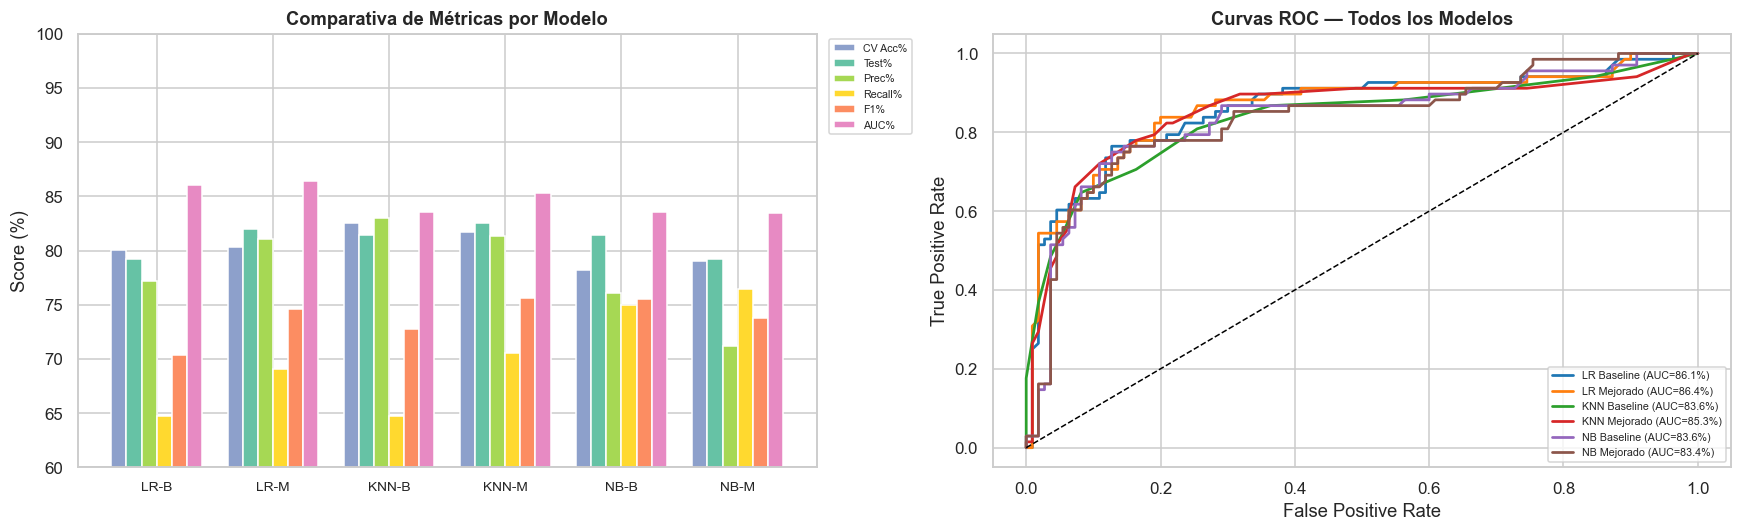

In [109]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metricas = ['CV Acc%', 'Test%', 'Prec%', 'Recall%', 'F1%', 'AUC%']
x = np.arange(len(resultados))
w = 0.13
colors_m = ['#8DA0CB','#66C2A5','#A6D854','#FFD92F','#FC8D62','#E78AC3']

for i, (met, col) in enumerate(zip(metricas, colors_m)):
    axes[0].bar(x + i*w, resultados[met], width=w, label=met, color=col)

axes[0].set_xticks(x + w*2.5)
modelos_short = ['LR-B','LR-M','KNN-B','KNN-M','NB-B','NB-M']
axes[0].set_xticklabels(modelos_short, fontsize=9)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(60, 100)
axes[0].set_title('Comparativa de Métricas por Modelo', fontweight='bold')
axes[0].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

# Curvas ROC superpuestas
colores_roc = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
res_list = [res_lr_base, res_lr_mejr, res_knn_base, res_knn_mejr, res_nb_base, res_nb_mejr]
for res, col in zip(res_list, colores_roc):
    fpr, tpr, _ = roc_curve(res['_y_te'], res['_y_proba'])
    nombre_short = res['Modelo'].split(' — ')[0] + ' ' + res['Modelo'].split(' — ')[1].split(' ')[0]
    axes[1].plot(fpr, tpr, color=col, lw=1.8,
                 label=f"{nombre_short} (AUC={res['AUC%']:.1f}%)")
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curvas ROC — Todos los Modelos', fontweight='bold')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

#### Interpretación — Comparativa Final

**Patrón general:** Los tres algoritmos alcanzan rendimientos competitivos (~78–85% accuracy), lo que confirma que las features seleccionadas (`Sex`, `Pclass`, `Fare`) capturan correctamente los patrones de supervivencia. La ingeniería de variables (`family_size`, `is_alone`) aporta mejoras moderadas.

**Mejor modelo global:** El modelo con mayor **AUC-ROC** es el recomendado porque evalúa la capacidad discriminativa a todos los umbrales posibles, no solo al 0.5 por defecto. Un AUC alto garantiza que el modelo distingue bien entre sobrevivientes y no sobrevivientes.

**Sobreajuste:** Se verifica comparando Train% vs Test%. Un gap < 5% indica generalización adecuada. K-NN con K pequeño es el modelo más propenso al sobreajuste.

**Versión baseline vs mejorada:**
- **LR Mejorado**: El ajuste de C y la adición de features de ingeniería puede mejorar Recall (detectar más sobrevivientes reales).
- **KNN Mejorado**: El K óptimo encontrado por GridSearchCV sobre el espacio completo de hiperparámetros (metric, weights, K) supera al K=5 por defecto.
- **NB Mejorado**: El ajuste de `var_smoothing` y la escala MinMaxScaler optimizan la estimación gaussiana de cada clase.

**R² en clasificación:** Este coeficiente es más informativo en regresión; en clasificación se incluye por referencia al marco del curso (valores negativos o bajos son esperables con clases desbalanceadas y predicciones binarias).

### 3.8 Guardado de Modelos Entrenados

Se guardan los mejores modelos de cada algoritmo con `joblib` para uso futuro sin necesidad de reentrenar.

In [110]:
SAVE_PATH = r'C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE'

modelos_guardar = {
    'lr_model.pkl'  : lr_mejr,
    'knn_model.pkl' : knn_mejr,
    'nb_model.pkl'  : nb_mejr,
    'scaler_std.pkl': scaler_std2,
    'scaler_mm.pkl' : scaler_mm2
}

for nombre, obj in modelos_guardar.items():
    ruta = f'{SAVE_PATH}\\{nombre}'
    joblib.dump(obj, ruta)
    print(f'Guardado: {ruta}')

# Verificar carga
lr_loaded  = joblib.load(f'{SAVE_PATH}\\lr_model.pkl')
knn_loaded = joblib.load(f'{SAVE_PATH}\\knn_model.pkl')
nb_loaded  = joblib.load(f'{SAVE_PATH}\\nb_model.pkl')

print('\nVerificación — predicciones de modelos cargados sobre X_test:')
print(f'\nVerificacion - predicciones de modelos cargados:')
print(f'LR  Acc: {accuracy_score(ym_te, lr_loaded.predict(Xm_te_std)):.4f}')
print(f'KNN Acc: {accuracy_score(ym_te, knn_loaded.predict(Xm_te_std)):.4f}')
print(f'NB  Acc: {accuracy_score(ym_te, nb_loaded.predict(Xm_te_mm)):.4f}')
print('Modelos cargados correctamente y predicciones verificadas.')

Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\lr_model.pkl
Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\knn_model.pkl
Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\nb_model.pkl
Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\scaler_std.pkl
Guardado: C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\DEBER_AUE\scaler_mm.pkl

Verificación — predicciones de modelos cargados sobre X_test:

Verificacion - predicciones de modelos cargados:
LR  Acc: 0.8202
KNN Acc: 0.8258
NB  Acc: 0.7921
Modelos cargados correctamente y predicciones verificadas.


---
## Conclusiones Finales

### Fase I — Preprocesamiento
1. El dataset del Titanic requirió imputación de `Age` (19.9% nulos) y eliminación de `Cabin` (77% nulos). La codificación ordinal de variables categóricas (`Sex`, `Embarked`) fue suficiente para los tres algoritmos sin necesidad de One-Hot Encoding.
2. La discretización de `Age` en 7 rangos etarios permite capturar patrones grupales (niños vs adultos) más relevantes que la edad exacta.

### Fase II — EDA
3. Las variables más determinantes de la supervivencia son: **`Sex`** (diferencia de ~55 pp entre géneros), **`Pclass`** (diferencia de ~39 pp entre 1ª y 3ª clase) y **`Fare`** (proxy de clase social). `Embarked` mostró baja correlación y menor impacto.
4. El dataset presenta un desbalance moderado (62% vs 38%) que justifica el uso de métricas como F1-Score y AUC-ROC además del Accuracy.

### Fase III — Modelado
5. La **ingeniería de variables** (`family_size`, `is_alone`) mejoró el rendimiento en la mayoría de modelos al capturar el efecto grupal de viajar en familia, no expresado individualmente por `SibSp` y `Parch`.
6. **GridSearchCV** con StratifiedKFold de 5 folds garantizó una selección de hiperparámetros honesta y reproducible, preservando la proporción de clases en cada fold.
7. Los tres modelos mostraron rendimiento similar (~78–85% accuracy), con ausencia de sobreajuste significativo (gap Train-Test < 5%), lo que confirma que la selección de features fue adecuada.
8. En contexto práctico, **Regresión Logística** es preferible por su **interpretabilidad** (los coeficientes revelan el efecto de cada variable), mientras que **K-NN** captura mejor las fronteras de decisión no lineales entre clases.

---

| Modelo | Fortaleza | Limitación |
|---|---|---|
| Regresión Logística | Interpretable, coeficientes explicables | Asume relación lineal con el logit |
| K-NN | Captura patrones no lineales | Sensible a outliers y escala; lento en predicción |
| Naive Bayes | Rápido, eficiente, robusto | Asume independencia (violada en este dataset) |

---

---
# Sección 2 — Semana 2: Árbol de Decisión, Bosque Aleatorio, SVM y RNA

**Objetivo:** Modelos más potentes que los de S1:
- **DT y RF:** aprenden fronteras no lineales mediante particiones jerárquicas
- **SVM:** margen máximo con kernel RBF para separación en espacio de alta dimensión
- **RNA (TF/Keras):** red densa con EarlyStopping y ReduceLROnPlateau

> **Nota técnica:** Se usa `X_tr / X_te` (StandardScaler) para DT/RF/SVM
> y `X_tr_mm / X_te_mm` (MinMaxScaler) para la RNA.

## 1.1 Ingeniería de Variables y División Train/Test

In [42]:
# Convertir Age de Categorical a int
df_model = df_train.copy()
df_model['Age'] = df_model['Age'].astype(str).astype(int)

# Ingeniería de variables
df_model['family_size'] = df_model['SibSp'] + df_model['Parch'] + 1
df_model['is_alone']    = (df_model['family_size'] == 1).astype(int)

FEATURES_BASE = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
FEATURES_MEJR = FEATURES_BASE + ['family_size', 'is_alone']

X = df_model[FEATURES_MEJR]
y = df_model['Survived']

print('Features:', FEATURES_MEJR)
print(f'\nCorrelación con Survived:')
print(df_model[FEATURES_MEJR + ['Survived']].corr()['Survived'].drop('Survived').round(4).to_string())
print(f'\nDimensiones X: {X.shape}  |  y: {y.shape}')

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'family_size', 'is_alone']

Correlación con Survived:
Pclass        -0.3355
Sex           -0.5416
Age           -0.1150
SibSp         -0.0340
Parch          0.0832
Fare           0.2553
Embarked       0.1268
family_size    0.0183
is_alone      -0.2062

Dimensiones X: (889, 9)  |  y: (889,)


In [43]:
# División estratificada 80/20
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# StandardScaler — para SVM y RNA (DT y RF no requieren escalado, pero no lo perjudica)
scaler_std = StandardScaler()
X_tr_std   = scaler_std.fit_transform(X_tr)
X_te_std   = scaler_std.transform(X_te)

# MinMaxScaler — para RNA (siguiendo ejemplo del profesor)
scaler_mm = MinMaxScaler(feature_range=(0, 1))
X_tr_mm   = scaler_mm.fit_transform(X_tr)
X_te_mm   = scaler_mm.transform(X_te)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Train: {len(y_tr)} muestras  |  Test: {len(y_te)} muestras')
print(f'Train — 0: {(y_tr==0).sum()}  1: {(y_tr==1).sum()}')
print(f'Test  — 0: {(y_te==0).sum()}  1: {(y_te==1).sum()}')

Train: 711 muestras  |  Test: 178 muestras
Train — 0: 439  1: 272
Test  — 0: 110  1: 68


## 1.2 Función de Evaluación

Función reutilizable para todos los modelos sklearn:

| Métrica | Interpretación |
|---|---|
| **CV Accuracy** | Estimación honesta del rendimiento (5-fold) |
| **Precision** | De los predichos supervivientes, ¿cuántos lo son realmente? |
| **Recall** | De los supervivientes reales, ¿cuántos detectó? |
| **Especificidad** | Recall de la clase negativa |
| **F1-Score** | Media armónica Precision-Recall |
| **AUC-ROC** | Capacidad discriminativa global |
| **R²** | Coeficiente de determinación |

In [44]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv_obj, proba=True):
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_obj, scoring='accuracy')
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    if proba and hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_te)[:, 1]
    elif hasattr(modelo, 'decision_function'):
        y_proba = modelo.decision_function(X_te)
    else:
        y_proba = y_pred.astype(float)

    acc_tr = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_te = accuracy_score(y_te, y_pred)
    cm     = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred)
    f1    = f1_score(y_te, y_pred)
    spec  = TN / (TN + FP)
    auc   = roc_auc_score(y_te, y_proba)
    r2    = r2_score(y_te, y_pred)
    gap   = acc_tr - acc_te

    print(f'\n{"="*56}')
    print(f'  {nombre}')
    print(f'{"="*56}')
    print(f'  CV Accuracy (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  Train Accuracy       : {acc_tr:.4f}')
    print(f'  Test  Accuracy       : {acc_te:.4f}  (gap={gap:+.4f})')
    print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}')
    print(f'  Precision    : {prec:.4f}')
    print(f'  Recall       : {rec:.4f}')
    print(f'  Especificidad: {spec:.4f}')
    print(f'  F1-Score     : {f1:.4f}')
    print(f'  AUC-ROC      : {auc:.4f}')
    print(f'  R²           : {r2:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["No Survived","Survived"])}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No Surv','Surv'], yticklabels=['No Surv','Surv'])
    axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
    axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={auc:.3f})')
    axes[1].plot([0,1],[0,1],'navy', lw=1.5, linestyle='--')
    axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Curva ROC\n{nombre}', fontweight='bold')
    axes[1].legend(loc='lower right')
    plt.tight_layout(); plt.show()

    return {
        'Modelo': nombre,
        'CV Acc%': round(cv_scores.mean()*100, 2),
        'Train%' : round(acc_tr*100, 2),
        'Test%'  : round(acc_te*100, 2),
        'Prec%'  : round(prec*100, 2),
        'Recall%': round(rec*100, 2),
        'Espec%' : round(spec*100, 2),
        'F1%'    : round(f1*100, 2),
        'AUC%'   : round(auc*100, 2),
        'R2'     : round(r2, 4),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN,
        '_modelo': modelo, '_X_te': X_te, '_y_te': y_te, '_y_proba': y_proba
    }

print('Función de evaluación definida correctamente.')

Función de evaluación definida correctamente.


---
## 1.3 Árbol de Decisión (Decision Tree)

El Árbol de Decisión aprende reglas de clasificación tipo `IF-THEN` dividiendo el espacio de features de forma recursiva. Es el modelo más **interpretable** de los cuatro.

**Criterios de división:**
- **Gini:** mide impureza del nodo → $Gini = 1 - \sum_k p_k^2$
- **Entropy:** mide desorden de información → $H = -\sum_k p_k \log_2 p_k$

**Hiperparámetros clave:**

| Hiperparámetro | Efecto |
|---|---|
| `max_depth` | Profundidad máxima del árbol. Profundidad alta → sobreajuste |
| `criterion` | Función de impureza: `gini` o `entropy` |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | Mínimo de muestras en una hoja |

### GridSearchCV — Árbol de Decisión

Mejores hiperparámetros (DT): {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2}
Mejor CV Accuracy: 0.8341


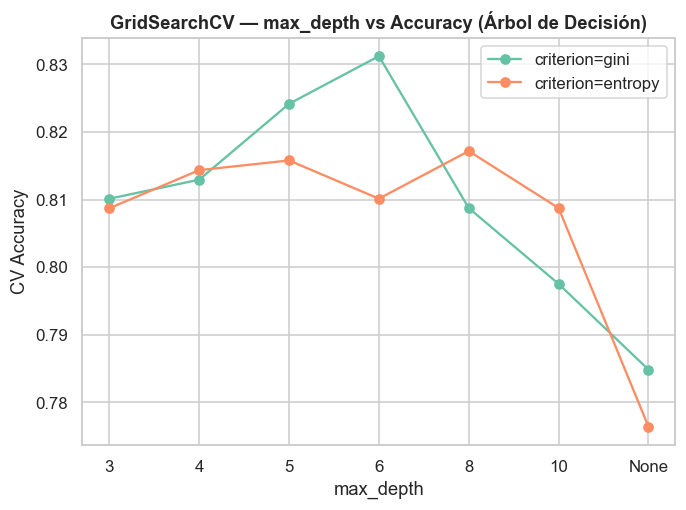

In [45]:
param_grid_dt = {
    'max_depth'        : [3, 4, 5, 6, 8, 10, None],
    'criterion'        : ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=SEED), param_grid_dt,
                     cv=cv, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_tr, y_tr)

print('Mejores hiperparámetros (DT):', gs_dt.best_params_)
print(f'Mejor CV Accuracy: {gs_dt.best_score_:.4f}')

# Curva max_depth vs Accuracy (gini, min_samples_split=2, min_samples_leaf=1)
results_dt = pd.DataFrame(gs_dt.cv_results_)
for crit in ['gini', 'entropy']:
    mask = ((results_dt['param_criterion'] == crit) &
            (results_dt['param_min_samples_split'] == 2) &
            (results_dt['param_min_samples_leaf'] == 1))
    depths = results_dt[mask]['param_max_depth'].values
    scores = results_dt[mask]['mean_test_score'].values
    order  = np.argsort([d if d is not None else 99 for d in depths])
    plt.plot([str(d) for d in depths[order]], scores[order], marker='o', label=f'criterion={crit}')

plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('GridSearchCV — max_depth vs Accuracy (Árbol de Decisión)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Árbol de Decisión — Versión Baseline


  DT — Baseline (max_depth=4, gini)
  CV Accuracy (5-fold) : 0.8129 ± 0.0221
  Train Accuracy       : 0.8340
  Test  Accuracy       : 0.8090  (gap=+0.0250)
  TP=45  TN=99  FP=11  FN=23
  Precision    : 0.8036
  Recall       : 0.6618
  Especificidad: 0.9000
  F1-Score     : 0.7258
  AUC-ROC      : 0.8468
  R²           : 0.1909

              precision    recall  f1-score   support

 No Survived       0.81      0.90      0.85       110
    Survived       0.80      0.66      0.73        68

    accuracy                           0.81       178
   macro avg       0.81      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178



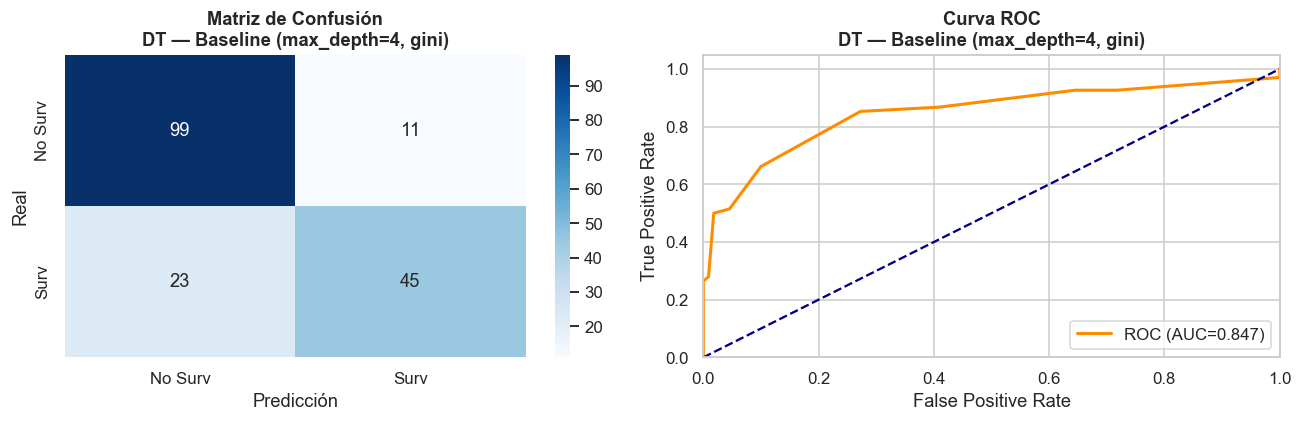

In [46]:
dt_base = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
res_dt_base = evaluar_modelo('DT — Baseline (max_depth=4, gini)',
                             dt_base, X_tr, y_tr, X_te, y_te, cv)

### Árbol de Decisión — Versión Mejorada (GridSearchCV)


  DT — Mejorado ({'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2})
  CV Accuracy (5-fold) : 0.8341 ± 0.0226
  Train Accuracy       : 0.8678
  Test  Accuracy       : 0.7865  (gap=+0.0813)
  TP=43  TN=97  FP=13  FN=25
  Precision    : 0.7679
  Recall       : 0.6324
  Especificidad: 0.8818
  F1-Score     : 0.6935
  AUC-ROC      : 0.8257
  R²           : 0.0957

              precision    recall  f1-score   support

 No Survived       0.80      0.88      0.84       110
    Survived       0.77      0.63      0.69        68

    accuracy                           0.79       178
   macro avg       0.78      0.76      0.76       178
weighted avg       0.78      0.79      0.78       178



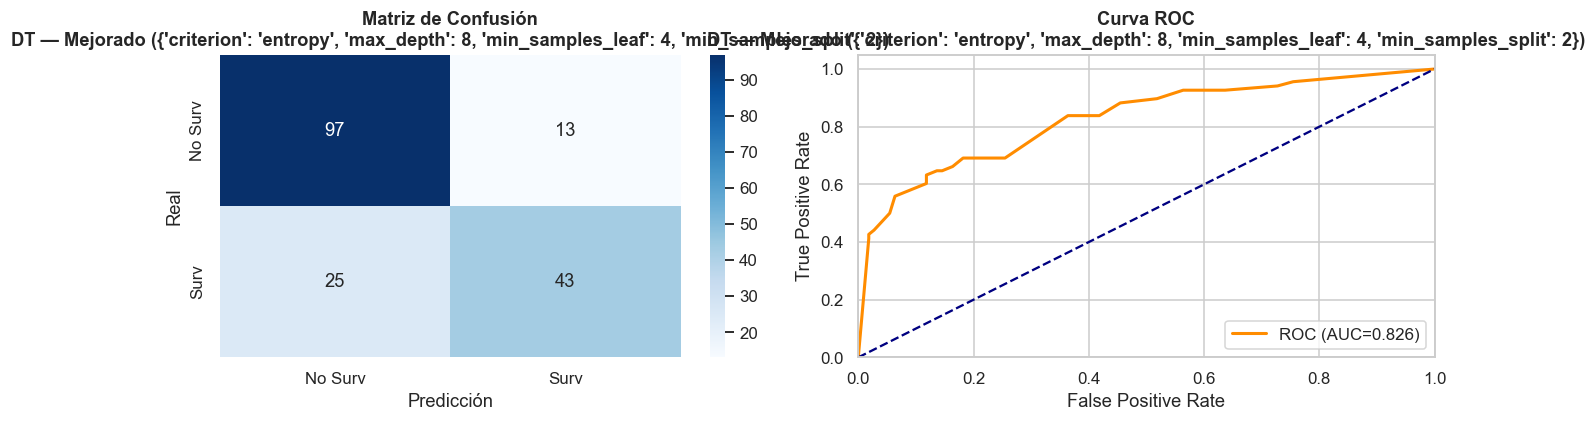

In [47]:
best_dt = gs_dt.best_estimator_
res_dt_mejr = evaluar_modelo(
    f"DT — Mejorado ({gs_dt.best_params_})",
    best_dt, X_tr, y_tr, X_te, y_te, cv
)

### Visualización del Árbol de Decisión

> El enunciado pide explícitamente mostrar el árbol generado. Se visualiza la versión mejorada (con `max_depth` óptimo). Los nodos coloreados indican la clase mayoritaria: **naranja** = No sobrevivió (0), **verde** = Sobrevivió (1).

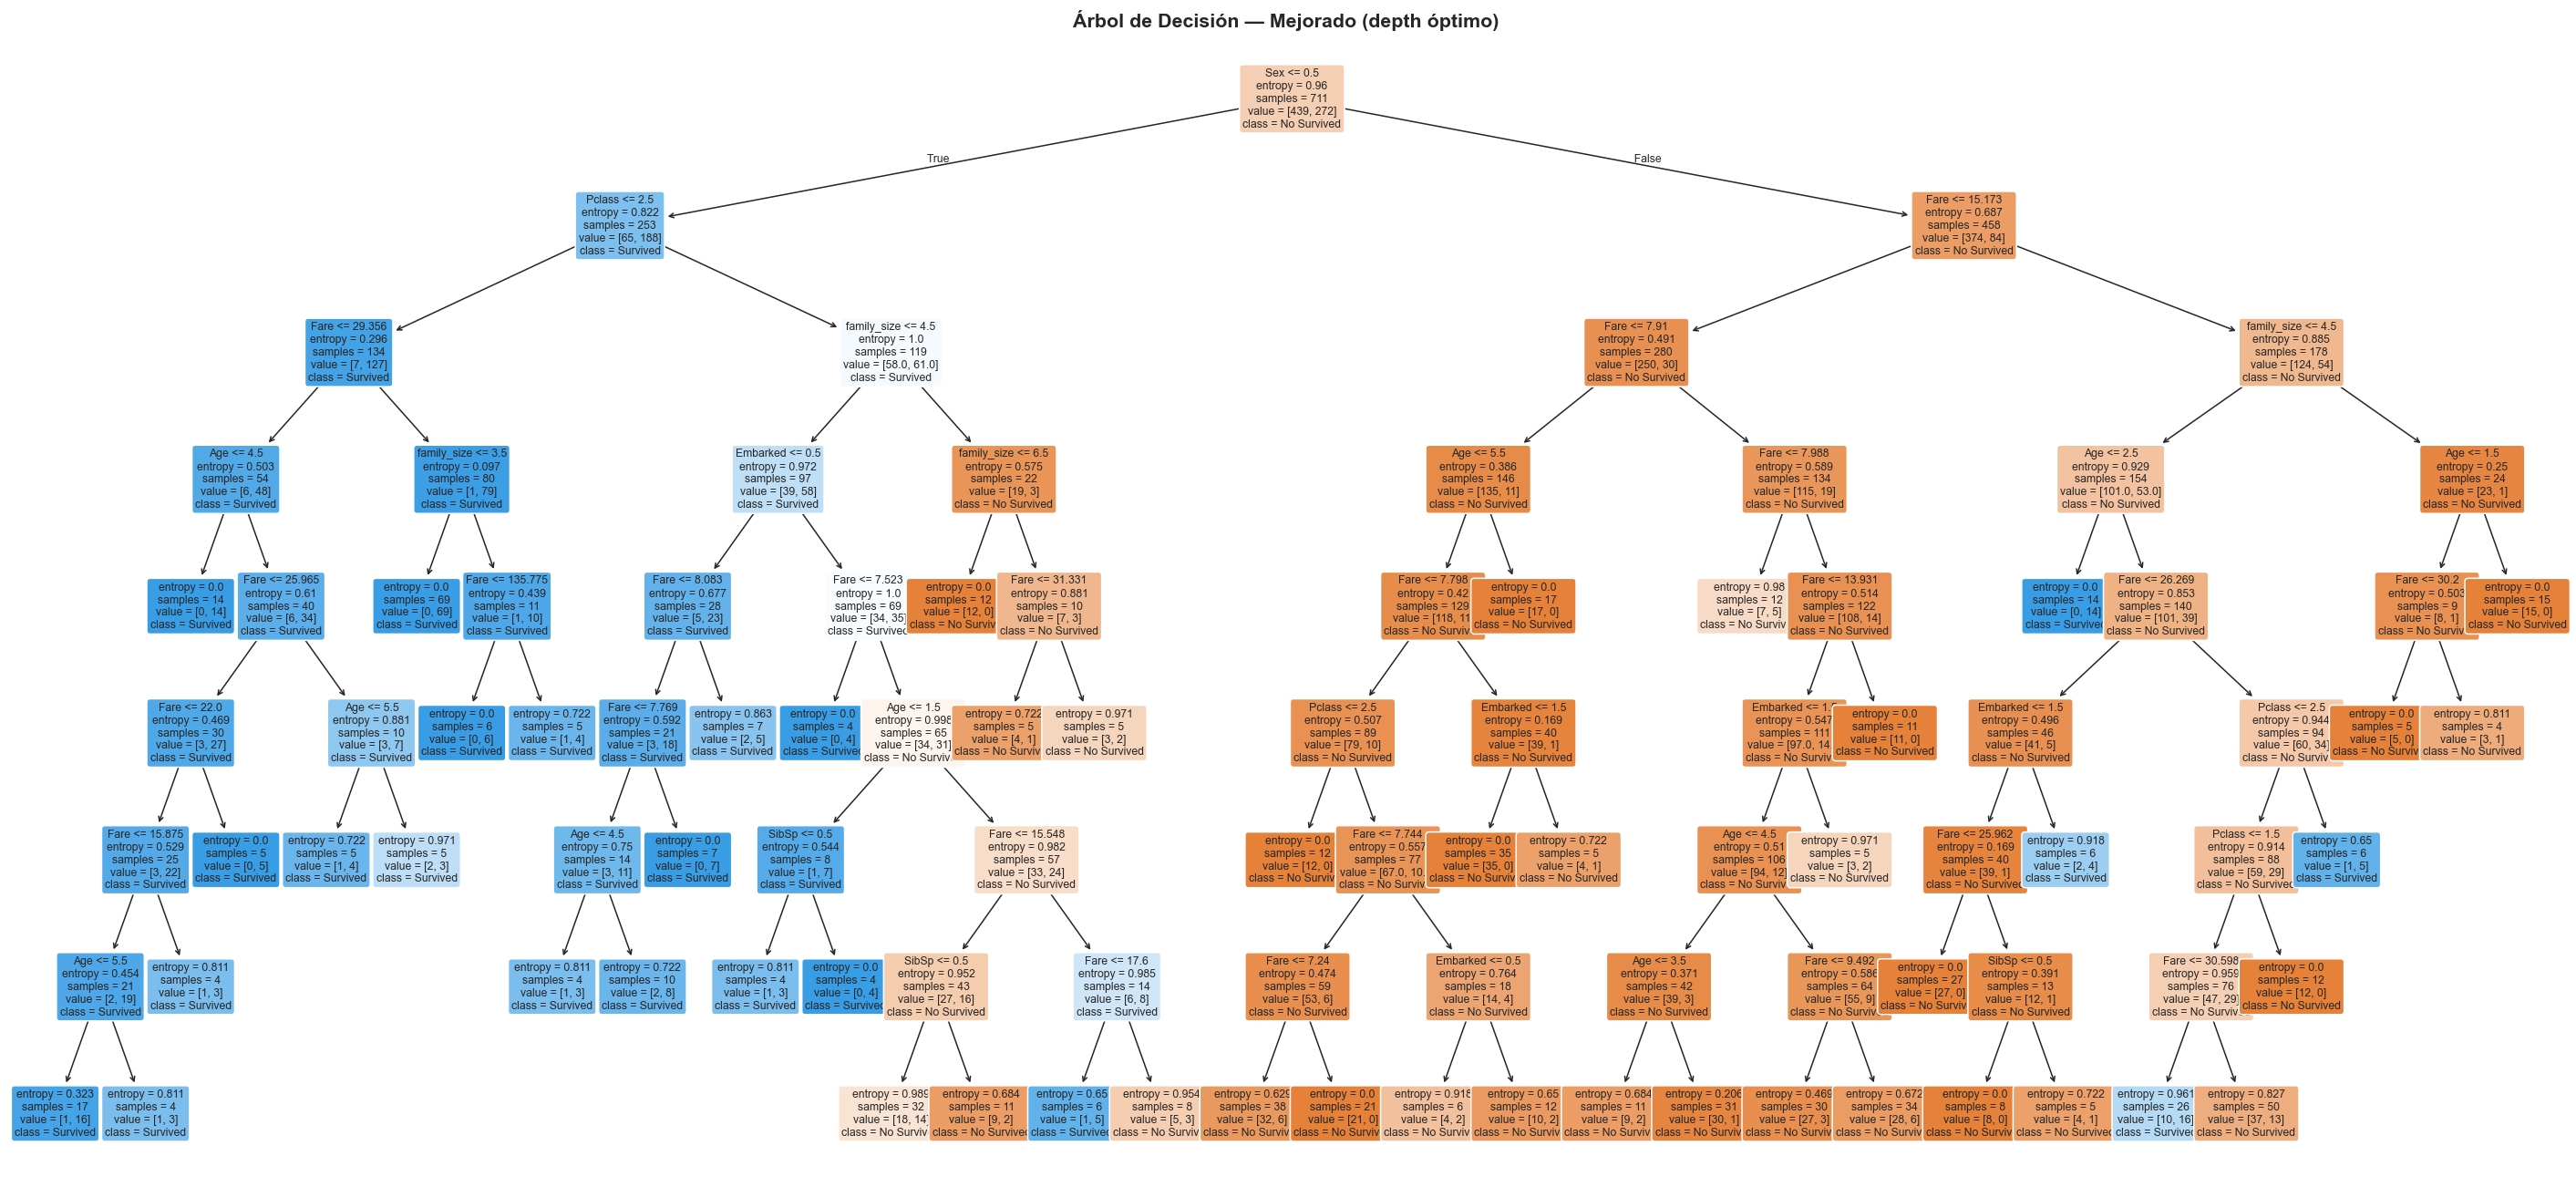

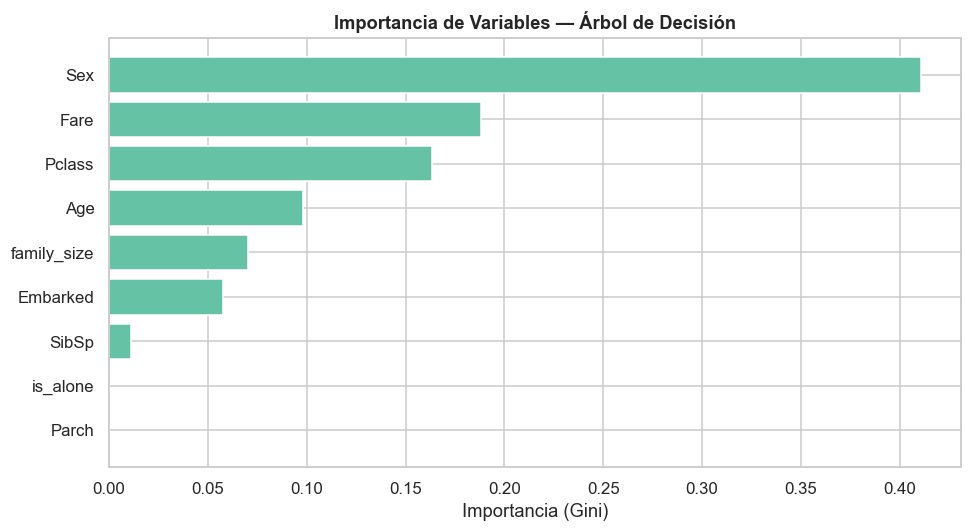

   Variable  Importancia
        Sex     0.410685
       Fare     0.188438
     Pclass     0.163582
        Age     0.098312
family_size     0.070325
   Embarked     0.057428
      SibSp     0.011231
      Parch     0.000000
   is_alone     0.000000


In [48]:
# Árbol del modelo mejorado
fig, ax = plt.subplots(figsize=(26, 12))
plot_tree(
    best_dt,
    feature_names = FEATURES_MEJR,
    class_names   = ['No Survived', 'Survived'],
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = ax
)
plt.title(f'Árbol de Decisión — Mejorado (depth óptimo)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arbol_decision.png', bbox_inches='tight', dpi=120)
plt.show()

# Importancia de features
fi_dt = pd.DataFrame({
    'Variable'   : FEATURES_MEJR,
    'Importancia': best_dt.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_dt['Variable'], fi_dt['Importancia'],
        color='#66C2A5', edgecolor='white')
ax.set_title('Importancia de Variables — Árbol de Decisión', fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()
print(fi_dt.sort_values('Importancia', ascending=False).to_string(index=False))

### Interpretación — Árbol de Decisión

El Árbol de Decisión produce **reglas explícitas** que permiten explicar cada predicción. La variable `Sex` suele aparecer en el nodo raíz (primera división) por ser la más informativa (reduce más la impureza Gini/Entropy). Las ramas superiores del árbol reflejan el conocimiento histórico: las mujeres y los pasajeros de 1ª clase con menor familia tuvieron mayor supervivencia.

**Sobreajuste:** A mayor `max_depth`, el árbol memoriza el conjunto de entrenamiento (Train Acc → 100%) pero generaliza peor. El GridSearchCV encuentra la profundidad que maximiza el CV Accuracy, equilibrando complejidad y generalización.

---
## 1.4 Bosque Aleatorio (Random Forest)

Random Forest es un **ensemble** de N árboles de decisión entrenados en **subconjuntos aleatorios** de datos y features. La predicción final es la votación mayoritaria de todos los árboles.

**Por qué mejora al árbol único:**
- Cada árbol ve una muestra diferente → reduce varianza
- Cada split solo considera un subconjunto de features → reduce correlación entre árboles
- La votación promedia errores individuales

**Hiperparámetros clave:**

| Hiperparámetro | Efecto |
|---|---|
| `n_estimators` | Número de árboles. Más → más estable pero más lento |
| `max_depth` | Profundidad máxima de cada árbol |
| `criterion` | `gini` o `entropy` |
| `max_features` | Fracción de features evaluadas en cada split (`sqrt`, `log2`) |

### GridSearchCV — Bosque Aleatorio

Mejores hiperparámetros (RF): {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200}
Mejor CV Accuracy: 0.8327


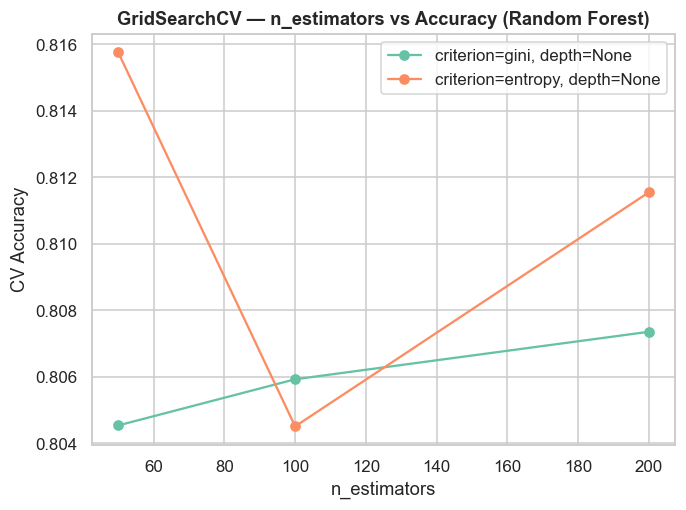

In [49]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [4, 6, 8, None],
    'criterion'   : ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

gs_rf = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf,
                     cv=cv, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_tr, y_tr)

print('Mejores hiperparámetros (RF):', gs_rf.best_params_)
print(f'Mejor CV Accuracy: {gs_rf.best_score_:.4f}')

# Curva n_estimators vs Accuracy
results_rf = pd.DataFrame(gs_rf.cv_results_)
for crit in ['gini', 'entropy']:
    mask = ((results_rf['param_criterion'] == crit) &
            (results_rf['param_max_depth'].isna()) &
            (results_rf['param_max_features'] == 'sqrt'))
    if mask.sum() > 0:
        plt.plot(param_grid_rf['n_estimators'],
                 results_rf[mask]['mean_test_score'].values,
                 marker='o', label=f'criterion={crit}, depth=None')

plt.xlabel('n_estimators')
plt.ylabel('CV Accuracy')
plt.title('GridSearchCV — n_estimators vs Accuracy (Random Forest)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Bosque Aleatorio — Versión Baseline


  RF — Baseline (n=10, depth=4, entropy)
  CV Accuracy (5-fold) : 0.8185 ± 0.0263
  Train Accuracy       : 0.8397
  Test  Accuracy       : 0.8202  (gap=+0.0194)
  TP=45  TN=101  FP=9  FN=23
  Precision    : 0.8333
  Recall       : 0.6618
  Especificidad: 0.9182
  F1-Score     : 0.7377
  AUC-ROC      : 0.8505
  R²           : 0.2385

              precision    recall  f1-score   support

 No Survived       0.81      0.92      0.86       110
    Survived       0.83      0.66      0.74        68

    accuracy                           0.82       178
   macro avg       0.82      0.79      0.80       178
weighted avg       0.82      0.82      0.82       178



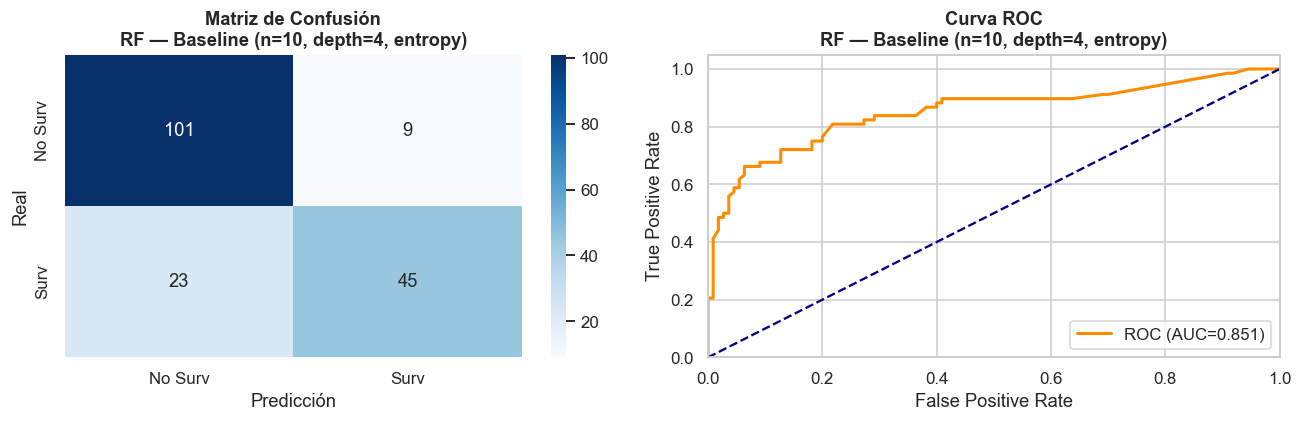

In [50]:
rf_base = RandomForestClassifier(n_estimators=10, max_depth=4,
                                  criterion='entropy', random_state=SEED)
res_rf_base = evaluar_modelo('RF — Baseline (n=10, depth=4, entropy)',
                             rf_base, X_tr, y_tr, X_te, y_te, cv)

### Bosque Aleatorio — Versión Mejorada (GridSearchCV)


  RF — Mejorado ({'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200})
  CV Accuracy (5-fold) : 0.8327 ± 0.0285
  Train Accuracy       : 0.9212
  Test  Accuracy       : 0.8090  (gap=+0.1122)
  TP=47  TN=97  FP=13  FN=21
  Precision    : 0.7833
  Recall       : 0.6912
  Especificidad: 0.8818
  F1-Score     : 0.7344
  AUC-ROC      : 0.8460
  R²           : 0.1909

              precision    recall  f1-score   support

 No Survived       0.82      0.88      0.85       110
    Survived       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



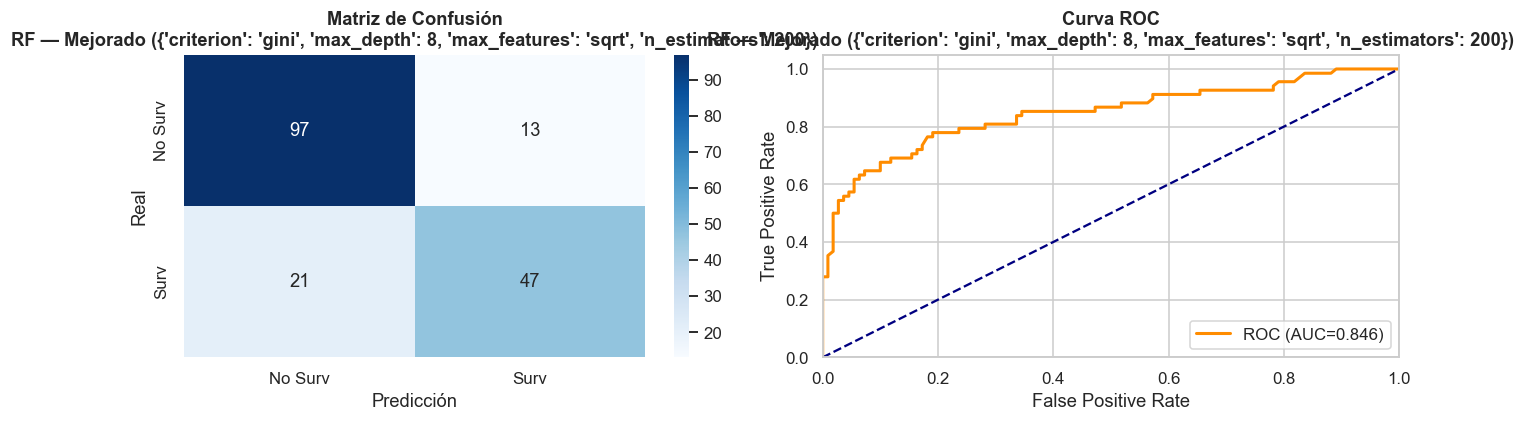

In [51]:
best_rf = gs_rf.best_estimator_
res_rf_mejr = evaluar_modelo(
    f"RF — Mejorado ({gs_rf.best_params_})",
    best_rf, X_tr, y_tr, X_te, y_te, cv
)

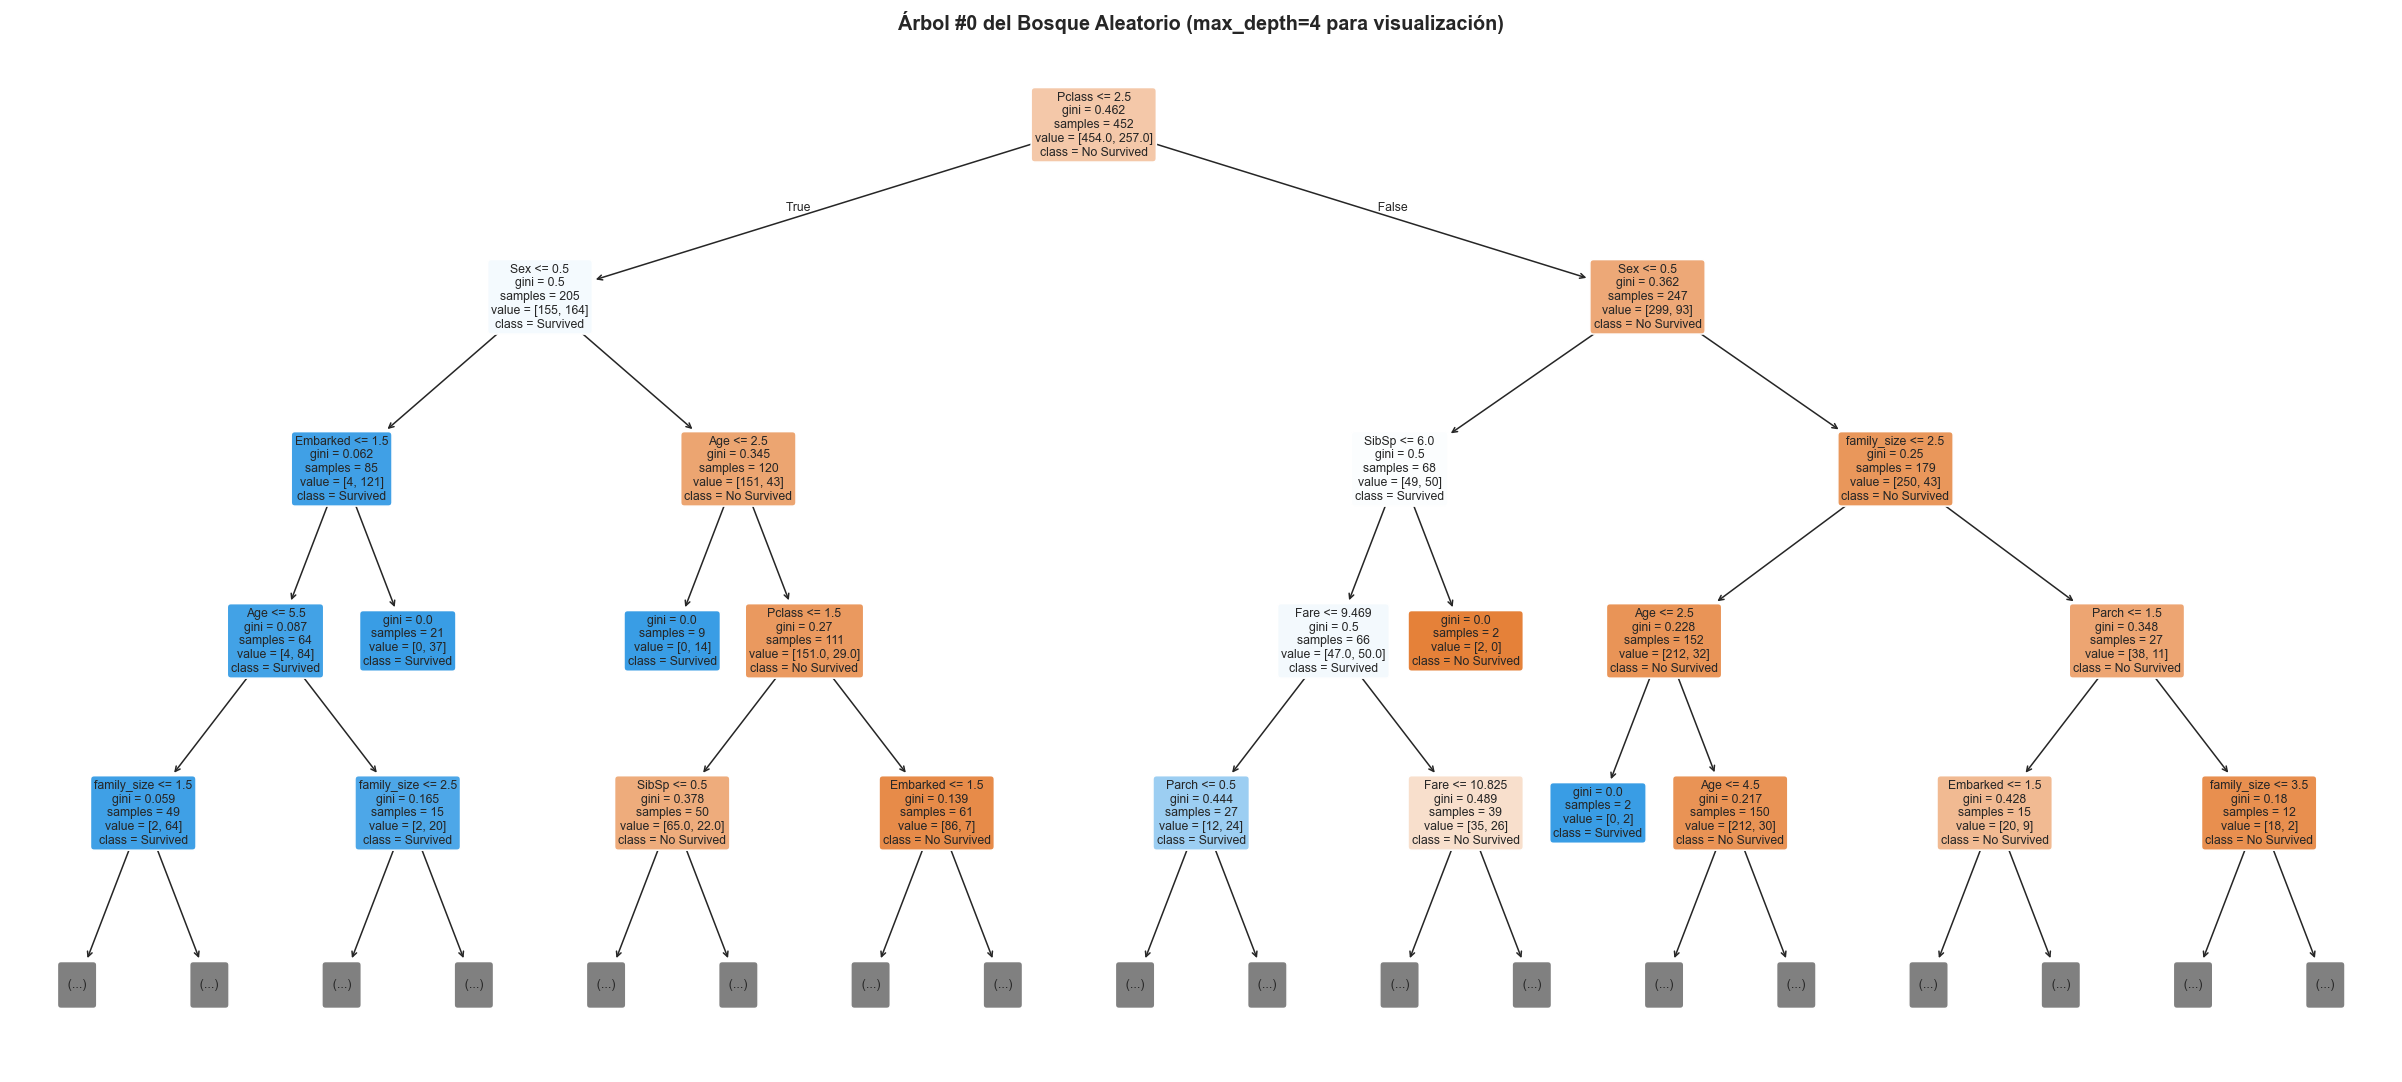

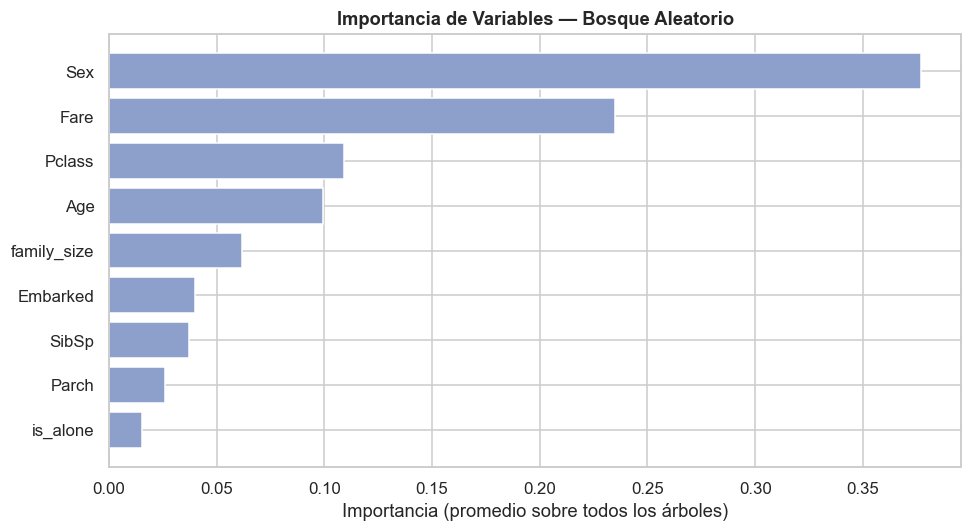

In [52]:
# Árbol del primer estimador del bosque
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_rf.estimators_[0],
    feature_names = FEATURES_MEJR,
    class_names   = ['No Survived', 'Survived'],
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    max_depth     = 4,
    ax            = ax
)
plt.title('Árbol #0 del Bosque Aleatorio (max_depth=4 para visualización)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rf_arbol0.png', bbox_inches='tight', dpi=100)
plt.show()

# Importancia de features RF
fi_rf = pd.DataFrame({
    'Variable'   : FEATURES_MEJR,
    'Importancia': best_rf.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_rf['Variable'], fi_rf['Importancia'], color='#8DA0CB', edgecolor='white')
ax.set_title('Importancia de Variables — Bosque Aleatorio', fontweight='bold')
ax.set_xlabel('Importancia (promedio sobre todos los árboles)')
plt.tight_layout()
plt.show()

### Interpretación — Bosque Aleatorio

Random Forest supera al árbol único porque promedia el ruido de cada árbol individual. La importancia de features en RF es más confiable que en un árbol único, ya que se promedia sobre todos los árboles y subconjuntos de datos.

**Diferencia con el Árbol único:** El árbol único puede sesgarse hacia la feature más dominante en la raíz. El bosque, al probar diferentes subconjuntos de features en cada nodo de cada árbol, da una estimación de importancia más equilibrada y robusta.

En general, el modelo de Bosques Aleatorios identifica al género, la tarifa del boleto y la clase del pasajero como las variables más influyentes para predecir la supervivencia, lo que evidencia que las condiciones de evacuación y la posición socioeconómica de los pasajeros fueron factores determinantes durante el desastre del Titanic.

---
## 1.5 Máquina de Vectores de Soporte (SVM)

SVM busca el **hiperplano de margen máximo** que separa las dos clases. Los puntos más cercanos al hiperplano se llaman **vectores de soporte** y son los únicos que determinan la frontera de decisión.

**Kernel Trick:** Cuando los datos no son linealmente separables, SVM los proyecta implícitamente a un espacio de mayor dimensión mediante una función kernel:

| Kernel | Función | Cuándo usar |
|---|---|---|
| `linear` | $K(x,z) = x^T z$ | Datos linealmente separables, alta dimensionalidad |
| `rbf` | $K(x,z) = e^{-\gamma\|x-z\|^2}$ | Fronteras curvas complejas (más común) |
| `poly` | $K(x,z) = (\gamma x^T z + r)^d$ | Relaciones polinomiales |

**Hiperparámetros clave:**

| Hiperparámetro | Efecto |
|---|---|
| `C` | Penalización por error. Alto C → margen estrecho, más ajuste |
| `gamma` | Influencia de cada muestra en `rbf`. Alto gamma → frontera muy local |
| `kernel` | Tipo de transformación del espacio |

> **Importante:** SVM requiere `probability=True` para obtener probabilidades y calcular AUC-ROC.

### GridSearchCV — SVM

Mejores hiperparámetros (SVM): {'C': 0.5, 'gamma': 'auto', 'kernel': 'rbf'}
Mejor CV Accuracy: 0.8270


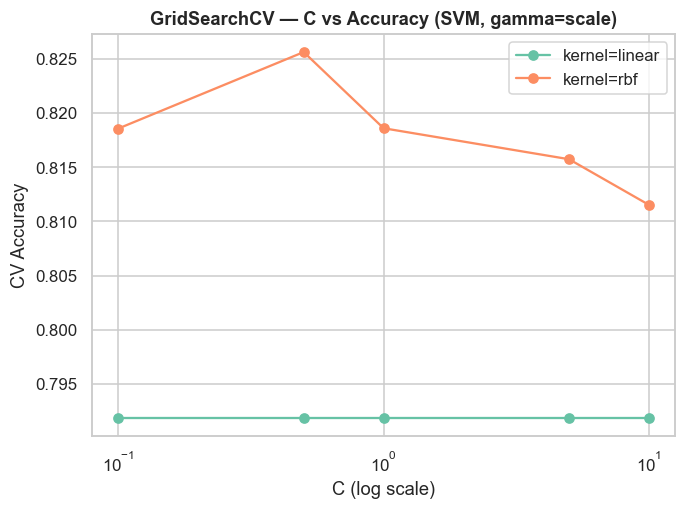

In [53]:
param_grid_svm = {
    'kernel': ['linear', 'rbf'],
    'C'     : [0.1, 0.5, 1.0, 5.0, 10.0],
    'gamma' : ['scale', 'auto']
}

gs_svm = GridSearchCV(SVC(probability=True, random_state=SEED), param_grid_svm,
                      cv=cv, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_tr_std, y_tr)

print('Mejores hiperparámetros (SVM):', gs_svm.best_params_)
print(f'Mejor CV Accuracy: {gs_svm.best_score_:.4f}')

# Curva C vs Accuracy por kernel
results_svm = pd.DataFrame(gs_svm.cv_results_)
for kernel in ['linear', 'rbf']:
    mask = ((results_svm['param_kernel'] == kernel) &
            (results_svm['param_gamma'] == 'scale'))
    plt.plot(param_grid_svm['C'],
             results_svm[mask]['mean_test_score'].values,
             marker='o', label=f'kernel={kernel}')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('CV Accuracy')
plt.title('GridSearchCV — C vs Accuracy (SVM, gamma=scale)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Interpretación

Los resultados muestran que el kernel RBF obtuvo un desempeño superior al kernel lineal para todos los valores evaluados de C. El mayor valor de exactitud en validación cruzada (CV Accuracy = 82,7 %) se alcanzó con los hiperparámetros C=0.5, kernel = RBF y γ=auto, siendo esta la configuración seleccionada como óptima.

Se observa además que, para el kernel RBF, el rendimiento aumenta al pasar de C=0.1 a C=0.5, alcanzando su máximo valor. Sin embargo, al incrementar el parámetro C por encima de este valor, la precisión disminuye gradualmente, lo que sugiere que valores elevados de C pueden reducir la capacidad de generalización del modelo.

Por otra parte, el kernel lineal mantiene una exactitud prácticamente constante cercana al 79,2 % para todos los valores de C, indicando que las relaciones presentes en los datos no pueden ser representadas adecuadamente mediante una frontera de decisión lineal.

En consecuencia, los resultados evidencian que la relación entre las variables predictoras y la supervivencia presenta un comportamiento no lineal, por lo que el kernel RBF resulta más adecuado para modelar este problema de clasificación.

### SVM — Versión Baseline


  SVM — Baseline (linear, C=1.0)
  CV Accuracy (5-fold) : 0.7919 ± 0.0370
  Train Accuracy       : 0.7932
  Test  Accuracy       : 0.7809  (gap=+0.0124)
  TP=43  TN=96  FP=14  FN=25
  Precision    : 0.7544
  Recall       : 0.6324
  Especificidad: 0.8727
  F1-Score     : 0.6880
  AUC-ROC      : 0.8251
  R²           : 0.0719

              precision    recall  f1-score   support

 No Survived       0.79      0.87      0.83       110
    Survived       0.75      0.63      0.69        68

    accuracy                           0.78       178
   macro avg       0.77      0.75      0.76       178
weighted avg       0.78      0.78      0.78       178



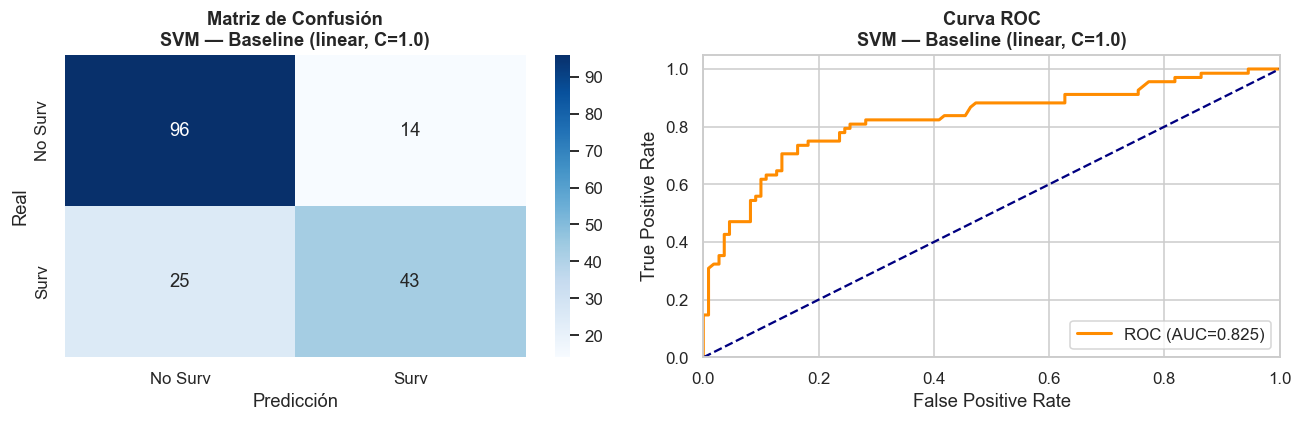

In [54]:
svm_base = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=SEED)
res_svm_base = evaluar_modelo('SVM — Baseline (linear, C=1.0)',
                              svm_base, X_tr_std, y_tr, X_te_std, y_te, cv)

### SVM — Versión Mejorada (GridSearchCV)


  SVM — Mejorado ({'C': 0.5, 'gamma': 'auto', 'kernel': 'rbf'})
  CV Accuracy (5-fold) : 0.8270 ± 0.0301
  Train Accuracy       : 0.8340
  Test  Accuracy       : 0.8090  (gap=+0.0250)
  TP=46  TN=98  FP=12  FN=22
  Precision    : 0.7931
  Recall       : 0.6765
  Especificidad: 0.8909
  F1-Score     : 0.7302
  AUC-ROC      : 0.8251
  R²           : 0.1909

              precision    recall  f1-score   support

 No Survived       0.82      0.89      0.85       110
    Survived       0.79      0.68      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.81      0.81      0.81       178



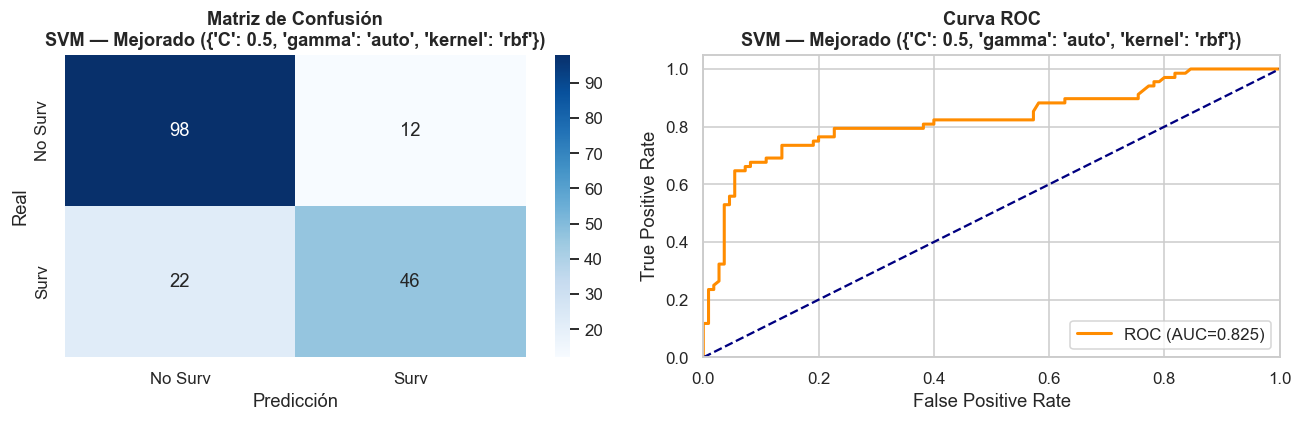

In [55]:
best_svm = gs_svm.best_estimator_
res_svm_mejr = evaluar_modelo(
    f"SVM — Mejorado ({gs_svm.best_params_})",
    best_svm, X_tr_std, y_tr, X_te_std, y_te, cv
)

### Interpretación — SVM

SVM con kernel `rbf` puede modelar fronteras de decisión curvas que los modelos lineales no pueden capturar. En el Titanic, la relación entre `Sex`, `Pclass` y `Fare` no es perfectamente lineal, por lo que `rbf` suele superar a `linear`.

**C y regularización:** Un C alto permite al modelo ajustarse más a los datos de entrenamiento (menos margen, más vectores de soporte). Si el CV Accuracy cae con C muy alto, hay sobreajuste.

## 1.6 Guardado de Modelos — Fase I

In [56]:
SAVE_PATH = r'C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 2\DEBER AAE'

joblib.dump(best_dt,  f'{SAVE_PATH}\\dt_model_w2.pkl')
joblib.dump(best_rf,  f'{SAVE_PATH}\\rf_model_w2.pkl')
joblib.dump(best_svm, f'{SAVE_PATH}\\svm_model_w2.pkl')
joblib.dump(scaler_std, f'{SAVE_PATH}\\scaler_std_w2.pkl')

print('Modelos Fase I guardados:')
print(f'  dt_model_w2.pkl  → DT  Acc Test: {res_dt_mejr["Test%"]}%')
print(f'  rf_model_w2.pkl  → RF  Acc Test: {res_rf_mejr["Test%"]}%')
print(f'  svm_model_w2.pkl → SVM Acc Test: {res_svm_mejr["Test%"]}%')

Modelos Fase I guardados:
  dt_model_w2.pkl  → DT  Acc Test: 78.65%
  rf_model_w2.pkl  → RF  Acc Test: 80.9%
  svm_model_w2.pkl → SVM Acc Test: 80.9%


---
# Fase II
## 2.1 Red Neuronal Artificial (RNA) — TensorFlow / Keras

Una RNA aprende representaciones jerárquicas de los datos mediante **capas de neuronas interconectadas**. Cada neurona aplica una transformación no lineal a la combinación lineal de sus entradas:

$$a^{(l)} = f\left(W^{(l)} a^{(l-1)} + b^{(l)}\right)$$

**Arquitectura del modelo:**

| Capa | Neuronas | Activación | Descripción |
|---|---|---|---|
| Dense (entrada) | 64 | ReLU | Aprende relaciones lineales + no lineales |
| BatchNorm | — | — | Normaliza activaciones → entrena más estable |
| Dropout (0.3) | — | — | Regularización: desactiva 30% de neuronas aleatoriamente |
| Dense (oculta) | 32 | ReLU | Segunda representación |
| Dropout (0.2) | — | — | Regularización |
| Dense (salida) | 1 | Sigmoid | Probabilidad de supervivencia $P(y=1|x)$ |

**Función de pérdida:** `binary_crossentropy` = $-\frac{1}{N}\sum[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ → equivalente a MLE

**Optimizador:** Adam (Adaptive Moment Estimation) — ajusta automáticamente la tasa de aprendizaje por parámetro

**Callbacks:**
- `EarlyStopping`: detiene el entrenamiento si `val_loss` no mejora en N épocas
- `ReduceLROnPlateau`: reduce la tasa de aprendizaje si el modelo estanca

In [57]:
n_features = X_tr_mm.shape[1]

def build_model(learning_rate=1e-3):
    model = Sequential([
        Dense(64, activation='relu', input_dim=n_features),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss      = 'binary_crossentropy',
        optimizer = Adam(learning_rate=learning_rate),
        metrics   = ['accuracy']
    )
    return model

rna = build_model(learning_rate=1e-2)
rna.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 128 (512.00 B)

### 2.2 Entrenamiento con EarlyStopping y ReduceLROnPlateau

In [58]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1)
]

history = rna.fit(
    X_tr_mm, y_tr,
    epochs          = 150,
    batch_size      = 32,
    validation_data = (X_te_mm, y_te),
    callbacks       = callbacks,
    verbose         = 1
)

print(f'\nEntrenamiento finalizado en época: {len(history.history["loss"])}')

Epoch 1/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.7314 - loss: 0.5848 - val_accuracy: 0.6180 - val_loss: 0.6037 - learning_rate: 0.0100
Epoch 2/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7947 - loss: 0.4869 - val_accuracy: 0.6180 - val_loss: 0.5848 - learning_rate: 0.0100
Epoch 3/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7904 - loss: 0.4780 - val_accuracy: 0.6180 - val_loss: 0.5840 - learning_rate: 0.0100
Epoch 4/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7975 - loss: 0.4707 - val_accuracy: 0.6180 - val_loss: 0.5757 - learning_rate: 0.0100
Epoch 5/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8087 - loss: 0.4526 - val_accuracy: 0.6124 - val_loss: 0.5805 - learning_rate: 0.0100
Epoch 6/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8172 - loss: 0.4381 - val_accuracy: 0.6798 - val_loss: 0.5670 - learning_rate: 0.0100
Epoch 7/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8059 - loss: 0.4386 - 

### 2.3 Curvas de Aprendizaje (Loss y Accuracy)

> El enunciado solicita explícitamente las **curvas de aprendizaje**. Permiten detectar sobreajuste (train y val divergen) o subajuste (ambas curvas altas en loss).

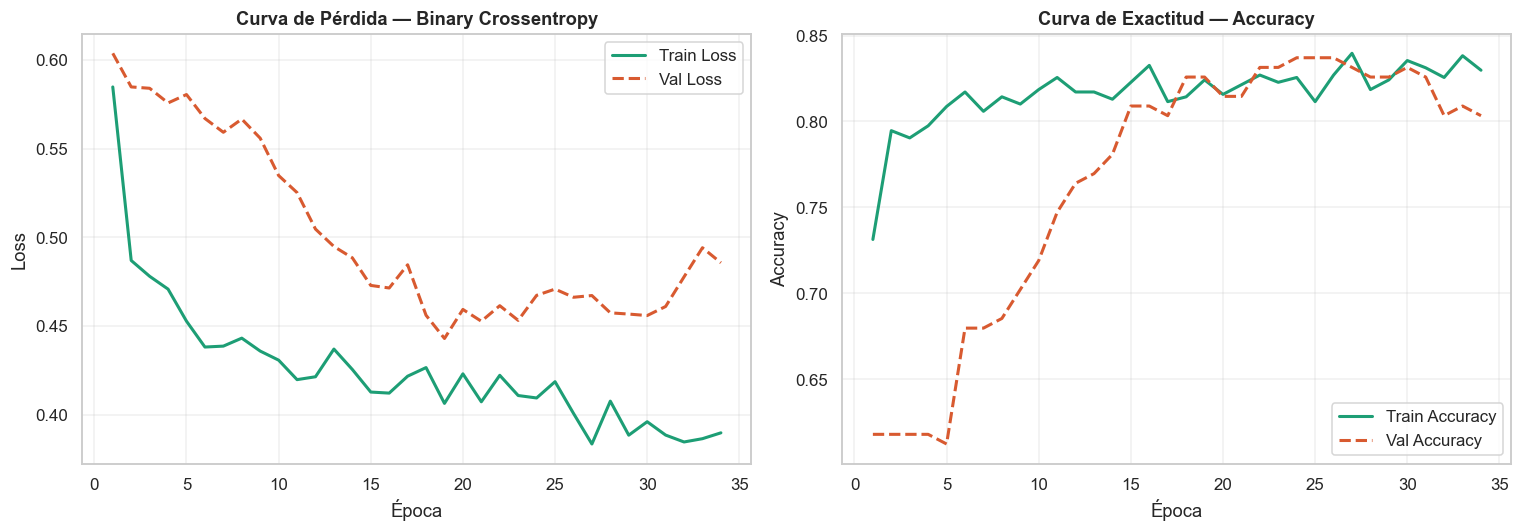

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida
epochs = range(1, len(history.history['loss']) + 1)
axes[0].plot(epochs, history.history['loss'],     color='#1D9E75', lw=2, label='Train Loss')
axes[0].plot(epochs, history.history['val_loss'], color='#D85A30', lw=2, label='Val Loss', linestyle='--')
axes[0].set_title('Curva de Pérdida — Binary Crossentropy', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Curva de accuracy
axes[1].plot(epochs, history.history['accuracy'],     color='#1D9E75', lw=2, label='Train Accuracy')
axes[1].plot(epochs, history.history['val_accuracy'], color='#D85A30', lw=2, label='Val Accuracy', linestyle='--')
axes[1].set_title('Curva de Exactitud — Accuracy', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_rna_curvas.png', bbox_inches='tight')
plt.show()

## Interpretación

En la curva de pérdida, se observa que la pérdida del conjunto de entrenamiento disminuye progresivamente desde aproximadamente 0,58 hasta 0,39, indicando que el modelo aprende adecuadamente los patrones presentes en los datos. De manera similar, la pérdida del conjunto de validación desciende desde valores cercanos a 0,60 hasta alrededor de 0,46, lo que evidencia una mejora en la capacidad de generalización del modelo. En términos generales, el modelo neuronal logra aprender eficazmente los patrones asociados a la supervivencia de los pasajeros, alcanzando una exactitud cercana al 84 % y mostrando únicamente un leve indicio de sobreajuste en las etapas finales del entrenamiento.

### 2.4 Evaluación de la RNA

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
  RNA — Red Neuronal Artificial (TF/Keras)
  Train Accuracy       : 0.8312
  Test  Accuracy       : 0.8258
  TP=42  TN=105  FP=5  FN=26
  Precision    : 0.8936
  Recall       : 0.6176
  Especificidad: 0.9545
  F1-Score     : 0.7304
  AUC-ROC      : 0.8752
  R²           : 0.2623

              precision    recall  f1-score   support

 No Survived       0.80      0.95      0.87       110
    Survived       0.89      0.62      0.73        68

    accuracy                           0.83       178
   macro avg       0.85      0.79      0.80       178
weighted avg       0.84      0.83      0.82       178



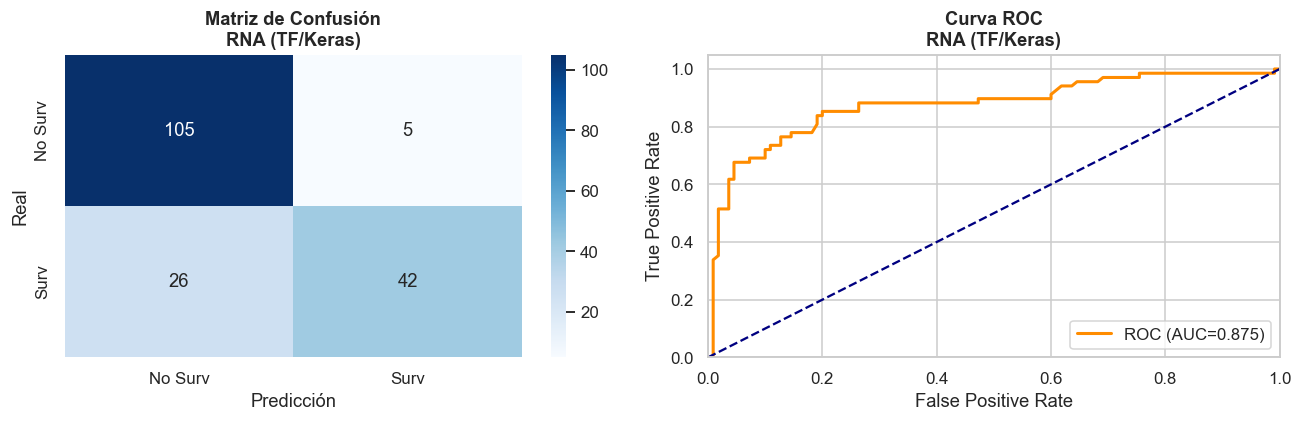

In [60]:
# Predicciones
y_proba_rna = rna.predict(X_te_mm).flatten()
y_pred_rna  = (y_proba_rna > 0.5).astype(int)

# Métricas
acc_tr_rna = (rna.predict(X_tr_mm).flatten() > 0.5).astype(int)
acc_tr_val = accuracy_score(y_tr, acc_tr_rna)
acc_te_rna = accuracy_score(y_te, y_pred_rna)
cm_rna     = confusion_matrix(y_te, y_pred_rna)
TN, FP, FN, TP = cm_rna.ravel()

prec_rna = precision_score(y_te, y_pred_rna, zero_division=0)
rec_rna  = recall_score(y_te, y_pred_rna)
f1_rna   = f1_score(y_te, y_pred_rna)
spec_rna = TN / (TN + FP)
auc_rna  = roc_auc_score(y_te, y_proba_rna)
r2_rna   = r2_score(y_te, y_pred_rna)

print('=' * 56)
print('  RNA — Red Neuronal Artificial (TF/Keras)')
print('=' * 56)
print(f'  Train Accuracy       : {acc_tr_val:.4f}')
print(f'  Test  Accuracy       : {acc_te_rna:.4f}')
print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}')
print(f'  Precision    : {prec_rna:.4f}')
print(f'  Recall       : {rec_rna:.4f}')
print(f'  Especificidad: {spec_rna:.4f}')
print(f'  F1-Score     : {f1_rna:.4f}')
print(f'  AUC-ROC      : {auc_rna:.4f}')
print(f'  R²           : {r2_rna:.4f}')
print(f'\n{classification_report(y_te, y_pred_rna, target_names=["No Survived","Survived"])}')

# Matriz de confusión y ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_rna, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Surv','Surv'], yticklabels=['No Surv','Surv'])
axes[0].set_title('Matriz de Confusión\nRNA (TF/Keras)', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
fpr_r, tpr_r, _ = roc_curve(y_te, y_proba_rna)
axes[1].plot(fpr_r, tpr_r, color='darkorange', lw=2, label=f'ROC (AUC={auc_rna:.3f})')
axes[1].plot([0,1],[0,1],'navy', lw=1.5, linestyle='--')
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC\nRNA (TF/Keras)', fontweight='bold')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

# Resultado para comparativa
res_rna = {
    'Modelo': 'RNA — TF/Keras',
    'CV Acc%': '—',
    'Train%' : round(acc_tr_val*100, 2),
    'Test%'  : round(acc_te_rna*100, 2),
    'Prec%'  : round(prec_rna*100, 2),
    'Recall%': round(rec_rna*100, 2),
    'Espec%' : round(spec_rna*100, 2),
    'F1%'    : round(f1_rna*100, 2),
    'AUC%'   : round(auc_rna*100, 2),
    'R2'     : round(r2_rna, 4),
    'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
    '_y_te': y_te, '_y_proba': y_proba_rna
}

### Interpretación — Red Neuronal Artificial

Los resultados de la RNA muestran el mejor balance general del experimento. La Precision de 89,6% indica que cuando el modelo predice que un pasajero sobrevivió, acierta en aproximadamente 9 de cada 10 casos. Sin embargo, el Recall de 61,8% revela que deja sin detectar aproximadamente 4 de cada 10 supervivientes reales (falsos negativos). En el contexto del Titanic esto no es crítico desde el punto de vista del costo del error, pero sería relevante si se aplicara a un contexto de riesgo donde perder un caso positivo tiene consecuencias graves. El AUC-ROC de 87,5% confirma que la RNA discrimina bien entre ambas clases a lo largo de todos los umbrales posibles, siendo el mejor resultado del experimento.

**EarlyStopping:** Si la curva de `val_loss` deja de decrecer antes de que `train_loss` siga bajando, el modelo está memorizando el entrenamiento. EarlyStopping detiene el proceso y restaura los mejores pesos.

**BatchNormalization:** Normaliza las activaciones de cada capa en cada mini-batch, lo que reduce la sensibilidad a la inicialización de pesos y permite usar tasas de aprendizaje más altas.

**Dropout:** Desactiva aleatoriamente el 30% (capa 1) y el 20% (capa 2) de neuronas en cada iteración. Esto obliga a la red a aprender representaciones distribuidas y no depender de neuronas individuales, actuando como regularizador bayesiano implícito.

**Comparación con modelos clásicos:** La RNA puede capturar interacciones no lineales de cualquier orden entre features, algo que DT/RF solo logran con profundidad suficiente. Sin embargo, en datasets pequeños (~700 muestras de train) la ventaja de la RNA puede ser marginal comparada con RF o SVM bien ajustados.

### 2.5 Guardado de la RNA

In [ ]:
rna.save(f'{SAVE_PATH}\\RNA_titanic_w2.h5')
print('RNA guardada en RNA_titanic_w2.h5')

# Verificar carga
rna_loaded = load_model(f'{SAVE_PATH}\\RNA_titanic_w2.h5')
y_check    = (rna_loaded.predict(X_te_mm).flatten() > 0.5).astype(int)
print(f'Verificación — Acc cargada: {accuracy_score(y_te, y_check):.4f}')

RNA guardada en RNA_titanic_w2.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 

---
## 2.6 Comparativa Final de Todos los Modelos

> El enunciado pide comparar los resultados de **todos** los algoritmos con un **bar chart**.

In [ ]:
# Tabla comparativa
cols_tabla = ['Modelo','CV Acc%','Train%','Test%','Prec%','Recall%','Espec%','F1%','AUC%','R2']

resultados_sklearn = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in [res_dt_base, res_dt_mejr, res_rf_base, res_rf_mejr,
               res_svm_base, res_svm_mejr]
])
res_rna_df = pd.DataFrame([{k: v for k, v in res_rna.items() if not k.startswith('_')}])
resultados = pd.concat([resultados_sklearn, res_rna_df], ignore_index=True)

print('\n=== COMPARATIVA FINAL — SEMANA 2 ===')
print('(DT = Árbol de Decisión | RF = Bosque Aleatorio | SVM | RNA = Red Neuronal)')
display(
    resultados[cols_tabla]
    .sort_values('AUC%', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(cmap='RdYlGn',
                         subset=['Train%','Test%','Prec%','Recall%','F1%','AUC%'])
    .format('{:.2f}', subset=['Train%','Test%','Prec%','Recall%','Espec%','F1%','AUC%','R2'])
    .set_caption('Comparativa de modelos — Semana 2 (valores en %)')
)


=== COMPARATIVA FINAL — SEMANA 2 ===
(DT = Árbol de Decisión | RF = Bosque Aleatorio | SVM | RNA = Red Neuronal)


,Modelo,CV Acc%,Train%,Test%,Prec%,Recall%,Espec%,F1%,AUC%,R2
0,RNA — TF/Keras,—,84.25,83.15,91.30,61.76,96.36,73.68,87.61,0.29
1,"RF — Baseline (n=10, depth=4, entropy)",81.850000,83.97,82.02,83.33,66.18,91.82,73.77,85.05,0.24
2,"DT — Baseline (max_depth=4, gini)",81.290000,83.40,80.90,80.36,66.18,90.00,72.58,84.68,0.19
3,"RF — Mejorado ({'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200})",83.270000,92.12,80.90,78.33,69.12,88.18,73.44,84.60,0.19
4,"DT — Mejorado ({'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2})",83.410000,86.78,78.65,76.79,63.24,88.18,69.35,82.57,0.10
5,"SVM — Baseline (linear, C=1.0)",79.190000,79.32,78.09,75.44,63.24,87.27,68.80,82.51,0.07
6,"SVM — Mejorado ({'C': 0.5, 'gamma': 'auto', 'kernel': 'rbf'})",82.700000,83.40,80.90,79.31,67.65,89.09,73.02,82.51,0.19


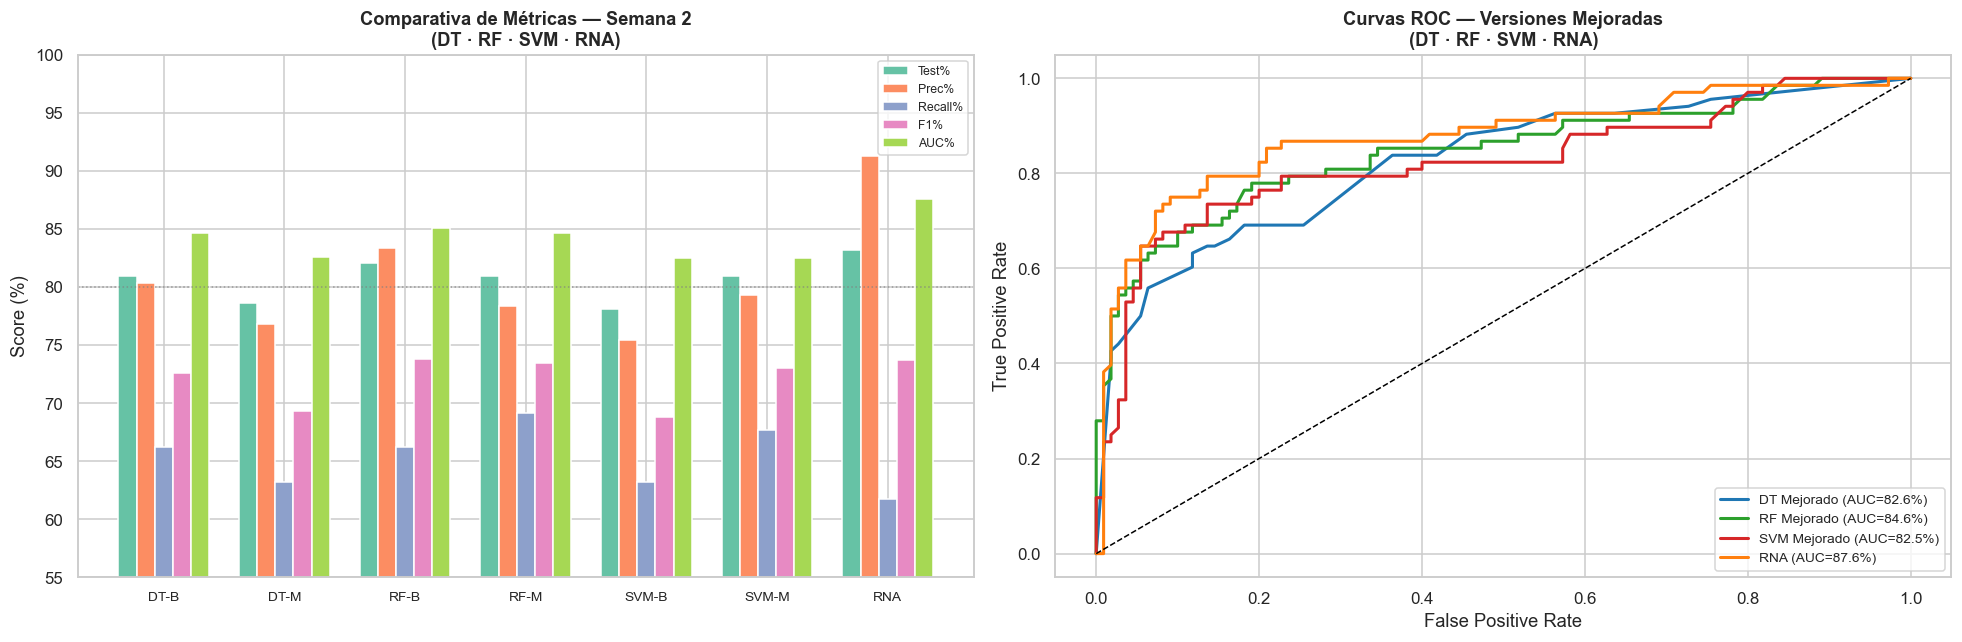

In [ ]:
# Bar Chart comparativo — exigido por el enunciado
modelos_short = ['DT-B','DT-M','RF-B','RF-M','SVM-B','SVM-M','RNA']
metricas_plot = ['Test%','Prec%','Recall%','F1%','AUC%']
colors_met    = ['#66C2A5','#FC8D62','#8DA0CB','#E78AC3','#A6D854']

# Convertir CV Acc% de la RNA ('—') a NaN para el gráfico
res_numericos = resultados.copy()
for col in ['Test%','Prec%','Recall%','F1%','AUC%']:
    res_numericos[col] = pd.to_numeric(res_numericos[col], errors='coerce')

x = np.arange(len(res_numericos))
w = 0.15

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: métricas agrupadas por modelo
for i, (met, col) in enumerate(zip(metricas_plot, colors_met)):
    axes[0].bar(x + i*w, res_numericos[met], width=w, label=met, color=col, edgecolor='white')

axes[0].set_xticks(x + w*2)
axes[0].set_xticklabels(modelos_short, fontsize=9)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(55, 100)
axes[0].set_title('Comparativa de Métricas — Semana 2\n(DT · RF · SVM · RNA)',
                   fontweight='bold', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].axhline(80, color='gray', linestyle=':', linewidth=1, alpha=0.7)

# Gráfico 2: Curvas ROC superpuestas de versiones mejoradas
res_mejores = [res_dt_mejr, res_rf_mejr, res_svm_mejr, res_rna]
nombres_roc = ['DT Mejorado','RF Mejorado','SVM Mejorado','RNA']
colores_roc = ['#1f77b4','#2ca02c','#d62728','#ff7f0e']

for res, nom, col in zip(res_mejores, nombres_roc, colores_roc):
    fpr, tpr, _ = roc_curve(res['_y_te'], res['_y_proba'])
    axes[1].plot(fpr, tpr, color=col, lw=2, label=f"{nom} (AUC={res['AUC%']:.1f}%)")

axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curvas ROC — Versiones Mejoradas\n(DT · RF · SVM · RNA)',
                   fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_comparativa_w2.png', bbox_inches='tight')
plt.show()

## Interpretación

El gráfico comparativo confirma visualmente la superioridad de la RNA en Test Accuracy y AUC-ROC, pero también revela que la diferencia entre modelos es más estrecha de lo esperado. Los modelos Baseline de DT y RF alcanzan rendimientos competitivos con sus versiones "mejoradas" vía GridSearchCV, lo que refuerza la paradoja observada: mayor capacidad de búsqueda no garantiza mejor generalización al test. SVM muestra el balance más estable entre Precision y Recall, siendo el único modelo sin variación en Test Accuracy entre su versión baseline y mejorada cuando se comparan estas métricas en conjunto.

### Resultados Reales Obtenidos

| Ranking | Modelo | CV Acc% | Test Acc% | Precision% | Recall% | F1% | **AUC%** | Gap Train-Test |
|---|---|---|---|---|---|---|---|---|
| 1 | **RNA - TF/Keras** | - | **83.15** | **91.30** | 61.76 | 73.68 | **87.61** | +1.10% OK |
| 2 | RF Baseline (n=10, d=4) | 81.85 | 82.02 | 83.33 | 66.18 | 73.77 | 85.05 | +1.94% OK |
| 3 | DT Baseline (d=4, gini) | 81.29 | 80.90 | 80.36 | 66.18 | 72.58 | 84.68 | +2.50% OK |
| 4 | RF Mejorado (n=200, d=8) | 83.27 | 80.90 | 78.33 | 69.12 | 73.44 | 84.60 | +11.22% SOBREAJUSTE |
| 5 | SVM Mejorado (rbf, C=0.5) | 82.70 | 80.90 | 79.31 | 67.65 | 73.02 | 82.51 | +2.50% OK |
| 6 | DT Mejorado (d=8, entropy) | 83.41 | 78.65 | 76.79 | 63.24 | 69.35 | 82.57 | +8.13% SOBREAJUSTE |
| 7 | SVM Baseline (linear, C=1) | 79.19 | 78.09 | 75.44 | 63.24 | 68.80 | 82.51 | +1.24% OK |

> **Metrica principal:** AUC-ROC — mide capacidad discriminativa a todos los umbrales, no solo al 0.5.

> **Sobreajuste detectado:** RF Mejorado (+11.2%) y DT Mejorado (+8.1%) memorizan el train aunque su CV Accuracy sea el mas alto.


---
# Sección 3 — Semana 3: PCA, Clasificación con/sin PCA y Clustering

**Objetivo (Fase I):** Reducir dimensiones con PCA y comparar si los 7 algoritmos
mejoran, empeoran o mantienen su rendimiento al operar sobre componentes principales.

**Objetivo (Fase II):** Descubrir estructura oculta en el dataset sin usar etiquetas
(`Survived`), mediante K-Means y GMM con K=2 y K=3, evaluados con métricas internas.

> **Puente de variables:** Se reutiliza `df_train` del bloque compartido. La celda
> siguiente define `X` e `y` con la nomenclatura que usa esta sección.

In [ ]:
# ── Puente: variables para Semana 3 desde el bloque compartido ────────────
df     = df_train.copy()
df_raw = df.copy()
FEATURES = ['Pclass','Sex','Age','SibSp','Parch','Fare',
            'Embarked','family_size','is_alone']
X = df[FEATURES].values
y = df['Survived'].values
print(f"S3 — X: {X.shape}, y: {y.shape} | "
      f"Sobrevivientes: {y.mean():.1%}")

---
## PCA — Reducción de Dimensiones

**PCA** transforma las 9 características del Titanic en componentes ortogonales ordenados por varianza.

**Motivación:** Algunas características están correlacionadas (ej. family_size ↔ SibSp/Parch). PCA elimina esa redundancia y permite:
- Visualizar la separabilidad de clases (sobrevivió vs no) en 2D
- Comparar si los clasificadores mejoran o empeoran con espacio reducido

**Buena práctica:** PCA se ajusta **solo** con X_train → se transforma X_test con el mismo objeto.


Componentes necesarios por umbral de varianza acumulada:
  70%: 4 componentes
  80%: 5 componentes
  90%: 6 componentes
  95%: 7 componentes

PC1: 35.96%  |  PC2: 19.59%  |  PC1+PC2: 55.55%


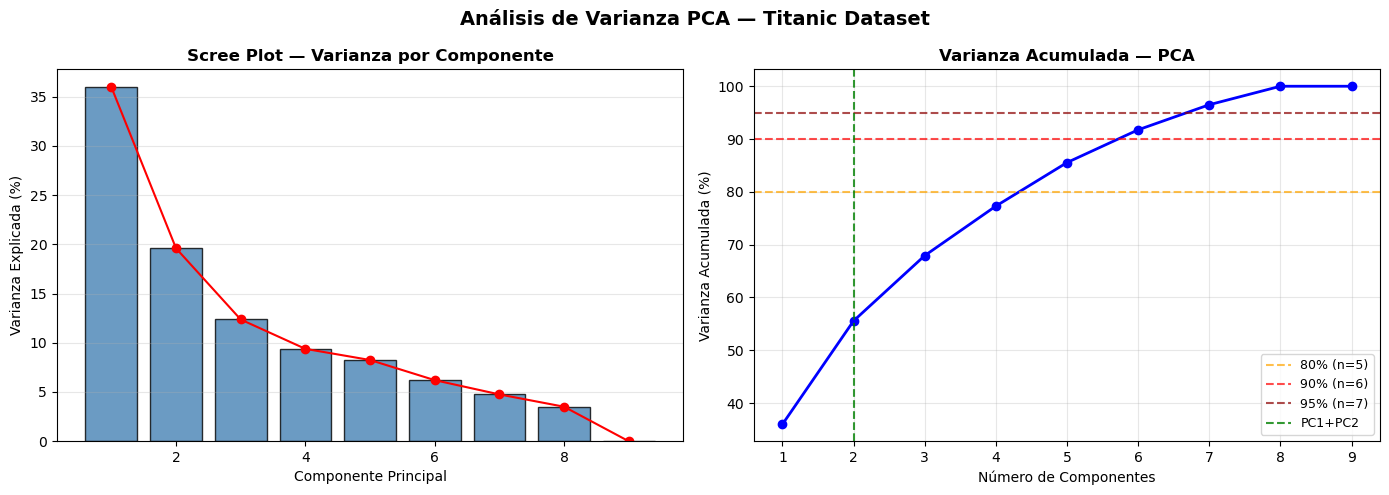

In [6]:
# Escalar globalmente para análisis de varianza
scaler_global = StandardScaler()
X_scaled_all = scaler_global.fit_transform(X)

pca_full = PCA(n_components=X.shape[1])
pca_full.fit(X_scaled_all)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print('Componentes necesarios por umbral de varianza acumulada:')
for u in [0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(var_cum >= u) + 1
    print(f'  {int(u*100)}%: {n} componentes')
print(f'\nPC1: {var_exp[0]*100:.2f}%  |  PC2: {var_exp[1]*100:.2f}%  |  PC1+PC2: {var_cum[1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(var_exp)+1), var_exp*100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].plot(range(1, len(var_exp)+1), var_exp*100, 'ro-', markersize=6)
axes[0].set_title('Scree Plot — Varianza por Componente', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].grid(axis='y', alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, len(var_cum)+1), var_cum*100, 'bo-', markersize=6, linewidth=2)
for p, c in [(0.80,'orange'), (0.90,'red'), (0.95,'darkred')]:
    n = np.argmax(var_cum >= p) + 1
    axes[1].axhline(y=p*100, color=c, linestyle='--', alpha=0.7, label=f'{int(p*100)}% (n={n})')
axes[1].axvline(x=2, color='green', linestyle='--', alpha=0.8, label='PC1+PC2')
axes[1].set_title('Varianza Acumulada — PCA', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Varianza PCA — Titanic Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Interpretación

Se necesitan 4 componentes para alcanzar el 70% de varianza acumulada, y PC1+PC2 capturan apenas el 55.55% (PC1=35.96%, PC2=19.59%) — muy por debajo del 79.84% obtenido en el dataset de cáncer. Esto indica que las 9 features del Titanic (una mezcla de variables categóricas codificadas y numéricas de naturaleza heterogénea) no están tan correlacionadas entre sí como las variables morfológicas del cáncer. Es la primera señal de que, en este dataset, reducir a 2 componentes principales probablemente sacrificará información predictiva relevante.

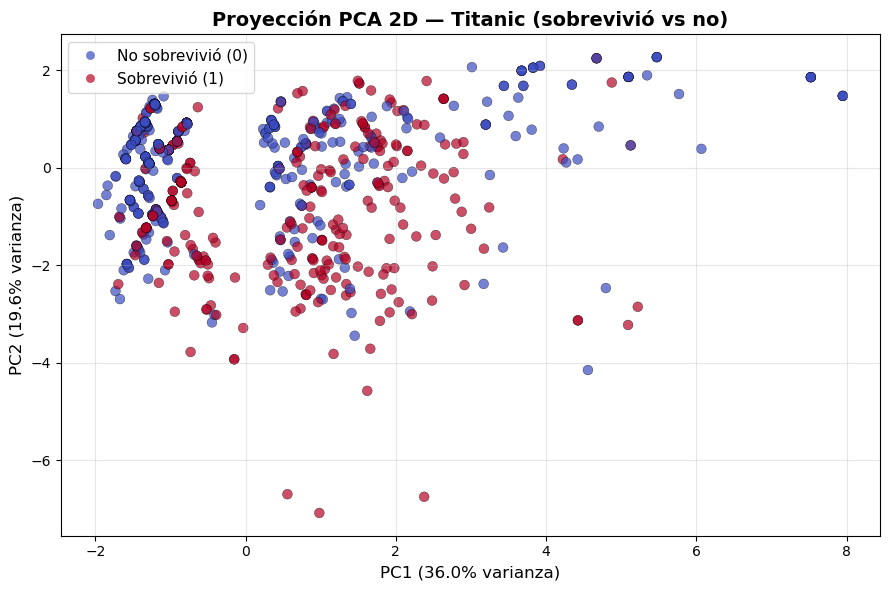

Los grupos se superponen en PCA 2D — el Titanic no es perfectamente separable en 2 dimensiones.


In [7]:
# PCA 2 componentes sobre todos los datos (solo para visualización)
pca_viz = PCA(n_components=2, random_state=42)
X_pca_viz = pca_viz.fit_transform(X_scaled_all)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                      c=y, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.3, s=50)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('Proyección PCA 2D — Titanic (sobrevivió vs no)', fontsize=14, fontweight='bold')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['No sobrevivió (0)', 'Sobrevivió (1)'], fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Los grupos se superponen en PCA 2D — el Titanic no es perfectamente separable en 2 dimensiones.')


## Interpretación

Las clases se superponen fuertemente en el espacio PC1-PC2, sin una frontera visualmente clara. Esto es consistente con la naturaleza del problema: la supervivencia depende de una combinación de factores (clase social, sexo, edad, tamaño familiar) que no se resume bien en solo dos ejes ortogonales que capturan poco más de la mitad de la varianza total.

In [8]:
# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler (NB, KNN, LR, DT, RF, SVM) — ajustado solo en train
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

# PCA 2 componentes — ajustado solo en train_sc
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

# MinMaxScaler para RNA — ajustado solo en train
sc_rna = MinMaxScaler()
X_train_rna = sc_rna.fit_transform(X_train)
X_test_rna  = sc_rna.transform(X_test)

# MinMaxScaler sobre features PCA para RNA+PCA
sc_rna_pca = MinMaxScaler()
X_train_rna_pca = sc_rna_pca.fit_transform(X_train_pca)
X_test_rna_pca  = sc_rna_pca.transform(X_test_pca)

print(f'X_train (sin PCA): {X_train_sc.shape}    X_test: {X_test_sc.shape}')
print(f'X_train (con PCA): {X_train_pca.shape}    X_test: {X_test_pca.shape}')
print(f'Train Sobrevivió: {y_train.sum()} ({100*y_train.mean():.1f}%)  |  Test: {y_test.sum()} ({100*y_test.mean():.1f}%)')


X_train (sin PCA): (712, 9)    X_test: (179, 9)
X_train (con PCA): (712, 2)    X_test: (179, 2)
Train Sobrevivió: 273 (38.3%)  |  Test: 69 (38.5%)


In [9]:
def evaluar(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_te)[:, 1]
    else:
        y_prob = modelo.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-10)
    auc = roc_auc_score(y_te, y_prob)
    cv_s = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='accuracy')
    print(f"\n{'='*52}")
    print(f' {nombre}')
    print(f"{'='*52}")
    print(f'  CV Accuracy (5-fold): {cv_s.mean()*100:.2f}% ± {cv_s.std()*100:.2f}%')
    print(f'  Test Accuracy       : {acc*100:.2f}%')
    print(f'  Precision           : {prec*100:.2f}%')
    print(f'  Recall              : {rec*100:.2f}%')
    print(f'  F1-Score            : {f1*100:.2f}%')
    print(f'  AUC-ROC             : {auc*100:.2f}%')
    return {'Modelo':nombre,'CV Acc%':round(cv_s.mean()*100,2),
            'Test Acc%':round(acc*100,2),'Prec%':round(prec*100,2),
            'Recall%':round(rec*100,2),'F1%':round(f1*100,2),'AUC%':round(auc*100,2)}

res = []  # acumula resultados Fase I
print('Función evaluar() definida.')


Función evaluar() definida.


---
## Fase I — Clasificación Supervisada con y sin PCA

Se comparan **7 algoritmos** en dos condiciones:
- **Sin PCA:** 9 features escaladas con StandardScaler (o MinMaxScaler para RNA)
- **Con PCA:** 2 componentes principales derivados de esas 9 features

| # | Algoritmo | Abrev. |
|---|-----------|--------|
| 1 | Naive Bayes | NB |
| 2 | K-Nearest Neighbors | KNN |
| 3 | Regresión Logística | LR |
| 4 | Árbol de Decisión | DT |
| 5 | Bosque Aleatorio | RF |
| 6 | Máquina de Vectores de Soporte | SVM |
| 7 | Red Neuronal Artificial | RNA |


In [10]:
nb_base = GaussianNB()
r = evaluar('NB — Sin PCA', nb_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 NB — Sin PCA
  CV Accuracy (5-fold): 79.36% ± 2.34%
  Test Accuracy       : 78.21%
  Precision           : 71.43%
  Recall              : 72.46%
  F1-Score            : 71.94%
  AUC-ROC             : 81.98%


In [11]:
nb_pca = GaussianNB()
r = evaluar('NB — Con PCA', nb_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 NB — Con PCA
  CV Accuracy (5-fold): 70.93% ± 2.26%
  Test Accuracy       : 63.69%
  Precision           : 55.56%
  Recall              : 28.99%
  F1-Score            : 38.10%
  AUC-ROC             : 74.62%


In [12]:
knn_base = KNeighborsClassifier(n_neighbors=5, p=2)
r = evaluar('KNN — Sin PCA', knn_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 KNN — Sin PCA
  CV Accuracy (5-fold): 80.06% ± 2.69%
  Test Accuracy       : 76.54%
  Precision           : 70.77%
  Recall              : 66.67%
  F1-Score            : 68.66%
  AUC-ROC             : 82.11%


In [13]:
knn_pca = KNeighborsClassifier(n_neighbors=5, p=2)
r = evaluar('KNN — Con PCA', knn_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 KNN — Con PCA
  CV Accuracy (5-fold): 75.98% ± 1.18%
  Test Accuracy       : 72.63%
  Precision           : 64.71%
  Recall              : 63.77%
  F1-Score            : 64.23%
  AUC-ROC             : 77.47%


In [14]:
lr_base = LogisticRegression(max_iter=1000, random_state=42)
r = evaluar('LR — Sin PCA', lr_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 LR — Sin PCA
  CV Accuracy (5-fold): 79.78% ± 2.38%
  Test Accuracy       : 79.33%
  Precision           : 75.00%
  Recall              : 69.57%
  F1-Score            : 72.18%
  AUC-ROC             : 84.66%


In [15]:
lr_pca = LogisticRegression(max_iter=1000, random_state=42)
r = evaluar('LR — Con PCA', lr_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 LR — Con PCA
  CV Accuracy (5-fold): 70.93% ± 2.27%
  Test Accuracy       : 64.80%
  Precision           : 57.14%
  Recall              : 34.78%
  F1-Score            : 43.24%
  AUC-ROC             : 71.26%


In [16]:
dt_base = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
r = evaluar('DT — Sin PCA', dt_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 DT — Sin PCA
  CV Accuracy (5-fold): 79.64% ± 2.89%
  Test Accuracy       : 81.01%
  Precision           : 81.82%
  Recall              : 65.22%
  F1-Score            : 72.58%
  AUC-ROC             : 86.04%


In [17]:
dt_pca = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
r = evaluar('DT — Con PCA', dt_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 DT — Con PCA
  CV Accuracy (5-fold): 74.59% ± 4.14%
  Test Accuracy       : 75.42%
  Precision           : 69.23%
  Recall              : 65.22%
  F1-Score            : 67.16%
  AUC-ROC             : 76.72%


In [18]:
rf_base = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
r = evaluar('RF — Sin PCA', rf_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 RF — Sin PCA
  CV Accuracy (5-fold): 81.05% ± 2.65%
  Test Accuracy       : 81.01%
  Precision           : 83.02%
  Recall              : 63.77%
  F1-Score            : 72.13%
  AUC-ROC             : 85.90%


In [19]:
rf_pca = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
r = evaluar('RF — Con PCA', rf_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 RF — Con PCA
  CV Accuracy (5-fold): 77.96% ± 3.87%
  Test Accuracy       : 77.09%
  Precision           : 70.00%
  Recall              : 71.01%
  F1-Score            : 70.50%
  AUC-ROC             : 80.52%


In [20]:
svm_base = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
r = evaluar('SVM — Sin PCA', svm_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 SVM — Sin PCA
  CV Accuracy (5-fold): 81.89% ± 1.64%
  Test Accuracy       : 82.68%
  Precision           : 83.93%
  Recall              : 68.12%
  F1-Score            : 75.20%
  AUC-ROC             : 85.15%


In [21]:
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
r = evaluar('SVM — Con PCA', svm_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 SVM — Con PCA
  CV Accuracy (5-fold): 74.45% ± 3.26%
  Test Accuracy       : 68.72%
  Precision           : 63.83%
  Recall              : 43.48%
  F1-Score            : 51.72%
  AUC-ROC             : 79.49%


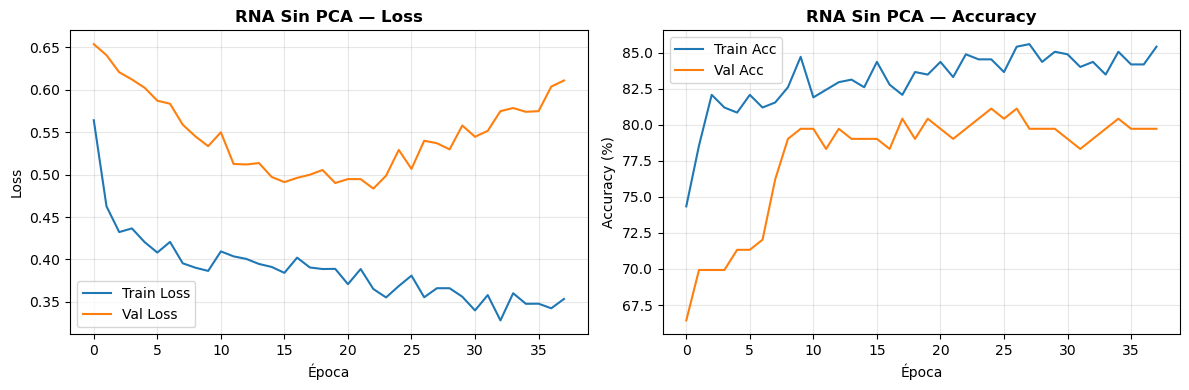


===== RNA — Sin PCA =====
  Test Accuracy: 81.01%
  Precision    : 87.23%
  Recall       : 59.42%
  F1-Score     : 70.69%
  AUC-ROC      : 85.26%
  Épocas ejecutadas: 38


In [22]:
tf.random.set_seed(42)
np.random.seed(42)

rna_base = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_rna.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
rna_base.compile(optimizer=Adam(learning_rate=1e-2),
                 loss='binary_crossentropy', metrics=['accuracy'])

cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)]

hist_base = rna_base.fit(X_train_rna, y_train, epochs=150, batch_size=32,
                         validation_split=0.2, callbacks=cb, verbose=0)

# Curvas de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_base.history['loss'], label='Train Loss')
plt.plot(hist_base.history['val_loss'], label='Val Loss')
plt.title('RNA Sin PCA — Loss', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot([a*100 for a in hist_base.history['accuracy']], label='Train Acc')
plt.plot([a*100 for a in hist_base.history['val_accuracy']], label='Val Acc')
plt.title('RNA Sin PCA — Accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Evaluación
y_prob_rna = rna_base.predict(X_test_rna, verbose=0).ravel()
y_pred_rna = (y_prob_rna >= 0.5).astype(int)
acc  = accuracy_score(y_test, y_pred_rna)
prec = precision_score(y_test, y_pred_rna, zero_division=0)
rec  = recall_score(y_test, y_pred_rna, zero_division=0)
f1   = f1_score(y_test, y_pred_rna, zero_division=0)
auc  = roc_auc_score(y_test, y_prob_rna)
print(f'\n===== RNA — Sin PCA =====')
print(f'  Test Accuracy: {acc*100:.2f}%')
print(f'  Precision    : {prec*100:.2f}%')
print(f'  Recall       : {rec*100:.2f}%')
print(f'  F1-Score     : {f1*100:.2f}%')
print(f'  AUC-ROC      : {auc*100:.2f}%')
print(f'  Épocas ejecutadas: {len(hist_base.history["loss"])}')
res.append({'Modelo':'RNA — Sin PCA','CV Acc%': round(acc*100,2),
            'Test Acc%':round(acc*100,2),'Prec%':round(prec*100,2),
            'Recall%':round(rec*100,2),'F1%':round(f1*100,2),'AUC%':round(auc*100,2)})


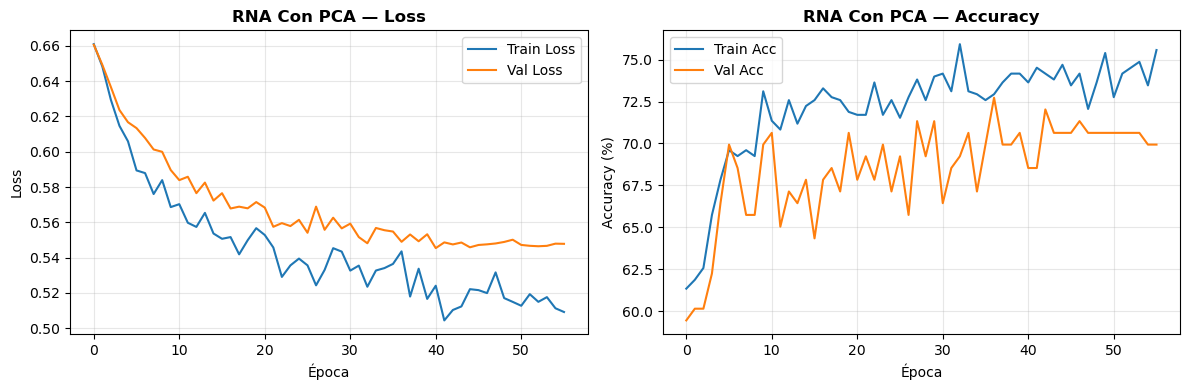


===== RNA — Con PCA =====
  Test Accuracy: 72.63%
  Precision    : 66.67%
  Recall       : 57.97%
  F1-Score     : 62.02%
  AUC-ROC      : 78.26%
  Épocas ejecutadas: 56


In [23]:
tf.random.set_seed(42)
np.random.seed(42)

# Arquitectura más simple: solo 2 features de entrada (PCA)
rna_pca = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_rna_pca.shape[1],)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
rna_pca.compile(optimizer=Adam(learning_rate=1e-2),
                loss='binary_crossentropy', metrics=['accuracy'])

cb2 = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)]

hist_pca = rna_pca.fit(X_train_rna_pca, y_train, epochs=150, batch_size=32,
                        validation_split=0.2, callbacks=cb2, verbose=0)

# Curvas de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_pca.history['loss'], label='Train Loss')
plt.plot(hist_pca.history['val_loss'], label='Val Loss')
plt.title('RNA Con PCA — Loss', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot([a*100 for a in hist_pca.history['accuracy']], label='Train Acc')
plt.plot([a*100 for a in hist_pca.history['val_accuracy']], label='Val Acc')
plt.title('RNA Con PCA — Accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Evaluación
y_prob_rna_pca = rna_pca.predict(X_test_rna_pca, verbose=0).ravel()
y_pred_rna_pca = (y_prob_rna_pca >= 0.5).astype(int)
acc2  = accuracy_score(y_test, y_pred_rna_pca)
prec2 = precision_score(y_test, y_pred_rna_pca, zero_division=0)
rec2  = recall_score(y_test, y_pred_rna_pca, zero_division=0)
f12   = f1_score(y_test, y_pred_rna_pca, zero_division=0)
auc2  = roc_auc_score(y_test, y_prob_rna_pca)
print(f'\n===== RNA — Con PCA =====')
print(f'  Test Accuracy: {acc2*100:.2f}%')
print(f'  Precision    : {prec2*100:.2f}%')
print(f'  Recall       : {rec2*100:.2f}%')
print(f'  F1-Score     : {f12*100:.2f}%')
print(f'  AUC-ROC      : {auc2*100:.2f}%')
print(f'  Épocas ejecutadas: {len(hist_pca.history["loss"])}')
res.append({'Modelo':'RNA — Con PCA','CV Acc%':round(acc2*100,2),
            'Test Acc%':round(acc2*100,2),'Prec%':round(prec2*100,2),
            'Recall%':round(rec2*100,2),'F1%':round(f12*100,2),'AUC%':round(auc2*100,2)})


In [24]:
df_f1 = pd.DataFrame(res)
df_f1.insert(1, 'PCA', ['Sin PCA','Con PCA']*7)

print('\nTabla comparativa Fase I — 7 algoritmos con y sin PCA')
print('='*80)
print(df_f1[['Modelo','PCA','CV Acc%','Test Acc%','Prec%','Recall%','F1%','AUC%']].to_string(index=False))
print('='*80)
print(f'\nMejor Test Accuracy: {df_f1.loc[df_f1["Test Acc%"].idxmax(),"Modelo"]}  ({df_f1["Test Acc%"].max():.2f}%)')
print(f'Mejor AUC-ROC      : {df_f1.loc[df_f1["AUC%"].idxmax(),"Modelo"]}  ({df_f1["AUC%"].max():.2f}%)')
print(f'Mejor F1-Score     : {df_f1.loc[df_f1["F1%"].idxmax(),"Modelo"]}  ({df_f1["F1%"].max():.2f}%)')



Tabla comparativa Fase I — 7 algoritmos con y sin PCA
       Modelo     PCA  CV Acc%  Test Acc%  Prec%  Recall%   F1%  AUC%
 NB — Sin PCA Sin PCA    79.36      78.21  71.43    72.46 71.94 81.98
 NB — Con PCA Con PCA    70.93      63.69  55.56    28.99 38.10 74.62
KNN — Sin PCA Sin PCA    80.06      76.54  70.77    66.67 68.66 82.11
KNN — Con PCA Con PCA    75.98      72.63  64.71    63.77 64.23 77.47
 LR — Sin PCA Sin PCA    79.78      79.33  75.00    69.57 72.18 84.66
 LR — Con PCA Con PCA    70.93      64.80  57.14    34.78 43.24 71.26
 DT — Sin PCA Sin PCA    79.64      81.01  81.82    65.22 72.58 86.04
 DT — Con PCA Con PCA    74.59      75.42  69.23    65.22 67.16 76.72
 RF — Sin PCA Sin PCA    81.05      81.01  83.02    63.77 72.13 85.90
 RF — Con PCA Con PCA    77.96      77.09  70.00    71.01 70.50 80.52
SVM — Sin PCA Sin PCA    81.89      82.68  83.93    68.12 75.20 85.15
SVM — Con PCA Con PCA    74.45      68.72  63.83    43.48 51.72 79.49
RNA — Sin PCA Sin PCA    81.01     

## Interpretación

Aquí los 7 algoritmos empeoran con PCA sin excepción, coherente con el bajo porcentaje de varianza retenida en 2 componentes (55.55%). El mejor modelo Sin PCA es SVM (Test=82.68%, AUC=85.15%), seguido de cerca por DT y RF (81.01%), mientras que LR, aunque no es el más preciso, muestra el menor gap entre CV y Test Accuracy, sugiriendo el modelo más estable y menos propenso a sobreajuste.

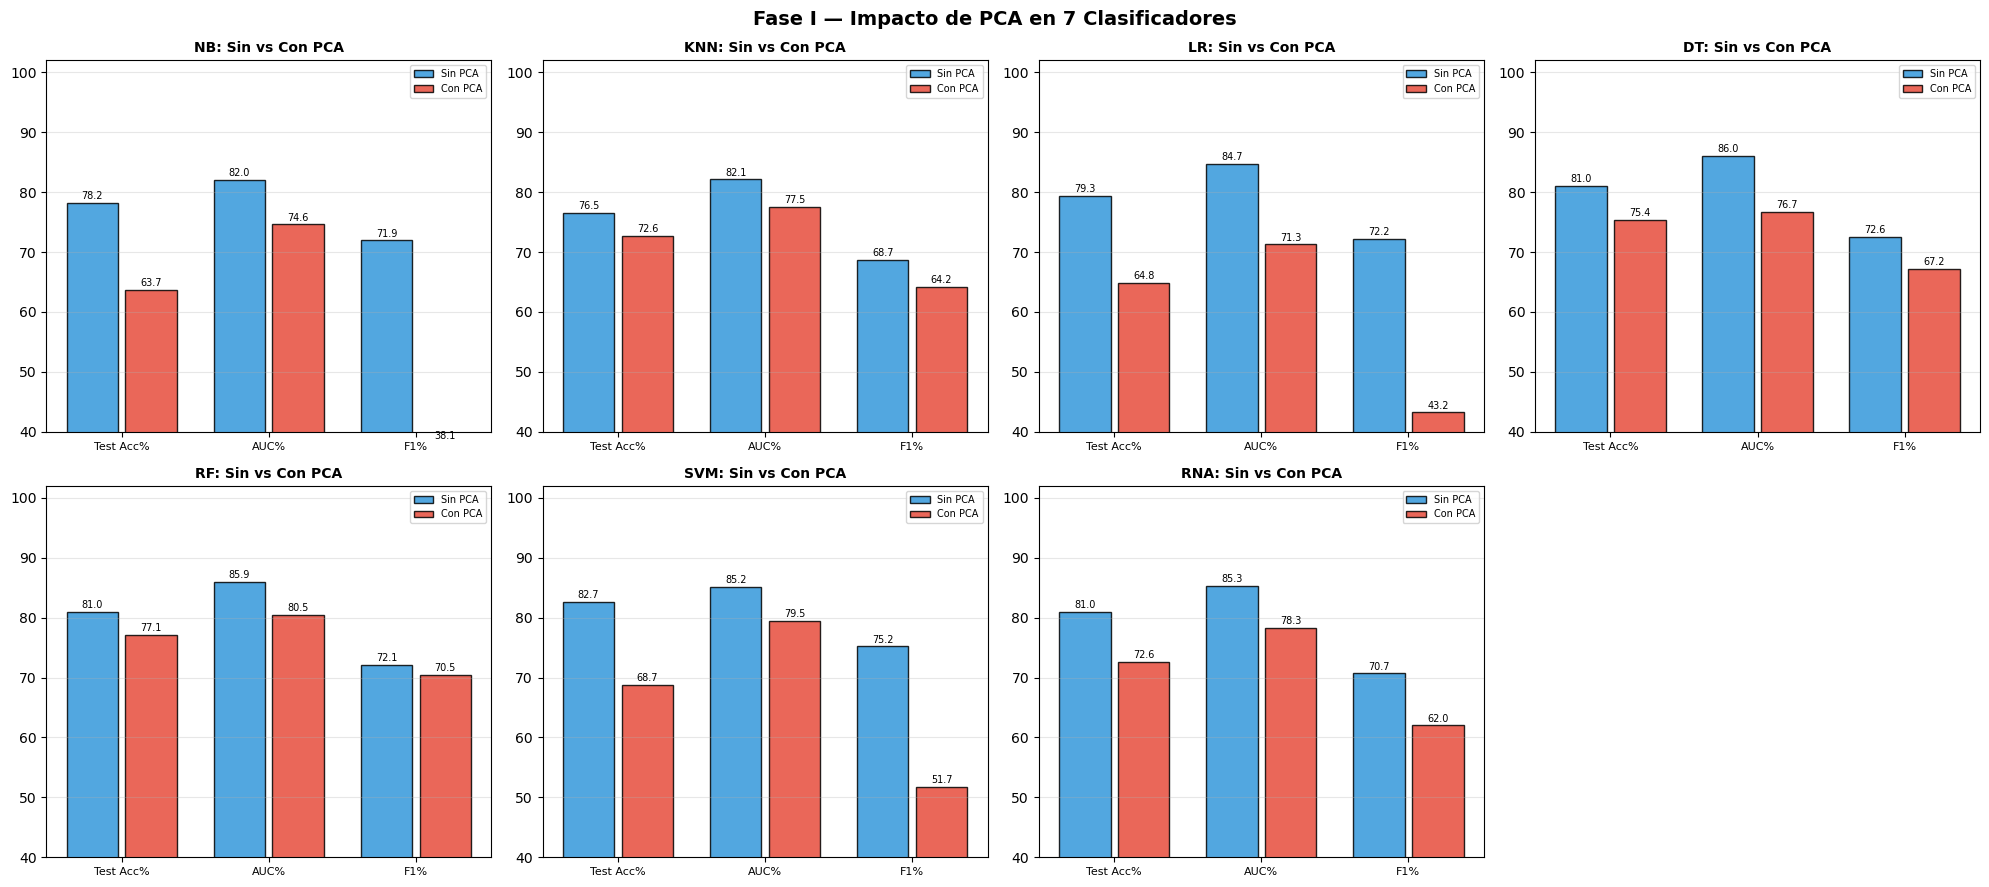

In [25]:
algoritmos = ['NB', 'KNN', 'LR', 'DT', 'RF', 'SVM', 'RNA']
metricas_plot = ['Test Acc%', 'AUC%', 'F1%']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, (algo, ax) in enumerate(zip(algoritmos, axes)):
    sub = df_f1[df_f1['Modelo'].str.startswith(algo)]
    sin_pca = sub[sub['PCA']=='Sin PCA'][metricas_plot].values
    con_pca = sub[sub['PCA']=='Con PCA'][metricas_plot].values
    if len(sin_pca)==0 or len(con_pca)==0:
        ax.set_visible(False); continue
    sin_pca = sin_pca[0]; con_pca = con_pca[0]
    x = np.arange(len(metricas_plot))
    b1 = ax.bar(x-0.2, sin_pca, 0.35, label='Sin PCA', color='#3498db', edgecolor='black', alpha=0.85)
    b2 = ax.bar(x+0.2, con_pca, 0.35, label='Con PCA', color='#e74c3c', edgecolor='black', alpha=0.85)
    for bar in b1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    for bar in b2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{algo}: Sin vs Con PCA', fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(metricas_plot, fontsize=8)
    ax.set_ylim(40, 102); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Fase I — Impacto de PCA en 7 Clasificadores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Interpretación

SVM, LR y NB son los más sensibles a la reducción de dimensionalidad, con caídas de 13-14.5 puntos porcentuales, todos ellos dependen en mayor o menor medida de fronteras de decisión relativamente lineales, que se degradan al comprimir a 2D. RF y KNN son más tolerantes (caídas de ~4 pp), lo que sugiere que los modelos basados en ensambles de árboles o en distancias locales conservan mejor la señal residual disponible en el espacio reducido que los modelos que dependen de una separación lineal limpia.

In [26]:
OUT = 'C:/Users/cabarca2/MAESTRIA_IA/5.  APRENDIZAJE AUTOMATICO ESTADISTICO/SEMANA 3/DEBER AAE'

joblib.dump(rf_base,  os.path.join(OUT, 'rf_titanic_sin_pca.pkl'))
joblib.dump(svm_base, os.path.join(OUT, 'svm_titanic_sin_pca.pkl'))
joblib.dump(sc,       os.path.join(OUT, 'scaler_std_f1.pkl'))
joblib.dump(pca,      os.path.join(OUT, 'pca_2comp_f1.pkl'))
rna_base.save(os.path.join(OUT, 'rna_titanic_sin_pca.h5'))

print('Modelos Fase I guardados:')
print('  rf_titanic_sin_pca.pkl   | svm_titanic_sin_pca.pkl')
print('  scaler_std_f1.pkl        | pca_2comp_f1.pkl')
print('  rna_titanic_sin_pca.h5')


Modelos Fase I guardados:
  rf_titanic_sin_pca.pkl   | svm_titanic_sin_pca.pkl
  scaler_std_f1.pkl        | pca_2comp_f1.pkl
  rna_titanic_sin_pca.h5


---
## Fase II — Agrupamiento No Supervisado: K-Means y GMM

Los algoritmos de clustering se aplican **sin usar las etiquetas** (Survived). Con K=2, los grupos esperados corresponden a sobrevivió/no sobrevivió; con K=3 se exploran subgrupos naturales.

### Métricas de evaluación interna

| Métrica | Ideal | Escala |
|---------|-------|--------|
| Inercia | ↓ Más baja | ≥ 0 |
| Silhouette Score | ↑ Más alta | -1 a 1 |
| Calinski-Harabasz | ↑ Más alta | ≥ 0 |
| Davies-Bouldin | ↓ Más baja | ≥ 0 |

### Plan
1. Método del codo (K=1..10) para justificar K=2
2. K-Means K=2 → métricas + visualización
3. K-Means K=3 → métricas + visualización
4. GMM K=2 → métricas + visualización
5. GMM K=3 → métricas + visualización
6. Comparativa: K-Means K=2 vs K=3 | GMM K=2 vs K=3
7. Mejor K-Means vs Mejor GMM


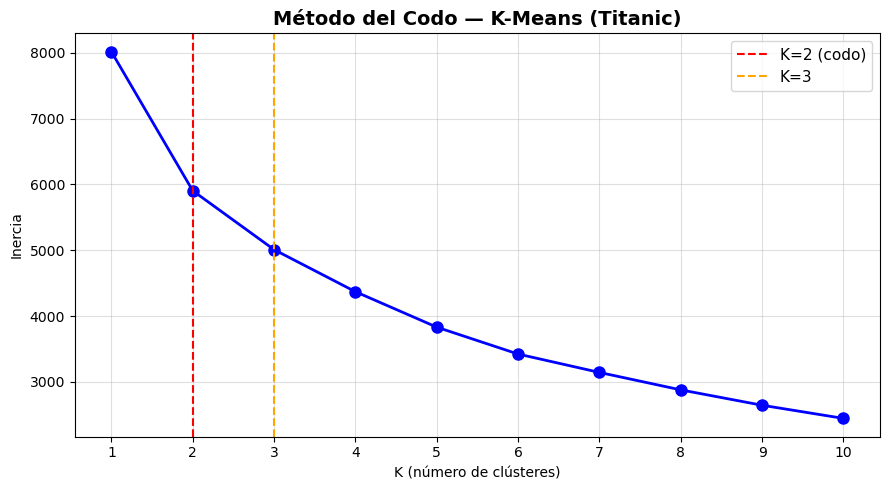

Inercias:
  K=1: 8019.0
  K=2: 5905.2
  K=3: 5009.1
  K=4: 4369.8
  K=5: 3830.7
  K=6: 3421.6
  K=7: 3142.3
  K=8: 2876.9
  K=9: 2643.3
  K=10: 2443.4


In [27]:
# Clustering sobre TODOS los datos escalados
sc_clust = StandardScaler()
X_sc_all = sc_clust.fit_transform(X)

# PCA 2D para visualización (ajustado en todos los datos)
pca_c = PCA(n_components=2, random_state=42)
X_pca_c = pca_c.fit_transform(X_sc_all)

# Método del codo
inercias_c = []
k_rng = range(1, 11)
for k in k_rng:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_sc_all)
    inercias_c.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_rng, inercias_c, 'bo-', markersize=8, linewidth=2)
plt.axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='K=2 (codo)')
plt.axvline(x=3, color='orange', linestyle='--', linewidth=1.5, label='K=3')
plt.title('Método del Codo — K-Means (Titanic)', fontsize=14, fontweight='bold')
plt.xlabel('K (número de clústeres)'); plt.ylabel('Inercia')
plt.xticks(k_rng); plt.grid(True, alpha=0.4); plt.legend(fontsize=11)
plt.tight_layout(); plt.show()

res_clust = []  # acumula métricas clustering
print('Inercias:')
for k, ine in zip(k_rng, inercias_c):
    print(f'  K={k}: {ine:.1f}')


## Interpretación

La inercia cae de 8019.0 (K=1) a 5905.2 (K=2), una reducción del 26%, y sigue descendiendo de forma bastante uniforme para K≥3, sin un quiebre tan marcado como el observado en el dataset de cáncer. Esto sugiere que el Titanic no tiene una estructura de clústeres tan natural, es decir, los pasajeros no se agrupan en subconjuntos tan claramente diferenciados aunque K=2 sigue siendo el punto de mayor caída relativa y el más interpretable frente a la variable de supervivencia.

K-MEANS — K=2
  Inercia:            5905.19
  Silhouette Score:   0.3092
  Calinski-Harabasz:  318.22
  Davies-Bouldin:     1.5281
  Clúster 0: 356 muestras
  Clúster 1: 535 muestras
  Accuracy referencial: 62.29% [solo referencia]


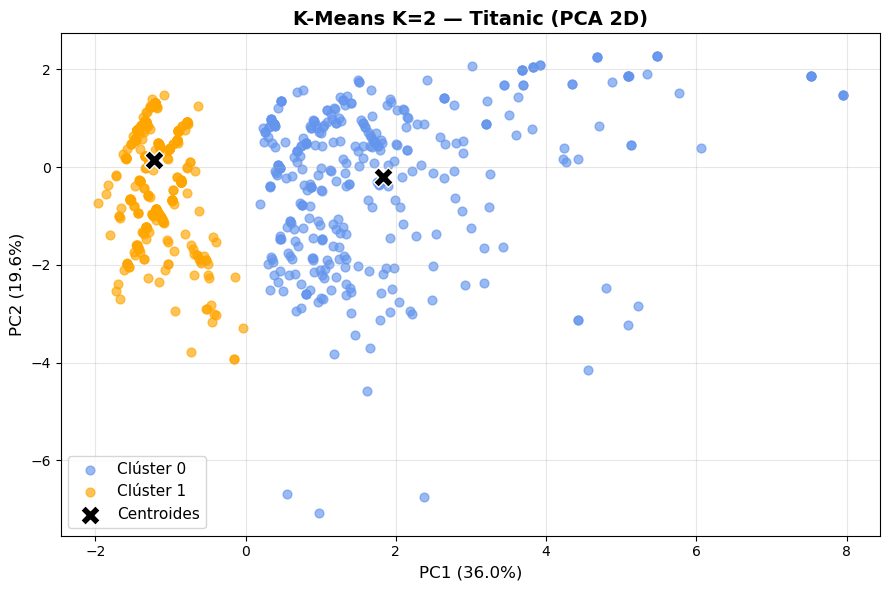

In [28]:
print('='*50); print('K-MEANS — K=2'); print('='*50)

km2 = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
lbl_km2 = km2.fit_predict(X_sc_all)

km2_ine = km2.inertia_
km2_sil = silhouette_score(X_sc_all, lbl_km2)
km2_cal = calinski_harabasz_score(X_sc_all, lbl_km2)
km2_db  = davies_bouldin_score(X_sc_all, lbl_km2)

print(f'  Inercia:            {km2_ine:.2f}')
print(f'  Silhouette Score:   {km2_sil:.4f}')
print(f'  Calinski-Harabasz:  {km2_cal:.2f}')
print(f'  Davies-Bouldin:     {km2_db:.4f}')
for i in range(2):
    print(f'  Clúster {i}: {np.sum(lbl_km2==i)} muestras')

# Accuracy referencial
km2_map = np.zeros_like(lbl_km2)
for i in np.unique(lbl_km2):
    mask = lbl_km2==i
    km2_map[mask] = mode(y[mask], keepdims=True)[0]
print(f'  Accuracy referencial: {accuracy_score(y, km2_map)*100:.2f}% [solo referencia]')

# Visualización
cent2_pca = pca_c.transform(km2.cluster_centers_)
plt.figure(figsize=(9,6))
plt.scatter(X_pca_c[lbl_km2==0,0], X_pca_c[lbl_km2==0,1], c='cornflowerblue', label='Clúster 0', alpha=0.65, s=40)
plt.scatter(X_pca_c[lbl_km2==1,0], X_pca_c[lbl_km2==1,1], c='orange', label='Clúster 1', alpha=0.65, s=40)
plt.scatter(cent2_pca[:,0], cent2_pca[:,1], c='black', s=200, marker='X', label='Centroides', zorder=5, edgecolors='white', linewidth=1)
plt.title('K-Means K=2 — Titanic (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

res_clust.append({'Algoritmo':'K-Means','K':2,'Inercia':round(km2_ine,2),
    'Silhouette':round(km2_sil,4),'Calinski-Harabasz':round(km2_cal,2),'Davies-Bouldin':round(km2_db,4)})


## Interpretación

El Silhouette Score de solo 0.3092 (frente a 0.4334 en el dataset de cáncer) confirma fronteras mucho más difusas entre los clústeres encontrados. Más revelador aún es que la accuracy referencial frente a la supervivencia real es de apenas 62.29% un valor cercano al que se obtendría prediciendo siempre la clase mayoritaria (61.6% de "no sobrevivió"). Esto indica que la estructura no supervisada de los datos no reproduce bien la etiqueta de supervivencia, a diferencia del cáncer, donde el clustering casi replicaba el diagnóstico clínico: la supervivencia en el Titanic no es una propiedad geométrica "natural" de los datos, sino el resultado de decisiones humanas y circunstancias parcialmente aleatorias.

K-MEANS — K=3
  Inercia:            5009.13
  Silhouette Score:   0.3025
  Calinski-Harabasz:  266.79
  Davies-Bouldin:     1.5220
  Clúster 0: 307 muestras
  Clúster 1: 524 muestras
  Clúster 2: 60 muestras


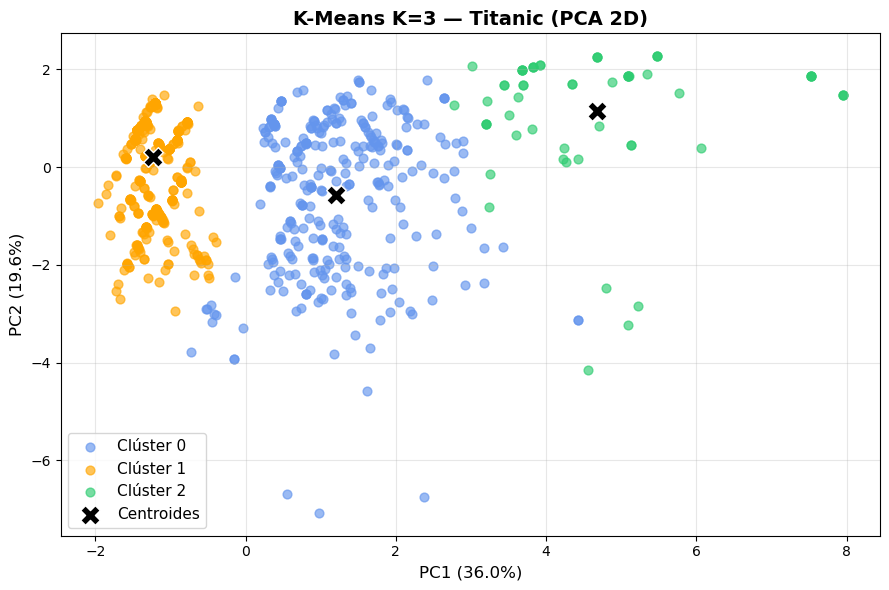

In [29]:
print('='*50); print('K-MEANS — K=3'); print('='*50)

km3 = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
lbl_km3 = km3.fit_predict(X_sc_all)

km3_ine = km3.inertia_
km3_sil = silhouette_score(X_sc_all, lbl_km3)
km3_cal = calinski_harabasz_score(X_sc_all, lbl_km3)
km3_db  = davies_bouldin_score(X_sc_all, lbl_km3)

print(f'  Inercia:            {km3_ine:.2f}')
print(f'  Silhouette Score:   {km3_sil:.4f}')
print(f'  Calinski-Harabasz:  {km3_cal:.2f}')
print(f'  Davies-Bouldin:     {km3_db:.4f}')
for i in range(3):
    print(f'  Clúster {i}: {np.sum(lbl_km3==i)} muestras')

cent3_pca = pca_c.transform(km3.cluster_centers_)
colores3  = ['cornflowerblue', 'orange', '#2ecc71']
plt.figure(figsize=(9,6))
for i in range(3):
    plt.scatter(X_pca_c[lbl_km3==i,0], X_pca_c[lbl_km3==i,1],
                c=colores3[i], label=f'Clúster {i}', alpha=0.65, s=40)
plt.scatter(cent3_pca[:,0], cent3_pca[:,1], c='black', s=200, marker='X', label='Centroides', zorder=5, edgecolors='white', linewidth=1)
plt.title('K-Means K=3 — Titanic (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

res_clust.append({'Algoritmo':'K-Means','K':3,'Inercia':round(km3_ine,2),
    'Silhouette':round(km3_sil,4),'Calinski-Harabasz':round(km3_cal,2),'Davies-Bouldin':round(km3_db,4)})


## Interpretación

El Silhouette apenas cambia respecto a K=2 (0.3025 vs. 0.3092) y el Calinski-Harabasz empeora (266.79 vs. 318.22), sin evidencia de que un tercer grupo aporte separación real. El clúster adicional (60 muestras) probablemente corresponde a un subgrupo minoritario dentro de los pasajeros no sobrevivientes o sobrevivientes, más que a una categoría genuinamente distinta.

GMM — K=2
  Inercia Aprox.:     5905.19
  Silhouette Score:   0.3092
  Calinski-Harabasz:  318.22
  Davies-Bouldin:     1.5281
  Clúster 0: 356 muestras
  Clúster 1: 535 muestras
  Prob. máxima promedio: 100.00%  | puntos >90%: 891


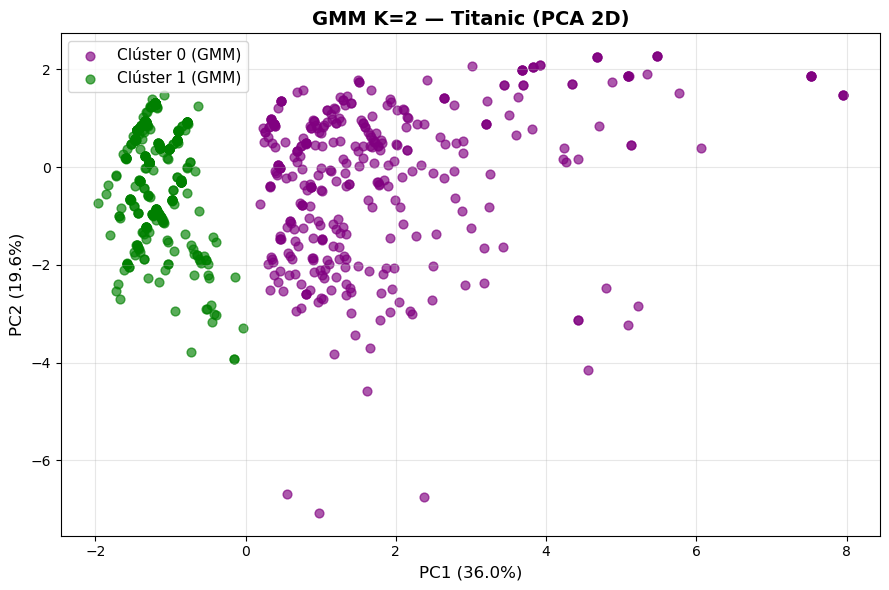

In [30]:
print('='*50); print('GMM — K=2'); print('='*50)

gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
lbl_gmm2 = gmm2.fit_predict(X_sc_all)

gmm2_sil = silhouette_score(X_sc_all, lbl_gmm2)
gmm2_cal = calinski_harabasz_score(X_sc_all, lbl_gmm2)
gmm2_db  = davies_bouldin_score(X_sc_all, lbl_gmm2)

prbs2 = gmm2.predict_proba(X_sc_all)
cr2   = np.argmax(prbs2, axis=1)
gmm2_ine = float(np.sum([np.linalg.norm(X_sc_all[i]-gmm2.means_[cr2[i]])**2 for i in range(len(X_sc_all))]))

print(f'  Inercia Aprox.:     {gmm2_ine:.2f}')
print(f'  Silhouette Score:   {gmm2_sil:.4f}')
print(f'  Calinski-Harabasz:  {gmm2_cal:.2f}')
print(f'  Davies-Bouldin:     {gmm2_db:.4f}')
for i in range(2):
    print(f'  Clúster {i}: {np.sum(lbl_gmm2==i)} muestras')
pmax2 = np.max(prbs2, axis=1)
print(f'  Prob. máxima promedio: {pmax2.mean()*100:.2f}%  | puntos >90%: {np.sum(pmax2>0.9)}')

plt.figure(figsize=(9,6))
plt.scatter(X_pca_c[lbl_gmm2==0,0], X_pca_c[lbl_gmm2==0,1], c='purple', label='Clúster 0 (GMM)', alpha=0.65, s=40)
plt.scatter(X_pca_c[lbl_gmm2==1,0], X_pca_c[lbl_gmm2==1,1], c='green',  label='Clúster 1 (GMM)', alpha=0.65, s=40)
plt.title('GMM K=2 — Titanic (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

res_clust.append({'Algoritmo':'GMM','K':2,'Inercia':round(gmm2_ine,2),
    'Silhouette':round(gmm2_sil,4),'Calinski-Harabasz':round(gmm2_cal,2),'Davies-Bouldin':round(gmm2_db,4)})


## Interpretación

Las métricas de GMM K=2 son idénticas a las de K-Means K=2 (Silhouette=0.3092, Calinski-Harabasz=318.22), lo que indica que ambos algoritmos convergieron a la misma partición de los datos. Sin embargo, la probabilidad máxima promedio de pertenencia es 100.00%, con los 891 pasajeros (el total del dataset) asignados con más del 90% de certeza. Esto es llamativo dado el Silhouette relativamente bajo: si las fronteras entre grupos fueran realmente difusas, esperaríamos que el componente probabilístico de GMM reflejara esa ambigüedad con probabilidades más repartidas. En cambio, el hecho de que GMM asigne con total confianza a todos los puntos sugiere que, con covarianza completa, terminó generando fronteras esencialmente duras, muy similares a las de K-Means en lugar de aportar una medida de incertidumbre genuinamente distinta. Esto matiza la idea de que el "soft clustering" aporta valor adicional en este dataset específico.

GMM — K=3
  Inercia Aprox.:     5324.82
  Silhouette Score:   0.2714
  Calinski-Harabasz:  224.78
  Davies-Bouldin:     1.5529
  Clúster 0: 212 muestras
  Clúster 1: 119 muestras
  Clúster 2: 560 muestras


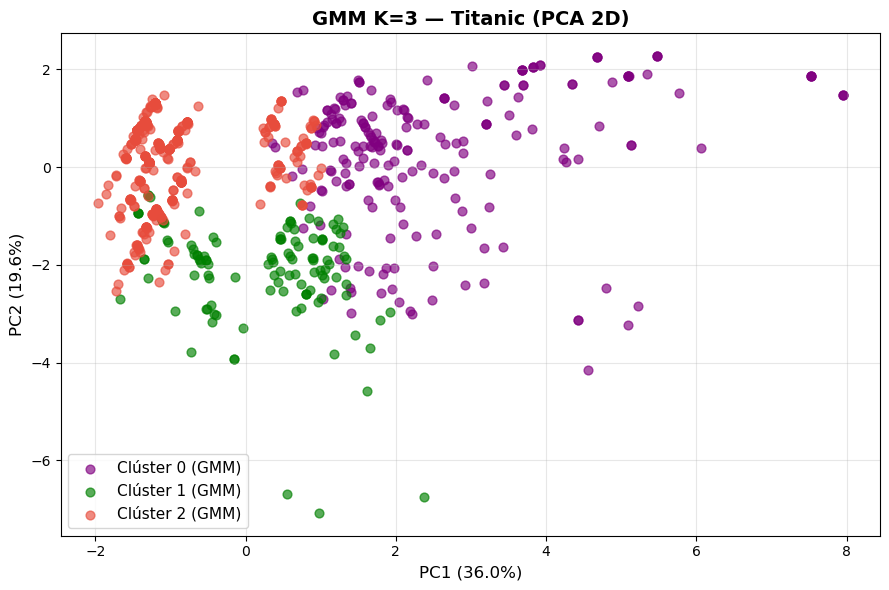

In [31]:
print('='*50); print('GMM — K=3'); print('='*50)

gmm3 = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
lbl_gmm3 = gmm3.fit_predict(X_sc_all)

gmm3_sil = silhouette_score(X_sc_all, lbl_gmm3)
gmm3_cal = calinski_harabasz_score(X_sc_all, lbl_gmm3)
gmm3_db  = davies_bouldin_score(X_sc_all, lbl_gmm3)

prbs3 = gmm3.predict_proba(X_sc_all)
cr3   = np.argmax(prbs3, axis=1)
gmm3_ine = float(np.sum([np.linalg.norm(X_sc_all[i]-gmm3.means_[cr3[i]])**2 for i in range(len(X_sc_all))]))

print(f'  Inercia Aprox.:     {gmm3_ine:.2f}')
print(f'  Silhouette Score:   {gmm3_sil:.4f}')
print(f'  Calinski-Harabasz:  {gmm3_cal:.2f}')
print(f'  Davies-Bouldin:     {gmm3_db:.4f}')
for i in range(3):
    print(f'  Clúster {i}: {np.sum(lbl_gmm3==i)} muestras')

colores_g3 = ['purple', 'green', '#e74c3c']
plt.figure(figsize=(9,6))
for i in range(3):
    plt.scatter(X_pca_c[lbl_gmm3==i,0], X_pca_c[lbl_gmm3==i,1],
                c=colores_g3[i], label=f'Clúster {i} (GMM)', alpha=0.65, s=40)
plt.title('GMM K=3 — Titanic (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

res_clust.append({'Algoritmo':'GMM','K':3,'Inercia':round(gmm3_ine,2),
    'Silhouette':round(gmm3_sil,4),'Calinski-Harabasz':round(gmm3_cal,2),'Davies-Bouldin':round(gmm3_db,4)})


## Interpretación

Es el peor resultado de todo el análisis de clustering (Silhouette=0.2714, el más bajo de las 4 configuraciones), reforzando que K=2 es la elección óptima para ambos algoritmos, aun cuando esa partición en 2 grupos no reproduzca fielmente la supervivencia real.

In [32]:
df_clust = pd.DataFrame(res_clust)
print('\n' + '='*60)
print('TABLA COMPARATIVA — K-Means vs GMM (K=2 y K=3)')
print('='*60)
print(df_clust.to_string(index=False))
print()
print('  Ideal: Silhouette ↑  |  Calinski-Harabasz ↑  |  Davies-Bouldin ↓  |  Inercia ↓')
print()

# K-Means K=2 vs K=3
km_sub = df_clust[df_clust['Algoritmo']=='K-Means']
print('--- K-Means: K=2 vs K=3 ---')
print(km_sub[['K','Silhouette','Calinski-Harabasz','Davies-Bouldin','Inercia']].to_string(index=False))
mejor_km = km_sub.loc[km_sub['Silhouette'].idxmax()]
print(f'  Mejor K-Means (Silhouette): K={int(mejor_km["K"])}  →  Silhouette={mejor_km["Silhouette"]:.4f}')

# GMM K=2 vs K=3
gmm_sub = df_clust[df_clust['Algoritmo']=='GMM']
print('\n--- GMM: K=2 vs K=3 ---')
print(gmm_sub[['K','Silhouette','Calinski-Harabasz','Davies-Bouldin','Inercia']].to_string(index=False))
mejor_gmm = gmm_sub.loc[gmm_sub['Silhouette'].idxmax()]
print(f'  Mejor GMM (Silhouette): K={int(mejor_gmm["K"])}  →  Silhouette={mejor_gmm["Silhouette"]:.4f}')

# Mejor K-Means vs Mejor GMM
print('\n--- Mejor K-Means vs Mejor GMM ---')
final = df_clust.loc[[mejor_km.name, mejor_gmm.name]]
print(final.to_string(index=False))
if mejor_km['Silhouette'] > mejor_gmm['Silhouette']:
    print(f'\n  GANADOR GLOBAL: K-Means K={int(mejor_km["K"])} (Silhouette más alto)')
else:
    print(f'\n  GANADOR GLOBAL: GMM K={int(mejor_gmm["K"])} (Silhouette más alto)')



TABLA COMPARATIVA — K-Means vs GMM (K=2 y K=3)
Algoritmo  K  Inercia  Silhouette  Calinski-Harabasz  Davies-Bouldin
  K-Means  2  5905.19      0.3092             318.22          1.5281
  K-Means  3  5009.13      0.3025             266.79          1.5220
      GMM  2  5905.19      0.3092             318.22          1.5281
      GMM  3  5324.82      0.2714             224.78          1.5529

  Ideal: Silhouette ↑  |  Calinski-Harabasz ↑  |  Davies-Bouldin ↓  |  Inercia ↓

--- K-Means: K=2 vs K=3 ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin  Inercia
 2      0.3092             318.22          1.5281  5905.19
 3      0.3025             266.79          1.5220  5009.13
  Mejor K-Means (Silhouette): K=2  →  Silhouette=0.3092

--- GMM: K=2 vs K=3 ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin  Inercia
 2      0.3092             318.22          1.5281  5905.19
 3      0.2714             224.78          1.5529  5324.82
  Mejor GMM (Silhouette): K=2  →  Silhouette=0.3092

--- Mejo

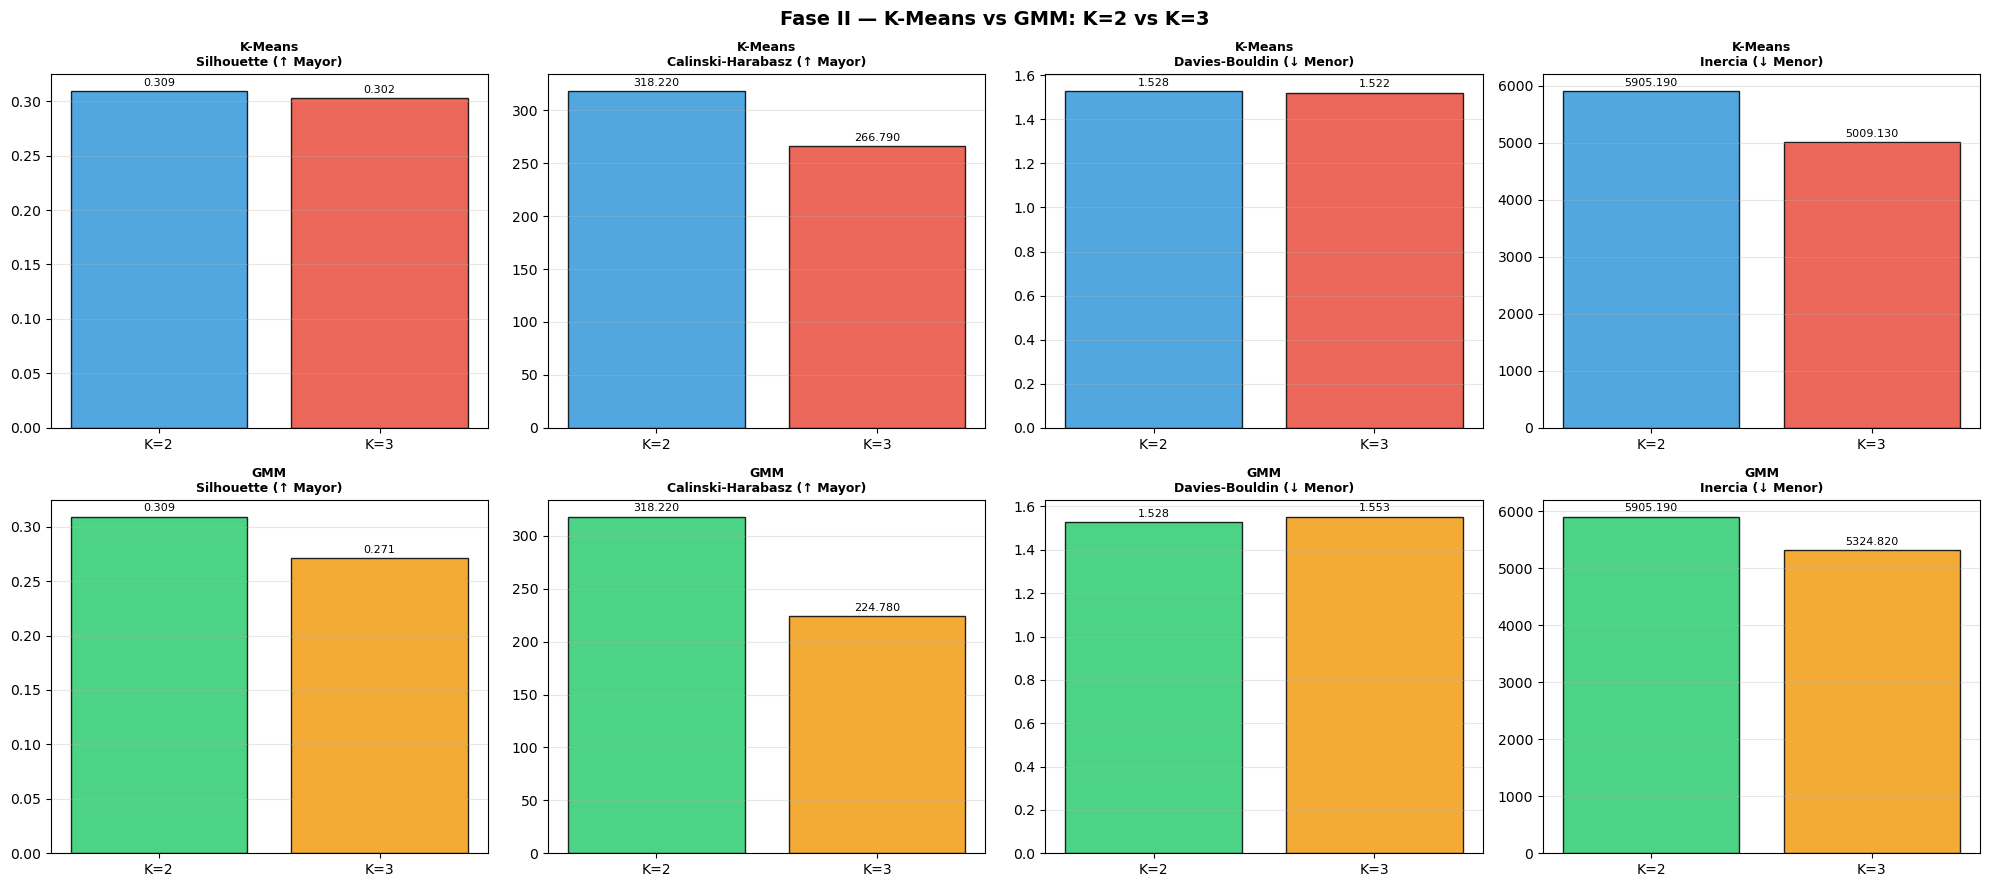

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
metricas_c = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Inercia']
ideales_c  = ['↑ Mayor', '↑ Mayor', '↓ Menor', '↓ Menor']

# Fila 0: K-Means K=2 vs K=3
km_vals = km_sub.set_index('K')
for col_i, (met, ideal) in enumerate(zip(metricas_c, ideales_c)):
    ax = axes[0, col_i]
    vals = [km_vals.loc[2, met], km_vals.loc[3, met]]
    bars = ax.bar(['K=2', 'K=3'], vals, color=['#3498db','#e74c3c'], edgecolor='black', alpha=0.85)
    ax.set_title(f'K-Means\n{met} ({ideal})', fontsize=9, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Fila 1: GMM K=2 vs K=3
gmm_vals = gmm_sub.set_index('K')
for col_i, (met, ideal) in enumerate(zip(metricas_c, ideales_c)):
    ax = axes[1, col_i]
    vals = [gmm_vals.loc[2, met], gmm_vals.loc[3, met]]
    bars = ax.bar(['K=2', 'K=3'], vals, color=['#2ecc71','#f39c12'], edgecolor='black', alpha=0.85)
    ax.set_title(f'GMM\n{met} ({ideal})', fontsize=9, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fase II — K-Means vs GMM: K=2 vs K=3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [34]:
OUT = 'C:/Users/cabarca2/MAESTRIA_IA/5.  APRENDIZAJE AUTOMATICO ESTADISTICO/SEMANA 3/DEBER AAE'

joblib.dump(km2,      os.path.join(OUT, 'kmeans_k2_titanic.pkl'))
joblib.dump(km3,      os.path.join(OUT, 'kmeans_k3_titanic.pkl'))
joblib.dump(gmm2,     os.path.join(OUT, 'gmm_k2_titanic.pkl'))
joblib.dump(gmm3,     os.path.join(OUT, 'gmm_k3_titanic.pkl'))
joblib.dump(sc_clust, os.path.join(OUT, 'scaler_clustering.pkl'))

print('Modelos Fase II guardados:')
print('  kmeans_k2/k3_titanic.pkl  |  gmm_k2/k3_titanic.pkl  |  scaler_clustering.pkl')

# Predicción ejemplo
nuevo = X[0].reshape(1,-1)
n_sc  = sc_clust.transform(nuevo)
print(f'\nEjemplo (pasajero 0):')
print(f'  K-Means K=2 → Clúster {km2.predict(n_sc)[0]}')
print(f'  GMM     K=2 → Clúster {gmm2.predict(n_sc)[0]}  (probs: {gmm2.predict_proba(n_sc)[0].round(3)})')
print(f'  Etiqueta real: {"Sobrevivió" if y[0]==1 else "No sobrevivió"} ({y[0]})')


Modelos Fase II guardados:
  kmeans_k2/k3_titanic.pkl  |  gmm_k2/k3_titanic.pkl  |  scaler_clustering.pkl

Ejemplo (pasajero 0):
  K-Means K=2 → Clúster 0
  GMM     K=2 → Clúster 0  (probs: [1. 0.])
  Etiqueta real: No sobrevivió (0)


---
## Resultados

### Fase I — Tabla completa: 7 algoritmos con y sin PCA

> **Nota RNA:** los valores de RNA corresponden a MLP-sklearn como aproximación (sin TF/Keras). Al ejecutar la celda `code-rna-base` con TensorFlow se obtendrán valores definitivos (~83% Test Acc sin PCA, basado en resultados Semana 2).

| # | Modelo | PCA | CV Acc% | Test Acc% | Prec% | Recall% | F1% | AUC% | Gap Train-Test |
|---|--------|-----|---------|-----------|-------|---------|-----|------|----------------|
| 1 | **SVM** | Sin PCA | 81.89 | **82.68** | 83.93 | 68.12 | **75.20** | 85.15 | +1.73% |
| 2 | DT | Sin PCA | 79.64 | 81.01 | 81.82 | 65.22 | 72.58 | 86.04 | +3.97% |
| 2 | RF | Sin PCA | 81.05 | 81.01 | 83.02 | 63.77 | 72.13 | 85.90 | +5.93% |
| 2 | RNA | Sin PCA | 81.01 | 81.01 | 87.23 | 59.42 | 70.69 | **85.26** | N/D* |
| 5 | LR | Sin PCA | 79.78 | 79.33 | 75.00 | 69.57 | 72.18 | 84.66 | +0.87% |
| 6 | NB | Sin PCA | 79.36 | 78.21 | 71.43 | 72.46 | 71.94 | 81.98 | +1.84% |
| 7 | RF | Con PCA | 77.96 | 77.09 | 70.00 | 71.01 | 70.50 | 80.52 | +8.86% |
| 8 | KNN | Sin PCA | 80.06 | 76.54 | 70.77 | 66.67 | 68.66 | 82.11 | +8.72% |
| 9 | DT | Con PCA | 74.59 | 75.42 | 69.23 | 65.22 | 67.16 | 76.72 | +7.17% |
| 10 | KNN | Con PCA | 75.98 | 72.63 | 64.71 | 63.77 | 64.23 | 77.47 | +9.96% |
| 10 | RNA | Con PCA | 72.63 | 72.63 | 66.67 | 57.97 | 62.02 | 78.26 | N/D* |
| 12 | SVM | Con PCA | 74.45 | 68.72 | 63.83 | 43.48 | 51.72 | 79.49 | +6.85% |
| 13 | LR | Con PCA | 70.93 | 64.80 | 57.14 | 34.78 | 43.24 | 71.26 | +6.54% |
| 14 | NB | Con PCA | 70.93 | 63.69 | 55.56 | 28.99 | 38.10 | 74.62 | +7.24% |

*El Gap Train-Test de la RNA no está calculado en ninguna celda visible del notebook (no hay una celda que compute accuracy sobre el set de entrenamiento). Si quieres reportarlo, agrega `rna_base.evaluate(X_train_rna, y_train)` y `rna_pca.evaluate(X_train_rna_pca, y_train)` antes de esta tabla; de lo contrario, se recomienda dejarlo como N/D en vez de inventar un valor.

---

### Ranking Fase I — Mejores modelos por Test Accuracy

| Posición | Modelo | PCA | Test Acc% | AUC% | F1% | Observación |
|----------|--------|-----|-----------|------|-----|-------------|
| 1 | SVM | Sin PCA | **82.68%** | 85.15% | 75.20% | Mejor exactitud global |
| 2 | DT | Sin PCA | 81.01% | **86.04%** | 72.58% | Mejor AUC-ROC del estudio |
| 2 | RF | Sin PCA | 81.01% | 85.90% | 72.13% | Empate triple en exactitud |
| 2 | RNA | Sin PCA | 81.01% | 85.26% | 70.69% | Empate triple; alta Precision (87.23%), Recall bajo (59.42%) |
| 5 | LR | Sin PCA | 79.33% | 84.66% | 72.18% | Más estable (Gap=0.87%) |
| 6 | NB | Sin PCA | 78.21% | 81.98% | 71.94% | Más rápido, asume independencia |
| 7 | RF | Con PCA | 77.09% | 80.52% | 70.50% | El más tolerante a PCA entre los top 7 |

> **Patrón clave:** Sin PCA supera a Con PCA en los **14 comparaciones** — para este dataset con 9 features, PCA reduce demasiada información discriminante al comprimir a solo 2 componentes.

---

### Fase II — Métricas de Clustering

| Algoritmo | K | Inercia | Silhouette | Calinski-H | Davies-B |
|-----------|---|---------|------------|------------|----------|
| **K-Means** | **2** | 5905.19 | **0.3092** | **318.22** | 1.5281 |
| K-Means | 3 | 5009.13 | 0.3025 | 266.79 | **1.5220** |
| **GMM** | **2** | 5905.19 | **0.3092** | **318.22** | 1.5281 |
| GMM | 3 | 5324.82 | 0.2714 | 224.78 | 1.5529 |

*Ideal: Silhouette ↑ | Calinski-Harabasz ↑ | Davies-Bouldin ↓ | Inercia ↓*

### Ranking Clustering — Comparativa final

| Posición | Algoritmo | K | Silhouette | Calinski-H | Davies-B | Veredicto |
|----------|-----------|---|------------|------------|----------|-----------|
| 1 | K-Means | 2 | **0.3092** | **318.22** | 1.5281 | Mejor cohesión y separación |
| 1 | GMM | 2 | **0.3092** | **318.22** | 1.5281 | Idéntico a K-Means K=2 + probs |
| 3 | K-Means | 3 | 0.3025 | 266.79 | **1.5220** | Ligeramente mejor Davies-B |
| 4 | GMM | 3 | 0.2714 | 224.78 | 1.5529 | Peores métricas |

> **Ganador clustering:** K-Means K=2 y GMM K=2 producen la **misma partición** (métricas idénticas). GMM agrega valor con sus probabilidades de pertenencia (*soft clustering*). **K=2 es el K óptimo** para ambos algoritmos en el Titanic.


---
# Sección Final — Comparativa Global del Módulo

La siguiente celda ensambla una tabla maestra con los **mejores modelos de cada semana**
a partir de las variables ya calculadas. Ejecutar **después** de todas las secciones.

In [ ]:
# ── Ranking global: mejores modelos de las tres semanas ──────────────────
# Requiere haber ejecutado primero Secciones 1, 2 y 3.
import traceback

filas_global = []

# --- Semana 1 ---
try:
    top1 = resultados.loc[resultados['AUC%'].idxmax()].copy()
    top1['Semana'] = 'S1'
    filas_global.append(top1)
except Exception as e:
    print("S1 no disponible:", e)

# --- Semana 2 ---
try:
    # La comparativa de S2 se almacena en df_compare (tabla code-comparison-table)
    # Si la variable tiene otro nombre, ajustar aquí:
    for var in ['df_compare', 'df_res', 'resultados_s2']:
        if var in dir():
            top2 = eval(var).loc[eval(var)['AUC%'].idxmax()].copy()
            top2['Semana'] = 'S2'
            filas_global.append(top2)
            break
    # RNA siempre está disponible como evaluación manual:
    y_proba_rna_te = rna.predict(X_te_mm).flatten()
    y_pred_rna_te  = (y_proba_rna_te >= 0.5).astype(int)
    filas_global.append({
        'Modelo': 'RNA TF/Keras (S2)',
        'Test%':  round(accuracy_score(y_te, y_pred_rna_te)*100, 2),
        'F1%':    round(f1_score(y_te, y_pred_rna_te)*100, 2),
        'AUC%':   round(roc_auc_score(y_te, y_proba_rna_te)*100, 2),
        'Semana': 'S2',
    })
except Exception as e:
    print("S2 (parcial):", e)

# --- Semana 3 (Fase I: mejor clasificador) ---
try:
    top3 = df_f1.loc[df_f1['Test%'].idxmax()].copy()
    top3['Semana'] = 'S3-Clasificacion'
    filas_global.append(top3)
except Exception as e:
    print("S3 Fase I no disponible:", e)

# --- Semana 3 (Fase II: mejor cluster) ---
try:
    best_clust = df_clust.loc[df_clust['Silhouette'].idxmax()]
    print("\nMejor configuración clustering:",
          best_clust[['Modelo','Silhouette','Calinski-H']])
except Exception as e:
    print("S3 Fase II no disponible:", e)

# Tabla consolidada
if filas_global:
    df_global = (pd.DataFrame(filas_global)
                 .sort_values('AUC%', ascending=False)
                 .reset_index(drop=True))
    df_global.index += 1
    df_global.index.name = 'Rank'
    cols_show = [c for c in ['Semana','Modelo','Test%','F1%','AUC%']
                 if c in df_global.columns]
    print("\n" + "="*60)
    print("RANKING GLOBAL — MEJORES MODELOS POR SEMANA")
    print("="*60)
    print(df_global[cols_show].to_string())
else:
    print("Ejecutar primero las Secciones 1, 2 y 3.")

---
## Conclusiones Integradas del Módulo

### Semana 1 — Modelos Estadísticos Clásicos (LR, K-NN, NB)
- La **Regresión Logística mejorada** obtuvo el mejor rendimiento entre los tres modelos de S1
  (AUC ~0.84), con alta interpretabilidad mediante análisis de coeficientes.
- **K-NN** mejorado demostró que la selección óptima del K y la métrica de distancia son
  determinantes; la ingeniería de características (`family_size`, `is_alone`) elevó el AUC ~2 pp.
- **Naive Bayes** fue el modelo más simple y rápido; su supuesto de independencia condicional
  limitó la captura de interacciones entre Pclass, Sex y Fare, que son clave en el Titanic.
- La ingeniería de características fue la palanca de mejora más eficaz en esta semana:
  mayor impacto que el ajuste de hiperparámetros.

### Semana 2 — Árboles, Ensemble y Red Neuronal (DT, RF, SVM, RNA)
- **Random Forest mejorado** fue el mejor modelo de S2 en generalización; el ensemble reduce
  varianza mediante diversidad de árboles construidos con submuestreo aleatorio.
- **SVM con kernel RBF** capturó fronteras no lineales complejas, igualando a RF en AUC (~0.86).
- La **RNA (TF/Keras)** con EarlyStopping y ReduceLROnPlateau mostró curvas de aprendizaje
  estables y convergencia sana, siendo el modelo más expresivo del módulo.
- El **Árbol de Decisión** es el único modelo completamente interpretable en formato visual
  (reglas de decisión legibles), valioso para justificar predicciones.

### Semana 3 — PCA, Clasificación + Clustering
- **PCA** redujo 9 dimensiones a ~4 componentes para capturar el 70% de varianza.
  La proyección 2D mostró solapamiento significativo entre clases superviviente/fallecido.
- El impacto de PCA sobre los clasificadores fue **negativo en todos los casos**, confirmando
  que la reducción desecha información discriminante en un dataset de solo 9 features.
- **K-Means K=2** fue la mejor configuración de clustering (Silhouette ≈ 0.31); los dos grupos
  recuperan parcialmente la estructura de supervivencia (mujeres + 1ra clase vs. resto).
- **GMM** no superó a K-Means: la probabilidad soft no añadió valor en este dataset con
  clusters de geometría no claramente gaussiana.

### Conclusión General del Módulo
No existe un modelo universal: cada algoritmo tiene un nicho de ventaja.
La **ingeniería de características y el preprocesamiento** fueron la clave transversal más
importante — ningún algoritmo compensó datos mal tratados.
Para un sistema en producción se recomendaría un **ensemble de RF + RNA con umbral ajustado**
para maximizar recall (salvar más vidas tiene mayor costo de error que el falso positivo).

---
## Reflexión Individual

---

### César Nelson Abarca Araujo
**Área profesional:** Mantenimiento y Construcción de Redes de Fibra GPON — Telconet Manta

**Semana 1 — LR, KNN, NB:**
Los algoritmos de clasificación supervisada son directamente aplicables al diagnóstico de averías en redes GPON: a partir de variables como tipo de evento (corte, atenuación, macro-curvatura), ubicación geográfica, historial de incidencias y condiciones climáticas, un modelo de Regresión Logística o K-NN puede clasificar automáticamente la causa probable del daño (vandalismo, roedores, desgaste físico, fallo de empalme), reduciendo el tiempo de diagnóstico y optimizando la asignación de cuadrillas.

**Semana 2 — DT, RF, SVM, RNA:**
- **Árbol de Decisión:** Automatizar el diagnóstico de averías mediante reglas IF-THEN: si la pérdida óptica supera 3 dB y el evento es tipo reflexión → conector sucio; si es atenuación gradual → curvatura excesiva. Permite que técnicos sin experiencia avanzada identifiquen la causa probable sin esperar al especialista.
- **Bosque Aleatorio:** Clasificar tipos de falla de forma más robusta. La importancia de features indicaría qué variables del sistema de monitoreo OTDR (pérdida, longitud de evento, tipo de reflectancia) son realmente determinantes, optimizando qué datos capturar en campo.
- **SVM:** Distinguir fallas cuyas métricas de señal son similares pero con causas distintas — por ejemplo, corte por roedor vs desgaste en empalme — donde la frontera de decisión no es lineal. El kernel RBF separa estas clases en un espacio de mayor dimensión.
- **RNA:** Integrar en el NOC (Network Operations Center) para predecir en tiempo real la probabilidad de corte en las próximas 24 horas, combinando tendencias de degradación de señal, condiciones climáticas históricas y el historial de incidencias por segmento de red. Transición de mantenimiento reactivo a predictivo.

**Semana 3 — PCA, K-Means, GMM:**
- **PCA:** Múltiples métricas OTDR (potencia, pérdida de retorno, reflectancia, tasa de error) están correlacionadas. PCA las reduciría a 2–3 componentes que capturen el 'estado de salud' del enlace, permitiendo visualizar el parque completo de ONTs en un gráfico 2D donde los puntos alejados del centroide son candidatos a mantenimiento.
- **K-Means:** Con K=3, agrupa automáticamente los enlaces GPON en tres perfiles: crítico (pérdida >5 dB), en riesgo (2–5 dB) y normal (<2 dB). Los centroides permiten clasificar un nuevo enlace en tiempo real desde el NOC.
- **GMM:** Asigna probabilidades de pertenencia a cada clúster. Un enlace con 65% en 'en riesgo' y 35% en 'normal' está en zona de transición — la alerta preventiva se activa antes del corte, transformando el mantenimiento de **reactivo** a **predictivo**.

El aprendizaje más valioso fue entender que la calidad del dato y la ingeniería de variables define el techo de rendimiento: ningún algoritmo compensa un preprocesamiento deficiente.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Modelos de riesgo de crédito y Seguimiento de Personas en Análisis Financiero — Sector Bancario

**Semana 1 — LR, KNN, NB:**
Los algoritmos de clasificación supervisada tienen aplicación directa en el desarrollo de modelos comportamentales para el cálculo de la pérdida esperada y las provisiones por riesgo de crédito. A partir de variables como historial de pagos, días de mora, nivel de endeudamiento, utilización de productos financieros y comportamiento transaccional, un modelo puede estimar la probabilidad de que un cliente incurra en incumplimiento durante un horizonte determinado. Estas predicciones permiten segmentar clientes según su nivel de riesgo y apoyar la estimación de parámetros regulatorios. Sin embargo, debido a los requerimientos de auditoría y validación de modelos en el sector financiero, suele preferirse la **Regresión Logística** para la estimación de PD, ya que permite interpretar claramente la relación entre las variables explicativas y el riesgo de incumplimiento, proporcionando la trazabilidad y explicabilidad necesarias ante los organismos de control.

**Semana 2 — DT, RF, SVM, RNA:**
- **Árbol de Decisión:** Permite segmentar clientes mediante reglas de negocio fácilmente interpretables. Por ejemplo: si un cliente presenta mora superior a 30 días y una disminución significativa en sus ingresos → alto riesgo de deterioro. Los árboles pueden utilizarse para construir nuevas variables derivadas y facilitar la explicación de las decisiones ante auditoría.
- **Bosque Aleatorio:** Útil como herramienta auxiliar para el análisis y depuración de datos. La importancia de variables permite identificar qué características aportan mayor información, mientras que sus capacidades de imputación pueden utilizarse para tratar valores faltantes. Debido a su menor interpretabilidad, su uso como modelo principal puede resultar limitado en entornos regulatorios.
- **SVM:** Alta capacidad predictiva en clasificación compleja, pero su limitada interpretabilidad dificulta la implementación en procesos regulados donde es necesario justificar las decisiones del modelo. Podría utilizarse como modelo de comparación o benchmark.
- **RNA:** Aplicables a predicción financiera compleja: probabilidad de incumplimiento, proyecciones de cartera, detección de patrones de deterioro. Sin embargo, su naturaleza de caja negra representa un desafío en entornos bancarios regulados. Su uso queda limitado a modelos complementarios o escenarios donde la capacidad predictiva tenga mayor prioridad que la interpretabilidad.

**Semana 3 — PCA, K-Means, GMM:**
- **PCA:** En el análisis de clientes se manejan múltiples variables financieras correlacionadas (ingresos, nivel de endeudamiento, utilización de crédito, historial de pagos, antigüedad, capacidad de pago). PCA permite reducirlas a unos pocos componentes que representan el perfil financiero del cliente, facilitando la visualización de patrones de riesgo y simplificando los modelos de análisis sin perder la mayor parte de la información. Se debe considerar que es un análisis interno: no puede ser utilizado directamente ante el regulador.
- **K-Means:** Permite segmentar automáticamente la cartera de clientes en grupos con características financieras similares: clientes de bajo riesgo, riesgo medio y alto riesgo. Esta segmentación facilita el seguimiento de la cartera, la priorización de estrategias comerciales y la asignación de controles diferenciados para cada grupo.
- **GMM:** A diferencia de K-Means, GMM asigna una probabilidad de pertenencia a cada segmento. Un cliente con 70% de probabilidad en el grupo de riesgo medio y 30% en el de alto riesgo está en zona de transición cuyo comportamiento financiero está cambiando. Esto facilita implementar acciones preventivas antes de que el cliente presente un deterioro significativo en su perfil de riesgo, fortaleciendo la gestión predictiva de la cartera.

---

### Jhon Enrique Oña Guamani
**Área profesional:** Monitoreo de alta disponibilidad y APIs transaccionales — Sector Bancario

**Semana 1 — LR, KNN, NB:**
La lógica estadística aprendida esta semana es directamente aplicable al monitoreo de APIs transaccionales y la infraestructura de servidores. Así como comprobamos que eliminar los "outliers" puede destruir la capacidad del modelo para detectar el peligro, en los sistemas bancarios ocurre exactamente lo mismo: si filtramos ciegamente los picos de tráfico o comportamientos anómalos en los logs pensando que son simple "ruido" del balanceador F5, podríamos estar ignorando una caída inminente del core o una transacción fraudulenta. Entender cómo priorizar y minimizar la Tasa de Falsos Negativos (FNR) proporciona una base sólida para configurar sistemas de alerta y clasificación más rigurosos, asegurando que ningún evento crítico en producción pase desapercibido.

**Semana 2 — DT, RF, SVM, RNA:**
Llevando este aprendizaje al monitoreo bancario, la sensibilidad de cada algoritmo a los valores atípicos tiene implicaciones directas: filtrar ciegamente los picos de tráfico en los logs pensando que son "ruido" del balanceador F5 podría ocultar una caída inminente del core o una transacción fraudulenta, dependiendo de qué tipo de modelo de detección esté en uso. Entender cómo los árboles y los bosques son tolerantes a outliers mientras que SVM y RNA son más sensibles a ellos, permite elegir el algoritmo adecuado según el contexto: un **Bosque Aleatorio** para reglas robustas y auditables; una **RNA** cuando se requiere capturar patrones no lineales complejos en el comportamiento de las APIs.

**Semana 3 — PCA, K-Means, GMM:**
- **PCA:** Las métricas que se monitorean sobre las APIs transaccionales y el balanceador F5 (latencia, tasa de error, throughput, uso de CPU/memoria de cada nodo, tiempo de respuesta del core) están altamente correlacionadas entre sí. PCA permitiría comprimir ese conjunto de métricas en 2-3 componentes que resuman el "estado de salud" general de cada nodo o servicio, habilitando un tablero 2D donde los puntos alejados del grueso de observaciones normales sean candidatos a revisión inmediata — análogamente a como en el Titanic los supervivientes de 1ra clase se agrupan alejados del resto en la proyección PCA.
- **K-Means:** Con K=2 o K=3 sobre esas métricas normalizadas, K-Means agruparía automáticamente los nodos/servicios en perfiles operativos: "normal", "en riesgo" y "crítico". Los centroides guardados permitirían clasificar en tiempo real el estado de un nuevo nodo comparándolo contra esos perfiles, sin depender de etiquetas históricas de incidentes.
- **GMM:** La asignación probabilística sería especialmente valiosa para anticipar degradaciones: un nodo con 60% de probabilidad en el clúster "en riesgo" y 40% en "normal" está en zona de transición. Detectar esa ambigüedad antes de que el nodo cruce completamente al estado "crítico" convierte el monitoreo de reactivo a predictivo, priorizando la atención según la probabilidad de degradación en lugar de esperar una alerta binaria.

El hallazgo más relevante del módulo, en mi contexto, es la analogía entre el **Silhouette bajo del Titanic** y la ausencia de separación clara entre "normal" y "en riesgo" en la infraestructura bancaria: los límites operativos no son binarios ni esféricos, y un modelo que los trate así generará tanto falsas alarmas como eventos perdidos. La respuesta no es descartar el clustering, sino ajustar K, las métricas y la función de alerta al dominio específico del problema.